# โค้ดวิเคราะห์ข้อมูล pm2.5 สระบุรี 10 ปี
* ข้อมูลดาวน์โหลด excel จาก https://air4thai.pcd.go.th/webV3/#/History และเลือกข้อมูลรายวัน ทัง 10 ปี 2016-2025
* ให้อัพโหลดไฟล์ excel เพื่อเข้าไปวิเคราะห์
โปรแกรมจะใช้วิธีการหาจุดสถานีที่อยู่ในพื้นที่จังหวัดและอยู่รอบข้างจังหวัดเหล่านั้นด้วยการ buffer ออกไป 25 กิโลเมตร

In [ ]:
# =====================================================================
# SARABURI PM2.5 — 10-YEAR AIR4THAI / PCD WORKFLOW
# Google Colab | Daily PM2.5 24-h archive | 2016–2025
#
# PURPOSE
#   A publication-oriented, Saraburi-only PM2.5 exposure workflow for:
#   - 10-year station-history audit
#   - fixed/core monitoring network selection
#   - daily/monthly/annual exposure characterization
#   - dry/wet and weekday/weekend comparisons
#   - annual Theil–Sen trend
#   - Seasonal Mann–Kendall + Seasonal Sen slope
#   - deseasonalized monthly anomaly trend
#   - year-block bootstrap CI for anomaly Sen slope
#   - exploratory Pettitt change-point test
#   - high-PM2.5 episode analysis
#   - sensitivity: core vs all-inside vs 25-km network
#
# IMPORTANT DESIGN
#   Primary exposure = FIXED CORE SARABURI NETWORK.
#   It does NOT switch to surrounding stations when core data are missing.
#   This avoids a hidden change in exposure definition through time.
#
# INPUT
#   Upload 10 Air4Thai DAILY PM2.5 Excel workbooks:
#   2016, 2017, ..., 2025
#
# OUTPUT
#   /content/pm25_saraburi_10yr_outputs
# =====================================================================


# =====================================================================
# CELL 0 — INSTALL
# Run this first in a fresh Google Colab runtime.
# =====================================================================
!pip -q install geopandas openpyxl


## วิเคราะห์ด้วยการใช้ข้อมูลทั้งนอกและในพื้นที่สระบุรี

In [ ]:


# =====================================================================
# CELL 1 — IMPORTS + CONFIGURATION
# =====================================================================
import os
import re
import glob
import calendar
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import requests

from shapely.geometry import Point
from scipy.stats import (
    kruskal,
    mannwhitneyu,
    theilslopes,
    kendalltau,
    norm,
    t
)
from google.colab import files

warnings.filterwarnings("ignore")

# --------------------------- STUDY DESIGN ------------------------------
STUDY_YEARS = list(range(2016, 2026))  # 10 complete years
TARGET_PROVINCE = "Saraburi"

BUFFER_KM = 25

# Station-month QA:
MIN_DAYS_FRAC_MONTH = 0.75

# Long-term core-network eligibility:
# A station-year is "adequate" when at least 9 of 12 months pass month-QA.
MIN_VALID_MONTHS_PER_YEAR = 9

# A core monitor should have at least 8 adequate years out of 10.
MIN_CORE_VALID_YEARS = 8

# Exposure-month QA used again after combining stations:
MIN_EXPOSURE_DAYS_FRAC_MONTH = 0.75

# Require at least 9 valid monthly exposure values to report an annual mean.
MIN_MONTHS_FOR_ANNUAL = 9

# Seasons:
WET_MONTHS = [5, 6, 7, 8, 9, 10]      # May–Oct
DRY_MONTHS = [11, 12, 1, 2, 3, 4]     # Nov–Apr

# High-PM2.5 episode definition.
# If None, one fixed threshold is calculated from the full 10-year primary
# daily series using EPISODE_PERCENTILE. Set a numeric value later if you
# decide to use a specific health/regulatory threshold.
EPISODE_THRESHOLD_UGM3 = None
EPISODE_PERCENTILE = 0.90

# Bootstrap:
N_BOOT_ANOMALY = 3000
N_BOOT_SEASONAL = 5000

FIG_DPI = 300

DATA_DIR = "/content"
OUT_DIR = "/content/pm25_saraburi_10yr_outputs"
os.makedirs(OUT_DIR, exist_ok=True)

METRIC_CRS = "EPSG:32647"  # UTM 47N, suitable for Saraburi

# Strictly require all 10 years before analysis.
STRICT_YEAR_CHECK = True

# Publication-oriented matplotlib defaults.
plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": FIG_DPI,
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "legend.fontsize": 8,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "axes.linewidth": 0.8
})

def _norm(x):
    return "".join(str(x).lower().split())

print("Study province :", TARGET_PROVINCE)
print("Study years    :", STUDY_YEARS)
print("Buffer         :", BUFFER_KM, "km")
print("Month QA       :", f">= {MIN_DAYS_FRAC_MONTH*100:.0f}% valid days")
print("Core criterion :", f">= {MIN_CORE_VALID_YEARS} adequate years")
print("Output         :", OUT_DIR)


# =====================================================================
# CELL 2 — UPLOAD THE 10 AIR4THAI DAILY PM2.5 WORKBOOKS
# =====================================================================
print("""
Upload the TEN Air4Thai DAILY PM2.5 24-hour Excel workbooks.

Required Gregorian years:
2016  2017  2018  2019  2020
2021  2022  2023  2024  2025

You may select all 10 files in one upload dialog.
File names do not need to follow a strict convention because the year is
verified from the actual Date column.
""")

uploaded = files.upload()

print("\nUploaded files:")
for name in uploaded:
    print("  ", name)


Study province : Saraburi
Study years    : [2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]
Buffer         : 25 km
Month QA       : >= 75% valid days
Core criterion : >= 8 adequate years
Output         : /content/pm25_saraburi_10yr_outputs

Upload the TEN Air4Thai DAILY PM2.5 24-hour Excel workbooks.

Required Gregorian years:
2016  2017  2018  2019  2020
2021  2022  2023  2024  2025

You may select all 10 files in one upload dialog.
File names do not need to follow a strict convention because the year is
verified from the actual Date column.



Saving 2016.xlsx to 2016.xlsx
Saving 2017.xlsx to 2017.xlsx
Saving 2018.xlsx to 2018.xlsx
Saving 2019.xlsx to 2019.xlsx
Saving 2020.xlsx to 2020.xlsx
Saving 2021.xlsx to 2021.xlsx
Saving 2022.xlsx to 2022.xlsx
Saving 2023.xlsx to 2023.xlsx
Saving 2024.xlsx to 2024.xlsx
Saving 2025.xlsx to 2025.xlsx

Uploaded files:
   2016.xlsx
   2017.xlsx
   2018.xlsx
   2019.xlsx
   2020.xlsx
   2021.xlsx
   2022.xlsx
   2023.xlsx
   2024.xlsx
   2025.xlsx



WORKBOOK INSPECTION

2016.xlsx
  data sheet: PM2.5
  years     : [2016]
  stations  : 19
  rows      : 4,771

2017.xlsx
  data sheet: PM2.5
  years     : [2017]
  stations  : 25
  rows      : 7,131

2018.xlsx
  data sheet: PM2.5
  years     : [2018]
  stations  : 53
  rows      : 11,440

2019.xlsx
  data sheet: PM2.5
  years     : [2019]
  stations  : 64
  rows      : 20,585

2020.xlsx
  data sheet: PM2.5
  years     : [2020]
  stations  : 68
  rows      : 24,209

2021.xlsx
  data sheet: PM2.5
  years     : [2021]
  stations  : 76
  rows      : 26,721

2022.xlsx
  data sheet: PM2.5
  years     : [2022]
  stations  : 86
  rows      : 28,717

2023.xlsx
  data sheet: PM2.5
  years     : [2023]
  stations  : 96
  rows      : 31,612

2024.xlsx
  data sheet: Data
  years     : [2024]
  stations  : 96
  rows      : 34,420

2025.xlsx
  data sheet: DATA
  years     : [2025]
  stations  : 105
  rows      : 35,753

COMBINED 10-YEAR ARCHIVE
Date span : 2016-01-01 00:00:00 to 2025-12-31 00:00:00
Y

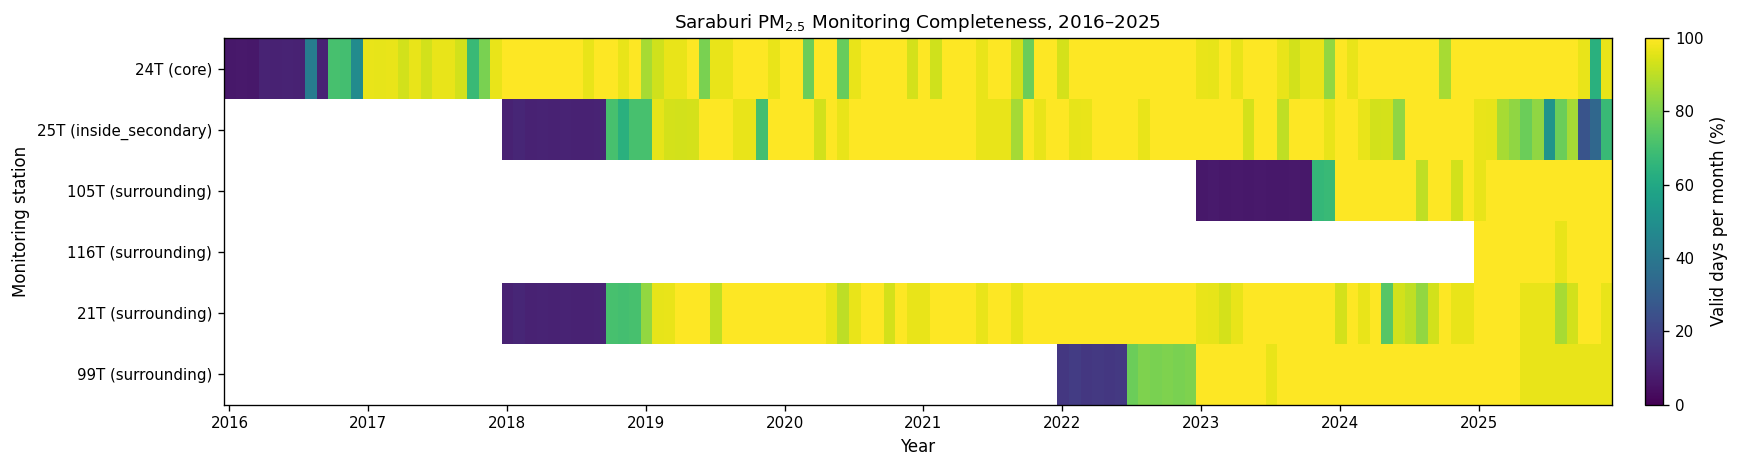

Saved: /content/pm25_saraburi_10yr_outputs/Fig01_station_month_completeness.png

DAILY EXPOSURE COVERAGE
PM25_core      : 3,137 / 3,653 days (85.9%)
PM25_inside    : 3,198 / 3,653 days (87.5%)
PM25_network   : 3,233 / 3,653 days (88.5%)

PRIMARY MONTHLY EXPOSURE QA
Passing months: 106 / 120
Missing/failed months: 14

ANNUAL PRIMARY-EXPOSURE STATISTICS
 year  n_valid_months  annual_mean_pm25  annual_median_monthly_pm25  sd_monthly_means  se_monthly_means  ci95_low  ci95_high
 2016               0               NaN                         NaN               NaN               NaN       NaN        NaN
 2017              11             35.75                       36.08              4.83              1.46     32.51      38.99
 2018              12             31.55                       29.52              7.90              2.28     26.53      36.57
 2019              12             35.09                       35.59             10.07              2.91     28.69      41.48
 2020              12

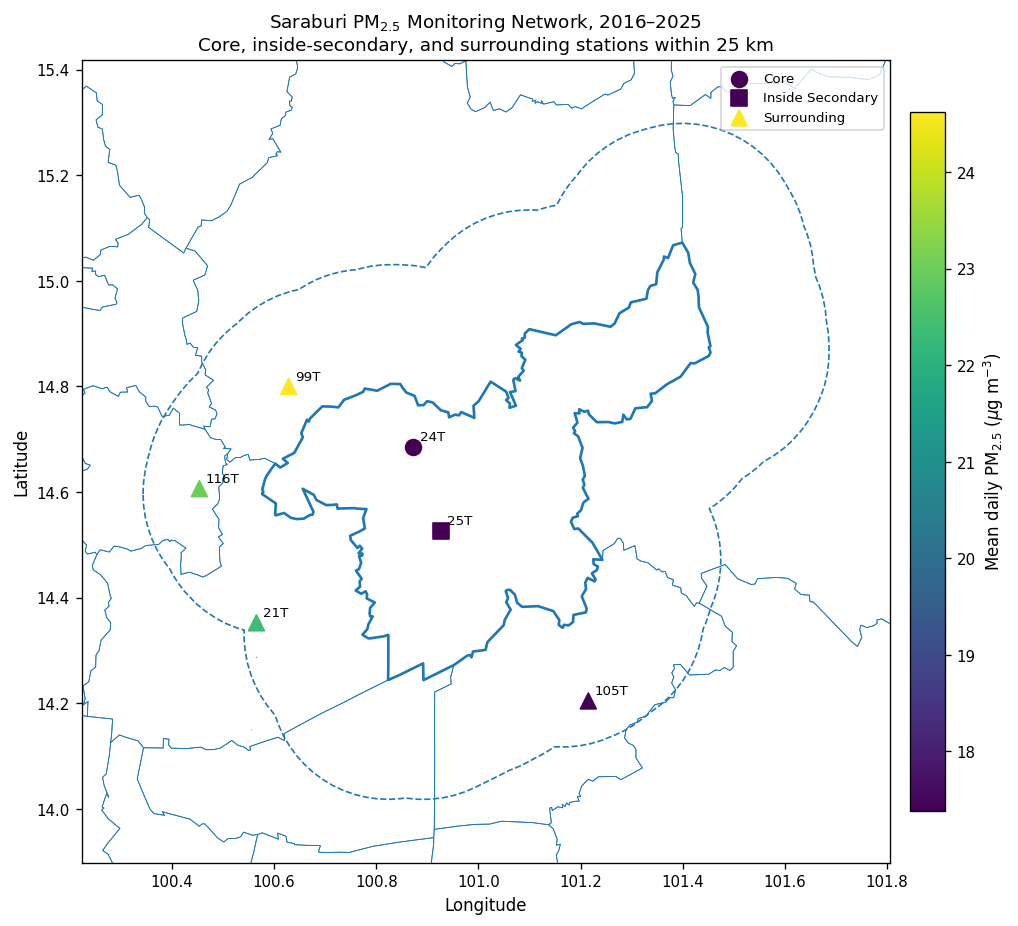

Saved: /content/pm25_saraburi_10yr_outputs/Fig02_saraburi_station_map.png


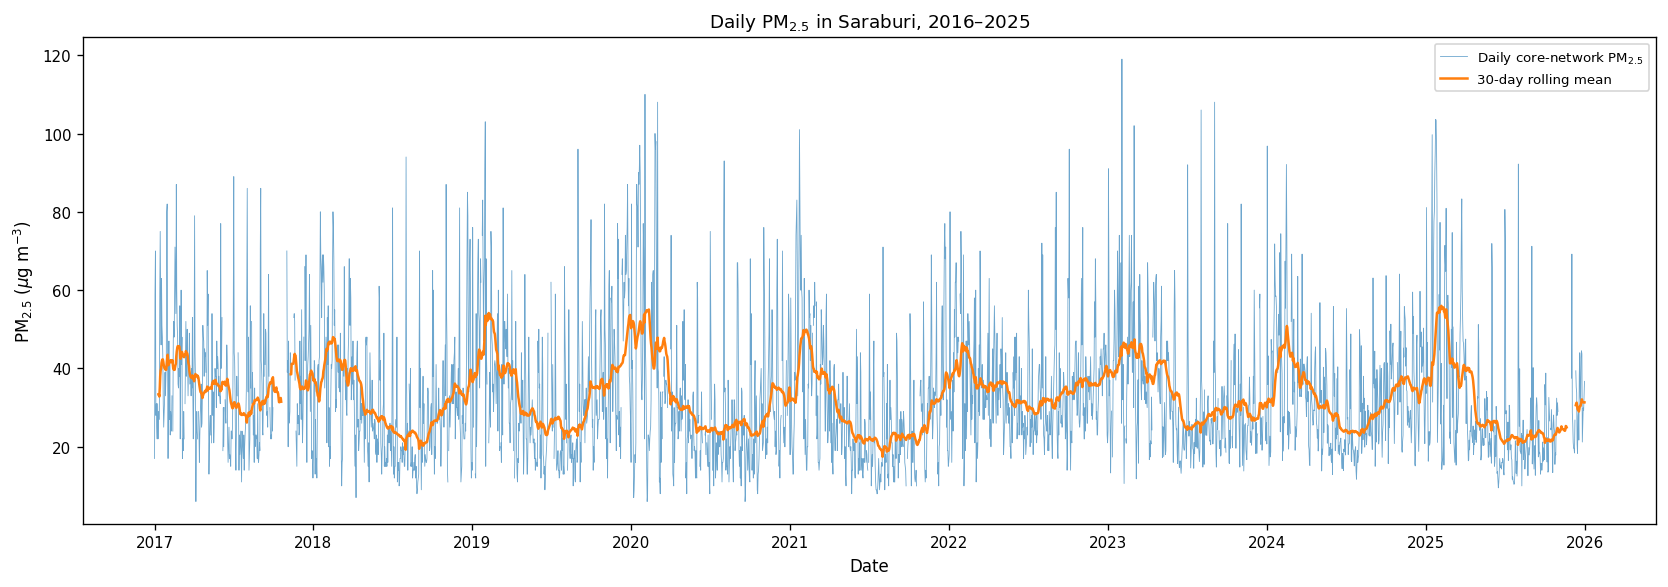

Saved: /content/pm25_saraburi_10yr_outputs/Fig03_daily_PM25_2016_2025.png


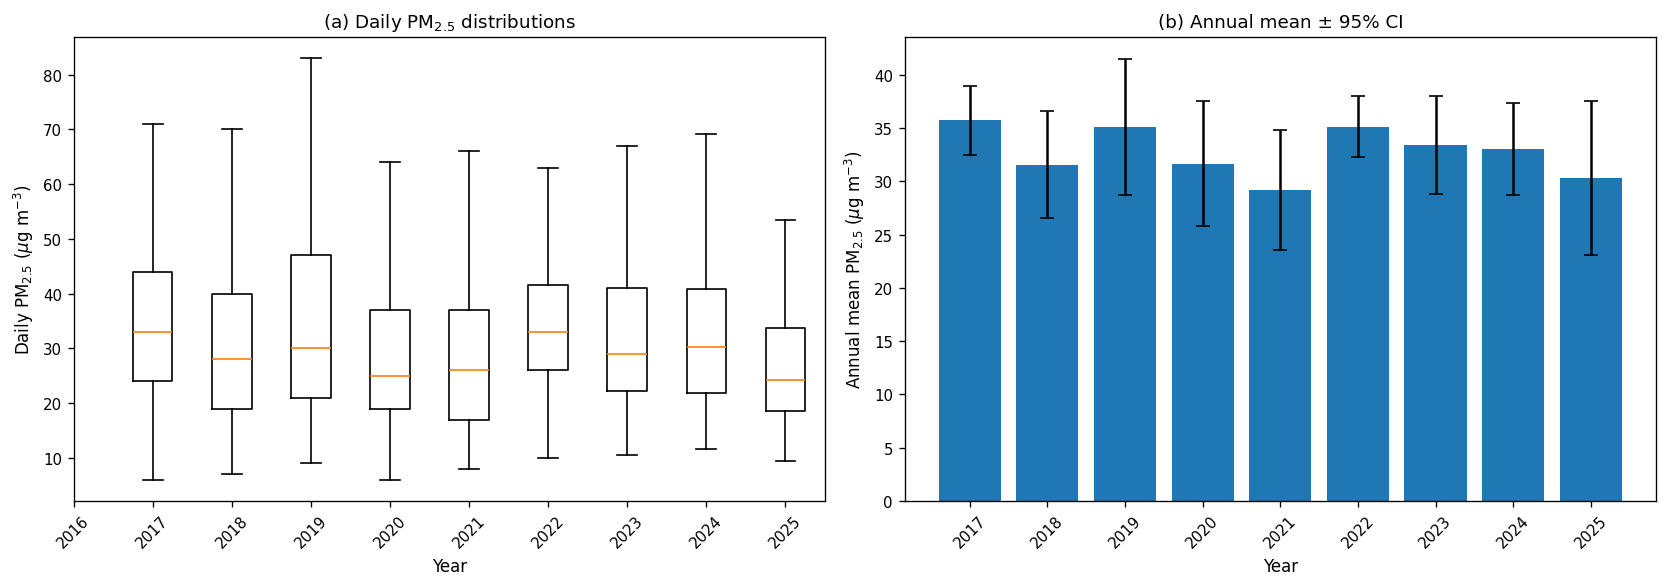

Saved: /content/pm25_saraburi_10yr_outputs/Fig04_interannual_variability.png


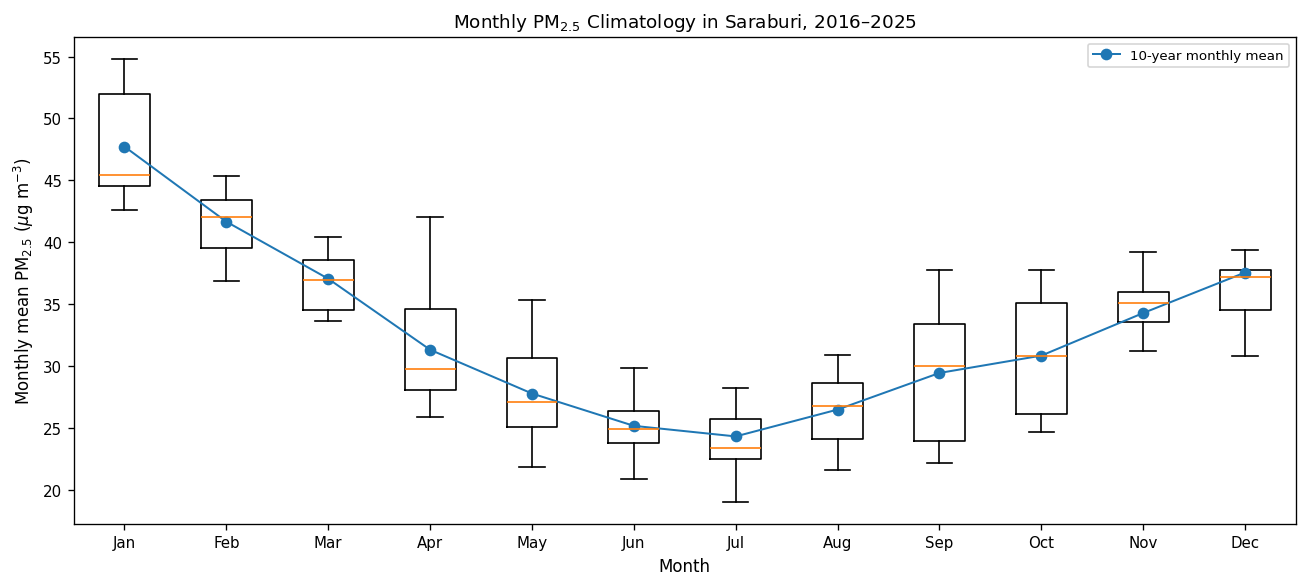

Saved: /content/pm25_saraburi_10yr_outputs/Fig05_monthly_climatology.png


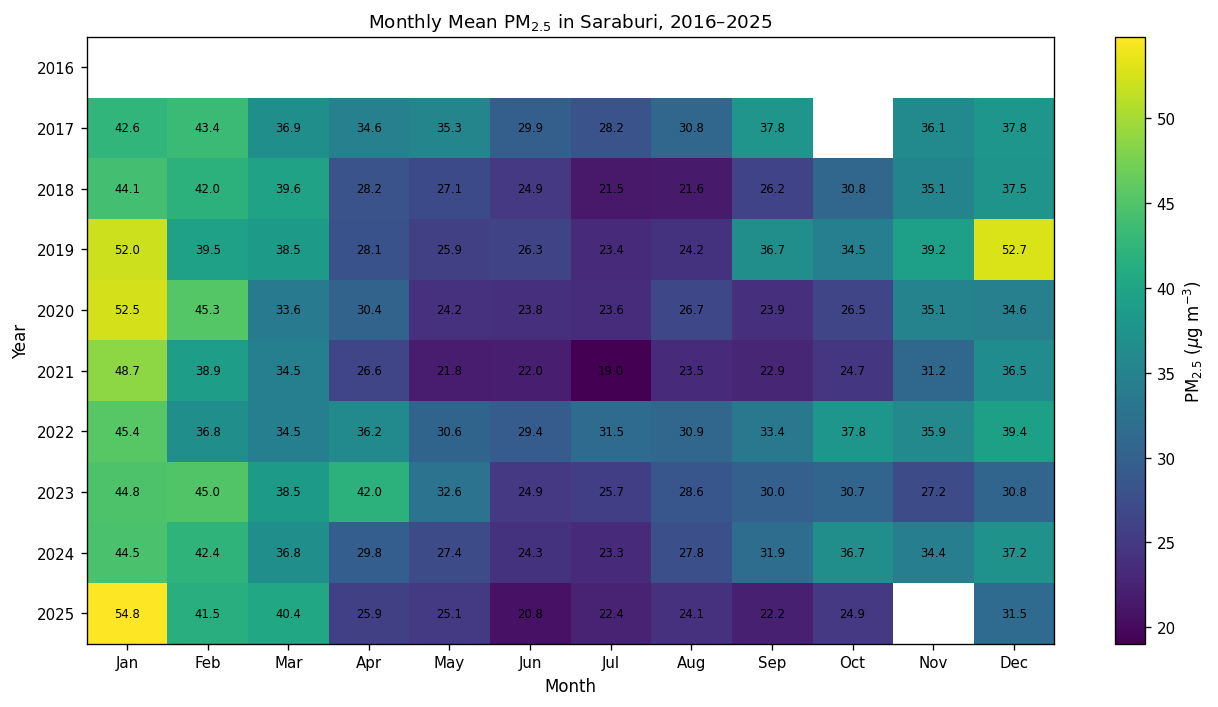

Saved: /content/pm25_saraburi_10yr_outputs/Fig06_year_month_heatmap.png


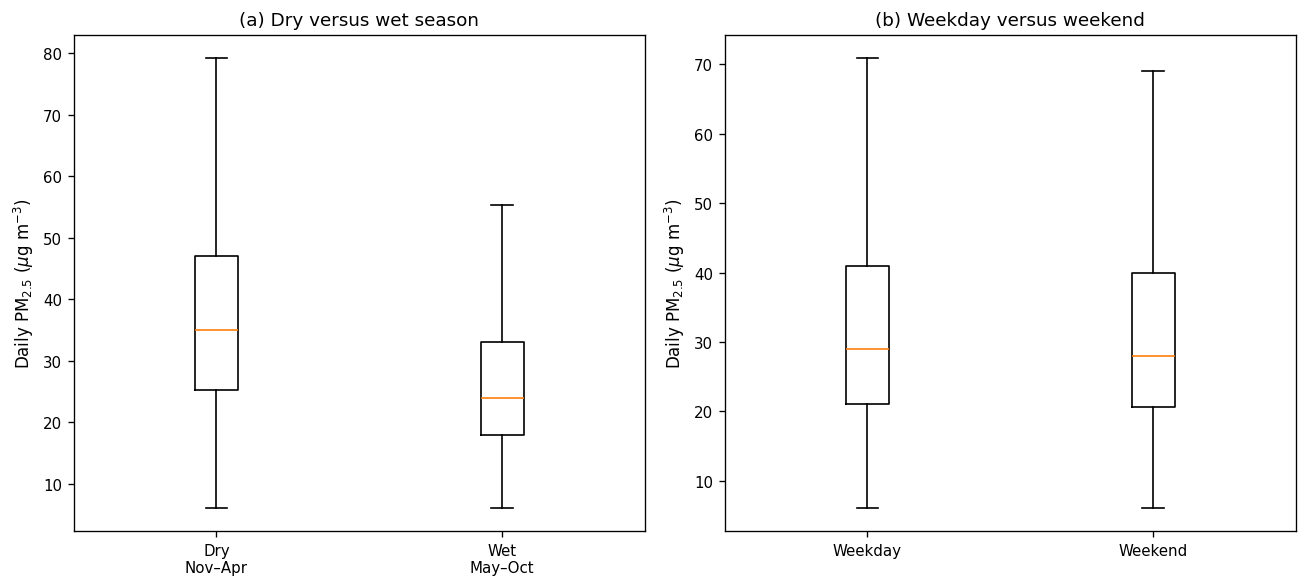

        comparison  group1   n1   mean1  median1  group2   n2   mean2  median2         U      p
        Dry vs Wet     Dry 1555 38.3517     35.0     Wet 1582 27.2519     24.0 1740085.0 0.0000
Weekday vs Weekend Weekday 2245 33.0200     29.0 Weekend  892 32.0846     28.0 1032881.5 0.1671

ANNUAL THEIL–SEN TREND
 n_years  sen_slope_ug_m3_per_year  sen_intercept  sen_slope_ci95_low  sen_slope_ci95_high  kendall_tau  kendall_p
       9                   -0.3824       805.9389             -1.5404               0.3403      -0.2778     0.3585

SEASONAL MANN–KENDALL + SEN
 n_monthly_observations  seasonal_S  seasonal_var_S  seasonal_Z  seasonal_tau  seasonal_MK_p  seasonal_sen_slope_ug_m3_per_year  seasonal_sen_ci95_low  seasonal_sen_ci95_high
                    106       -68.0       1050.6667      -2.067       -0.1635         0.0387                            -0.3278                 -0.579                 -0.0323

DESEASONALIZED MONTHLY ANOMALY TREND
Theil–Sen slope = -0.264 µg m⁻³ yr⁻¹
Naiv

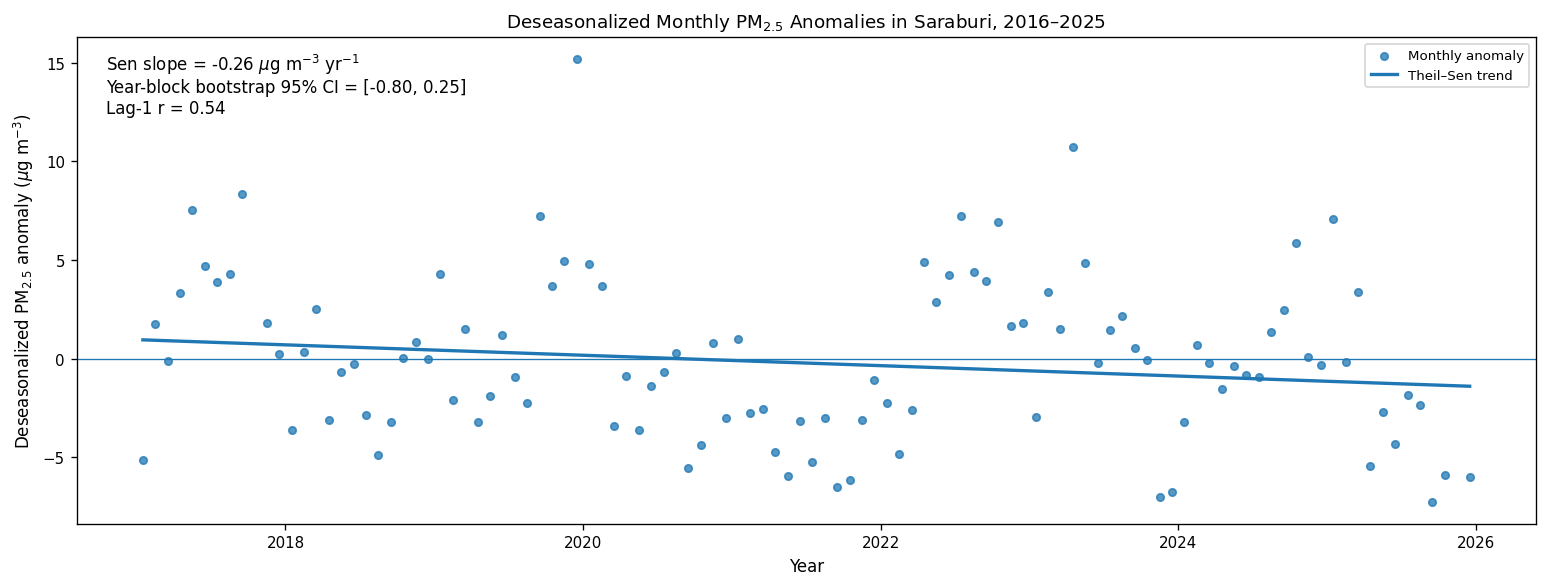

Saved: /content/pm25_saraburi_10yr_outputs/Fig08_deseasonalized_anomaly_trend.png

EXPLORATORY PETTITT CHANGE-POINT TEST
  n     K  change_index  p_approx change_date
106 761.0            36    0.1111  2020-02-01

Interpret as exploratory evidence only; a detected breakpoint should be evaluated against monitoring-network changes, meteorology, emissions, and the COVID-era period.

HIGH-PM2.5 EPISODE DEFINITION
Threshold = 55.40 µg m⁻³
Definition = 90th percentile of the complete 2016–2025 core daily series

ANNUAL EPISODE STATISTICS
 year  valid_days  annual_mean  annual_p95  annual_max  high_days  n_episodes  mean_episode_duration  longest_episode_days
 2016           0          NaN         NaN         NaN          0           0                   0.00                     0
 2017         315        35.70       65.30        89.0         32          22                   1.45                     3
 2018         363        31.51       66.90        94.0         35          17                

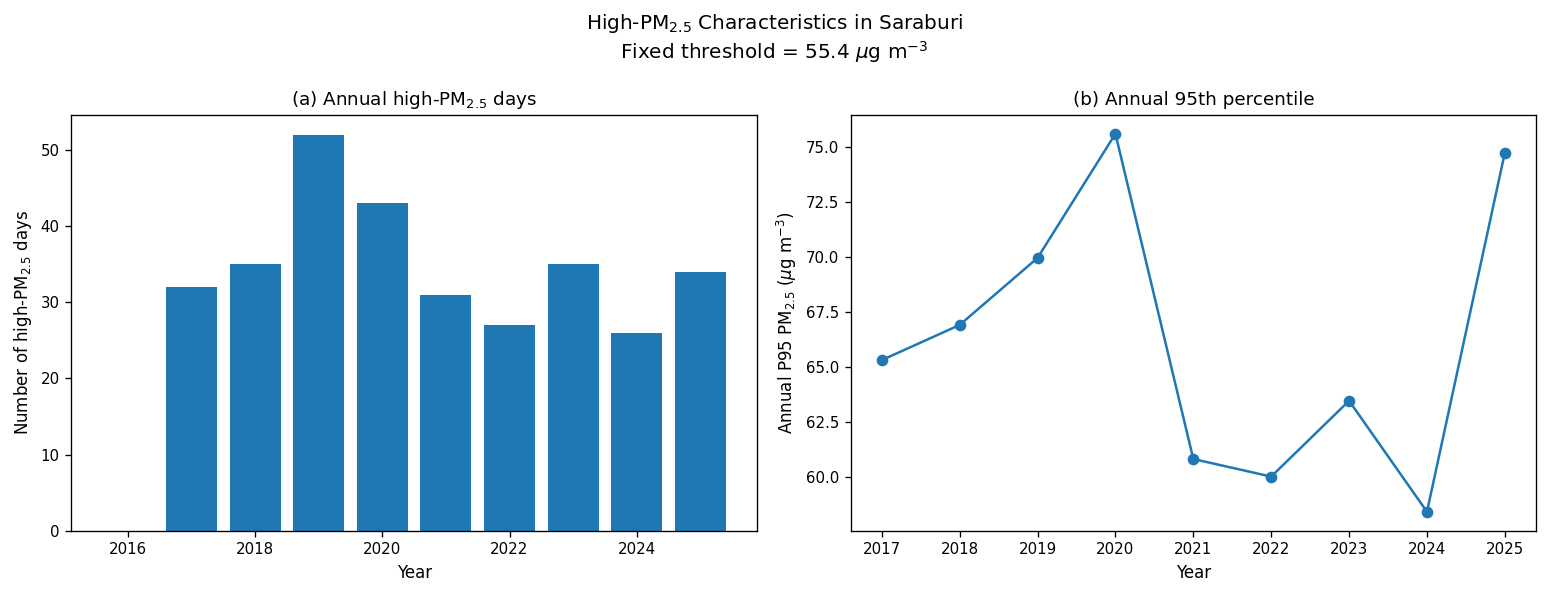

Saved: /content/pm25_saraburi_10yr_outputs/Fig09_high_PM25_characteristics.png

TREND SENSITIVITY
exposure_definition  n_monthly_observations  seasonal_tau  seasonal_MK_p  seasonal_sen_slope_ug_m3_per_year  seasonal_sen_ci95_low  seasonal_sen_ci95_high
               core                     106       -0.1635         0.0387                            -0.3278                -0.5793                 -0.0437
             inside                     106       -0.3173         0.0001                            -0.9140                -1.0902                 -0.6658
            network                     107       -0.4953         0.0000                            -1.3199                -1.5803                 -1.0538


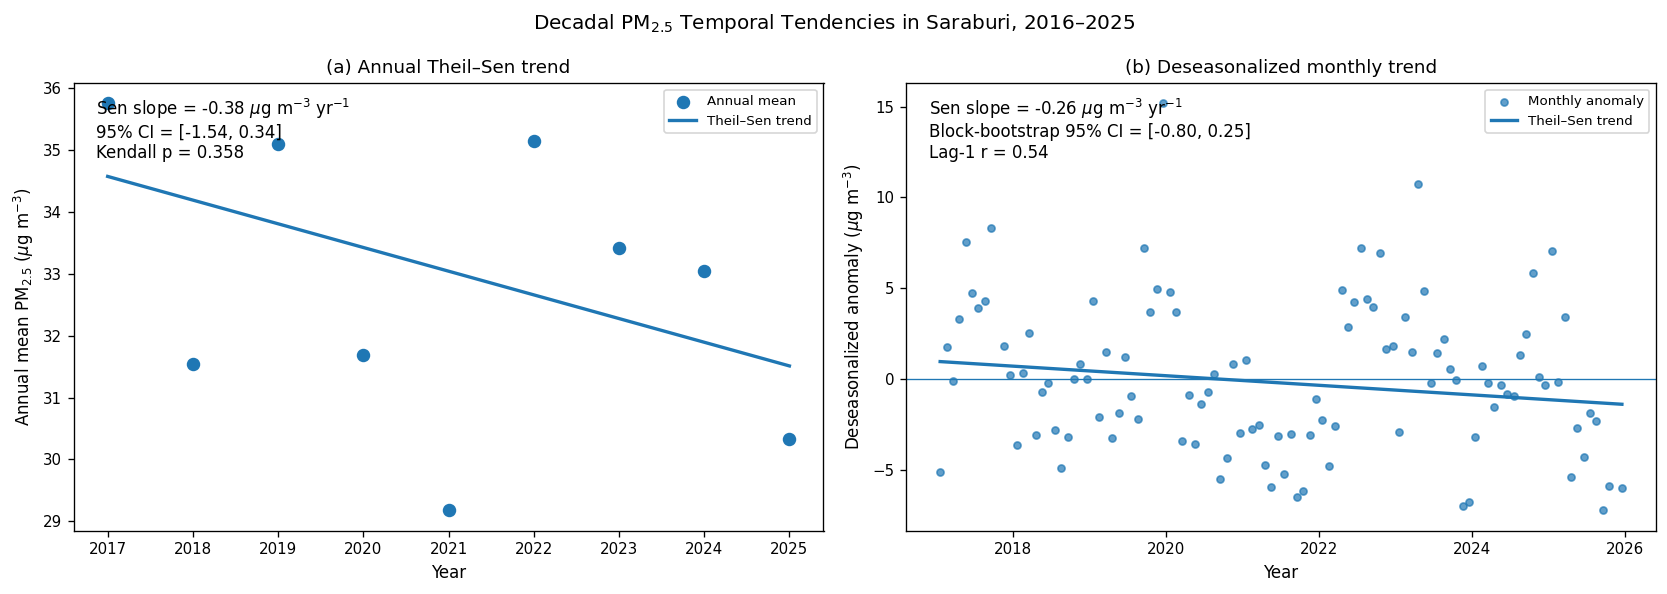

Saved: /content/pm25_saraburi_10yr_outputs/Fig10_decadal_trend_summary.png

SARABURI 10-YEAR PM2.5 ANALYSIS COMPLETE

Core monitoring stations:
24T

Primary exposure completeness:
3,137 / 3,653 days (85.9%)

Final trend table:
                                               analysis  slope_ug_m3_per_year  ci95_low  ci95_high  p_value
                                       Annual Theil-Sen               -0.3824   -1.5404     0.3403   0.3585
                   Seasonal Mann-Kendall + Seasonal Sen               -0.3278   -0.5790    -0.0323   0.0387
Deseasonalized monthly Theil-Sen + year-block bootstrap               -0.2638   -0.7990     0.2506      NaN

Sensitivity table:
exposure_definition  n_monthly_observations  seasonal_tau  seasonal_MK_p  seasonal_sen_slope_ug_m3_per_year  seasonal_sen_ci95_low  seasonal_sen_ci95_high
               core                     106       -0.1635         0.0387                            -0.3278                -0.5793                 -0.0437
           

In [ ]:


# =====================================================================
# CELL 3 — ROBUST DATE PARSER
# Handles:
#   - Excel serial dates
#   - Gregorian dates
#   - Buddhist Era dates
#   - Thai digits
# =====================================================================
THAI_DIGITS = str.maketrans(
    "๐๑๒๓๔๕๖๗๘๙",
    "0123456789"
)

def _convert_be_years_in_text(x):
    if x is None:
        return x

    s = str(x).strip().translate(THAI_DIGITS)

    if s.lower() in {"", "nan", "nat", "none"}:
        return None

    def repl(match):
        y = int(match.group(0))
        if 2400 <= y <= 2700:
            return str(y - 543)
        return str(y)

    return re.sub(r"\b\d{4}\b", repl, s)


def parse_pcd_dates(series):
    out = pd.Series(
        pd.NaT,
        index=series.index,
        dtype="datetime64[ns]"
    )

    # Excel serial dates
    numeric = pd.to_numeric(series, errors="coerce")
    serial_mask = numeric.between(20000, 60000)

    if serial_mask.any():
        out.loc[serial_mask] = pd.to_datetime(
            numeric.loc[serial_mask],
            unit="D",
            origin="1899-12-30",
            errors="coerce"
        )

    remaining = out.isna()

    if remaining.any():
        normalized = series.loc[remaining].map(
            _convert_be_years_in_text
        )

        parsed_dayfirst = pd.to_datetime(
            normalized,
            errors="coerce",
            dayfirst=True
        )

        parsed_monthfirst = pd.to_datetime(
            normalized,
            errors="coerce",
            dayfirst=False
        )

        out.loc[remaining] = parsed_dayfirst.fillna(
            parsed_monthfirst
        )

    return out


# =====================================================================
# CELL 4 — ROBUST HISTORICAL WORKBOOK READERS
#
# Historical PCD worksheet names can vary:
#   DATA / Data / PM2.5 / PM25
# Metadata can vary:
#   รายละเอียดจุดตรวจวัด / พารามิเตอร์_สถานี / etc.
# =====================================================================
DATA_SHEET_CANDIDATES = [
    "DATA",
    "Data",
    "data",
    "PM2.5",
    "pm2.5",
    "PM25",
    "pm25"
]

META_SHEET_CANDIDATES = [
    "รายละเอียดจุดตรวจวัด",
    "พารามิเตอร์_สถานี",
    "พารามิเตอร์สถานี",
    "station",
    "stations",
    "metadata"
]

def _sheet_norm(x):
    return (
        str(x)
        .strip()
        .lower()
        .replace(" ", "")
        .replace("_", "")
    )


def choose_data_sheet(sheet_names):
    norm_map = {
        _sheet_norm(s): s
        for s in sheet_names
    }

    for candidate in DATA_SHEET_CANDIDATES:
        key = _sheet_norm(candidate)
        if key in norm_map:
            return norm_map[key]

    for s in sheet_names:
        n = _sheet_norm(s)
        if "pm2.5" in n or "pm25" in n:
            return s

    raise ValueError(
        f"Could not identify PM2.5 data sheet. Sheets={sheet_names}"
    )


def choose_meta_sheet(sheet_names):
    norm_map = {
        _sheet_norm(s): s
        for s in sheet_names
    }

    for candidate in META_SHEET_CANDIDATES:
        key = _sheet_norm(candidate)
        if key in norm_map:
            return norm_map[key]

    for s in sheet_names:
        n = _sheet_norm(s)
        if (
            "รายละเอียดจุดตรวจวัด" in str(s)
            or "พารามิเตอร์" in str(s)
            or "station" in n
            or "metadata" in n
        ):
            return s

    return None


def _looks_like_station_code(value):
    if pd.isna(value):
        return False

    s = str(value).strip()

    patterns = [
        r"^\d{1,4}[A-Za-z]$",
        r"^[A-Za-z]{1,6}\d{1,6}$",
        r"^[A-Za-z]{1,6}\d{1,6}[A-Za-z]?$"
    ]

    return any(
        re.match(p, s)
        for p in patterns
    )


def detect_data_header_row(raw, max_rows=35):
    best_row = 0
    best_score = -1

    for i in range(min(max_rows, len(raw))):
        row = raw.iloc[i]

        strings = [
            str(v).strip()
            for v in row
            if pd.notna(v)
        ]

        joined = " ".join(strings).lower()

        date_keyword = (
            "date" in joined
            or "วันที่" in joined
            or "วัน/เดือน/ปี" in joined
            or "วันเดือนปี" in joined
        )

        station_like = sum(
            _looks_like_station_code(v)
            for v in row
        )

        nonempty = row.notna().sum()

        score = (
            (20 if date_keyword else 0)
            + 3 * station_like
            + 0.2 * min(nonempty, 25)
        )

        if score > best_score:
            best_score = score
            best_row = i

    return best_row


def detect_date_column(df):
    for c in df.columns:
        n = _sheet_norm(c)

        if (
            "date" in n
            or "วันที่" in str(c)
            or "วันเดือนปี" in str(c)
            or "วัน/เดือน/ปี" in str(c)
        ):
            return c

    return df.columns[0]


def read_pcd_daily(path):
    xls = pd.ExcelFile(path)

    data_sheet = choose_data_sheet(
        xls.sheet_names
    )

    raw = pd.read_excel(
        path,
        sheet_name=data_sheet,
        header=None
    )

    header_row = detect_data_header_row(raw)

    d = pd.read_excel(
        path,
        sheet_name=data_sheet,
        header=header_row
    )

    d = d.dropna(
        axis=1,
        how="all"
    )

    if d.shape[1] < 2:
        raise ValueError(
            f"{os.path.basename(path)} / {data_sheet}: "
            "fewer than two usable columns."
        )

    date_col = detect_date_column(d)

    d["_parsed_date"] = parse_pcd_dates(
        d[date_col]
    )

    d = d.dropna(
        subset=["_parsed_date"]
    ).copy()

    station_cols = []

    for c in d.columns:
        if c in [date_col, "_parsed_date"]:
            continue

        cs = str(c).strip()

        if _looks_like_station_code(cs):
            station_cols.append(c)
            continue

        if re.match(r"^\d{1,4}\.?0?$", cs):
            station_cols.append(c)

    if len(station_cols) < 2:
        station_cols = [
            c for c in d.columns
            if c not in [date_col, "_parsed_date"]
            and not str(c).lower().startswith("unnamed")
        ]

    if not station_cols:
        raise ValueError(
            f"{os.path.basename(path)} / {data_sheet}: "
            "no station columns detected."
        )

    long = d.melt(
        id_vars=["_parsed_date"],
        value_vars=station_cols,
        var_name="stationID",
        value_name="PM25"
    )

    long = long.rename(
        columns={"_parsed_date": "date"}
    )

    long["stationID"] = (
        long["stationID"]
        .astype(str)
        .str.strip()
        .str.lower()
        .str.replace(r"\.0$", "", regex=True)
    )

    long["PM25"] = pd.to_numeric(
        long["PM25"],
        errors="coerce"
    )

    # Negative values are invalid. Zero is retained.
    long.loc[
        long["PM25"] < 0,
        "PM25"
    ] = np.nan

    long = long.dropna(
        subset=["PM25"]
    ).copy()

    long["year"] = (
        long["date"].dt.year
    )

    long["source_file"] = os.path.basename(path)
    long["source_sheet"] = data_sheet

    return long


def _find_meta_header(raw, max_rows=35):
    for i in range(min(max_rows, len(raw))):
        joined = " | ".join(
            raw.iloc[i]
            .astype(str)
            .str.strip()
            .tolist()
        ).lower()

        if (
            "รหัสสถานี" in joined
            or "station id" in joined
            or "stationid" in joined
            or "station code" in joined
        ):
            return i

    return None


def _find_column_by_patterns(columns, patterns):
    for c in columns:
        txt = str(c).strip().lower()

        for pattern in patterns:
            if pattern in txt:
                return c

    return None


def read_station_meta(path):
    xls = pd.ExcelFile(path)

    meta_sheet = choose_meta_sheet(
        xls.sheet_names
    )

    empty = pd.DataFrame(
        columns=[
            "stationID",
            "siteTH",
            "siteEN",
            "meta_lat",
            "meta_long",
            "meta_area",
            "meta_source_file",
            "meta_source_sheet"
        ]
    )

    if meta_sheet is None:
        return empty

    raw = pd.read_excel(
        path,
        sheet_name=meta_sheet,
        header=None
    )

    header_row = _find_meta_header(raw)

    if header_row is None:
        return empty

    m = pd.read_excel(
        path,
        sheet_name=meta_sheet,
        header=header_row
    )

    code_col = _find_column_by_patterns(
        m.columns,
        [
            "รหัสสถานี",
            "station id",
            "stationid",
            "station code"
        ]
    )

    name_th_col = _find_column_by_patterns(
        m.columns,
        [
            "ชื่อสถานี",
            "station name th",
            "name th"
        ]
    )

    name_en_col = _find_column_by_patterns(
        m.columns,
        [
            "station name",
            "name en",
            "english"
        ]
    )

    lat_col = _find_column_by_patterns(
        m.columns,
        [
            "latitude",
            "ละติจูด",
            "lat"
        ]
    )

    lon_col = _find_column_by_patterns(
        m.columns,
        [
            "longitude",
            "ลองจิจูด",
            "long",
            "lon"
        ]
    )

    area_col = _find_column_by_patterns(
        m.columns,
        [
            "จังหวัด",
            "province",
            "area",
            "ที่ตั้ง"
        ]
    )

    if code_col is None:
        return empty

    out = pd.DataFrame()

    out["stationID"] = (
        m[code_col]
        .astype(str)
        .str.strip()
        .str.lower()
        .str.replace(r"\.0$", "", regex=True)
    )

    out["siteTH"] = (
        m[name_th_col].astype(str).str.strip()
        if name_th_col is not None
        else np.nan
    )

    out["siteEN"] = (
        m[name_en_col].astype(str).str.strip()
        if name_en_col is not None
        else np.nan
    )

    out["meta_lat"] = (
        pd.to_numeric(m[lat_col], errors="coerce")
        if lat_col is not None
        else np.nan
    )

    out["meta_long"] = (
        pd.to_numeric(m[lon_col], errors="coerce")
        if lon_col is not None
        else np.nan
    )

    out["meta_area"] = (
        m[area_col].astype(str).str.strip()
        if area_col is not None
        else np.nan
    )

    out = out[
        out["stationID"].str.match(
            r"^[a-z0-9]+$",
            na=False
        )
    ].copy()

    out["meta_source_file"] = os.path.basename(path)
    out["meta_source_sheet"] = meta_sheet

    return out.drop_duplicates(
        "stationID"
    )


# =====================================================================
# CELL 5 — READ ALL 10 WORKBOOKS + VERIFY 2016–2025
# =====================================================================
excel_files = sorted(
    glob.glob(
        os.path.join(DATA_DIR, "*.xlsx")
    )
    +
    glob.glob(
        os.path.join(DATA_DIR, "*.xls")
    )
)

excel_files = [
    f for f in excel_files
    if not os.path.basename(f).startswith("~$")
]

if not excel_files:
    raise RuntimeError(
        "No Excel files found in /content."
    )

parts = []
meta_parts = []
file_report = []

print("\nWORKBOOK INSPECTION")
print("=" * 100)

for path in excel_files:
    try:
        p = read_pcd_daily(path)
        m = read_station_meta(path)

        years_found = sorted(
            p["year"]
            .dropna()
            .unique()
            .tolist()
        )

        file_report.append({
            "file": os.path.basename(path),
            "data_sheet": (
                p["source_sheet"].iloc[0]
                if len(p) else None
            ),
            "years_found": ",".join(
                map(str, years_found)
            ),
            "n_station_days": len(p),
            "n_stations": p["stationID"].nunique()
        })

        parts.append(p)
        meta_parts.append(m)

        print(f"\n{os.path.basename(path)}")
        print(
            "  data sheet:",
            p["source_sheet"].iloc[0]
            if len(p) else "unknown"
        )
        print("  years     :", years_found)
        print("  stations  :", p["stationID"].nunique())
        print("  rows      :", f"{len(p):,}")

    except Exception as e:
        print(f"\nFAILED: {os.path.basename(path)}")
        print(" ", repr(e))

if not parts:
    raise RuntimeError(
        "None of the uploaded workbooks could be read."
    )

file_report_df = pd.DataFrame(file_report)

file_report_df.to_csv(
    os.path.join(
        OUT_DIR,
        "01_uploaded_file_report.csv"
    ),
    index=False
)

daily_raw = pd.concat(
    parts,
    ignore_index=True
)

daily_raw = daily_raw[
    daily_raw["year"].isin(
        STUDY_YEARS
    )
].copy()

daily_raw = (
    daily_raw
    .sort_values(
        ["stationID", "date"]
    )
    .drop_duplicates(
        ["stationID", "date"],
        keep="first"
    )
    .reset_index(drop=True)
)

# Combine metadata across years using first non-missing value per station.
if meta_parts:
    meta_all = pd.concat(
        meta_parts,
        ignore_index=True
    )

    def first_nonnull(series):
        s = series.dropna()

        if len(s) == 0:
            return np.nan

        # Avoid string "nan"
        for value in s:
            if str(value).strip().lower() not in {
                "",
                "nan",
                "none"
            }:
                return value

        return np.nan

    metadata_rows = []

    for station_id, g in meta_all.groupby(
        "stationID",
        sort=True
    ):
        metadata_rows.append({
            "stationID": station_id,
            "siteTH": first_nonnull(g["siteTH"]),
            "siteEN": first_nonnull(g["siteEN"]),
            "meta_lat": first_nonnull(g["meta_lat"]),
            "meta_long": first_nonnull(g["meta_long"]),
            "meta_area": first_nonnull(g["meta_area"])
        })

    station_meta_archive = pd.DataFrame(
        metadata_rows
    )

else:
    station_meta_archive = pd.DataFrame(
        columns=[
            "stationID",
            "siteTH",
            "siteEN",
            "meta_lat",
            "meta_long",
            "meta_area"
        ]
    )

years_present = sorted(
    daily_raw["year"]
    .unique()
    .tolist()
)

missing_years = sorted(
    set(STUDY_YEARS)
    - set(years_present)
)

print("\nCOMBINED 10-YEAR ARCHIVE")
print("=" * 100)
print(
    "Date span :",
    daily_raw["date"].min(),
    "to",
    daily_raw["date"].max()
)
print("Years     :", years_present)
print("Stations  :", daily_raw["stationID"].nunique())
print("Rows      :", f"{len(daily_raw):,}")

if missing_years:
    print("\n*** MISSING YEARS ***")
    print(missing_years)

    if STRICT_YEAR_CHECK:
        raise RuntimeError(
            f"Missing study years: {missing_years}. "
            "Upload the correct daily PM2.5 workbooks and rerun."
        )

print("\n✅ All 10 requested years are present.")


# =====================================================================
# CELL 6 — SARABURI PROVINCE BOUNDARY
# =====================================================================
PROV_URL = (
    "https://raw.githubusercontent.com/"
    "chingchai/OpenGISData-Thailand/"
    "master/provinces.geojson"
)

PROV_FILE = os.path.join(
    DATA_DIR,
    "th_provinces.geojson"
)

if not os.path.exists(PROV_FILE):
    response = requests.get(
        PROV_URL,
        timeout=120
    )

    response.raise_for_status()

    with open(PROV_FILE, "wb") as f:
        f.write(response.content)

prov = gpd.read_file(PROV_FILE)

if prov.crs is None:
    prov = prov.set_crs(
        epsg=4326
    )

prov = prov.to_crs(
    epsg=4326
)

possible_name_fields = [
    "pro_en",
    "NAME_1",
    "name_en",
    "province_en"
]

name_field = None

for candidate in possible_name_fields:
    if candidate in prov.columns:
        name_field = candidate
        break

if name_field is None:
    raise ValueError(
        "Could not identify English province-name field. "
        f"Columns={list(prov.columns)}"
    )

prov = prov.rename(
    columns={
        name_field: "boundary_name"
    }
)

prov["boundary_norm"] = (
    prov["boundary_name"]
    .map(_norm)
)

saraburi = prov[
    prov["boundary_norm"].isin(
        {
            "saraburi",
            "saraburiprovince"
        }
    )
].copy()

if len(saraburi) != 1:
    raise ValueError(
        "Could not uniquely match Saraburi boundary. "
        f"Matches={saraburi['boundary_name'].tolist()}"
    )

saraburi["province"] = TARGET_PROVINCE

saraburi_union = (
    saraburi.geometry
    .union_all()
)

saraburi_gdf = gpd.GeoDataFrame(
    {"province": [TARGET_PROVINCE]},
    geometry=[saraburi_union],
    crs="EPSG:4326"
)

saraburi_m = saraburi_gdf.to_crs(
    METRIC_CRS
)

buffer_geom_m = (
    saraburi_m
    .geometry
    .iloc[0]
    .buffer(
        BUFFER_KM * 1000
    )
)

buffer_gdf_m = gpd.GeoDataFrame(
    {"buffer_km": [BUFFER_KM]},
    geometry=[buffer_geom_m],
    crs=METRIC_CRS
)

buffer_gdf = buffer_gdf_m.to_crs(
    epsg=4326
)

buffer_geom = (
    buffer_gdf
    .geometry
    .iloc[0]
)

print("✅ Saraburi boundary and buffer prepared.")


# =====================================================================
# CELL 7 — STATION COORDINATES
# Prefer coordinates contained in historical workbooks.
# Use current Air4Thai API only as a fallback.
# =====================================================================
live_station_df = pd.DataFrame(
    columns=[
        "stationID",
        "nameEN",
        "nameTH",
        "areaEN",
        "areaTH",
        "api_lat",
        "api_long"
    ]
)

A4T_URLS = [
    "https://air4thai.pcd.go.th/services/getNewAQI_JSON.php",
    "http://air4thai.pcd.go.th/services/getNewAQI_JSON.php"
]

last_error = None

for url in A4T_URLS:
    try:
        r = requests.get(
            url,
            timeout=60,
            verify=False,
            headers={
                "User-Agent": "Mozilla/5.0"
            }
        )

        r.raise_for_status()

        js = r.json()

        rows = []

        for item in js.get(
            "stations",
            []
        ):
            try:
                lat = float(
                    item.get(
                        "lat",
                        np.nan
                    )
                )

                lon = float(
                    item.get(
                        "long",
                        np.nan
                    )
                )

            except Exception:
                lat = np.nan
                lon = np.nan

            rows.append({
                "stationID": str(
                    item.get(
                        "stationID",
                        ""
                    )
                ).strip().lower(),
                "nameEN": item.get("nameEN"),
                "nameTH": item.get("nameTH"),
                "areaEN": item.get("areaEN"),
                "areaTH": item.get("areaTH"),
                "api_lat": lat,
                "api_long": lon
            })

        live_station_df = (
            pd.DataFrame(rows)
            .drop_duplicates(
                "stationID"
            )
        )

        print(
            "Current Air4Thai station API loaded:",
            url
        )

        break

    except Exception as e:
        last_error = e

if live_station_df.empty:
    print(
        "WARNING: current Air4Thai station API unavailable."
    )
    print(
        "Historical workbook coordinates will be used where available."
    )
    print(
        "Last API error:",
        last_error
    )

station_info = station_meta_archive.merge(
    live_station_df,
    on="stationID",
    how="outer"
)

station_info["lat"] = (
    station_info["meta_lat"]
    .where(
        station_info["meta_lat"].notna(),
        station_info["api_lat"]
    )
)

station_info["long"] = (
    station_info["meta_long"]
    .where(
        station_info["meta_long"].notna(),
        station_info["api_long"]
    )
)

archive_ids = set(
    daily_raw["stationID"]
    .unique()
)

station_info = station_info[
    station_info["stationID"].isin(
        archive_ids
    )
].copy()

missing_coord = station_info[
    station_info["lat"].isna()
    |
    station_info["long"].isna()
].copy()

if len(missing_coord) > 0:
    print("\nHistorical archive stations lacking coordinates:")
    print(
        missing_coord[
            [
                "stationID",
                "siteTH",
                "siteEN",
                "meta_area"
            ]
        ].to_string(index=False)
    )

station_info_geo = station_info[
    station_info["lat"].notna()
    &
    station_info["long"].notna()
].copy()

stations = gpd.GeoDataFrame(
    station_info_geo,
    geometry=[
        Point(lon, lat)
        for lon, lat in zip(
            station_info_geo["long"],
            station_info_geo["lat"]
        )
    ],
    crs="EPSG:4326"
)

print(
    "\nArchive stations with coordinates:",
    len(stations)
)


# =====================================================================
# CELL 8 — CLASSIFY INSIDE SARABURI vs SURROUNDING ≤25 km
# =====================================================================
stations["inside_saraburi"] = (
    stations.geometry
    .within(
        saraburi_union
    )
)

stations["within_buffer"] = (
    stations.geometry
    .within(
        buffer_geom
    )
)

stations["tier"] = np.select(
    [
        stations["inside_saraburi"],
        (
            ~stations["inside_saraburi"]
            &
            stations["within_buffer"]
        )
    ],
    [
        "inside",
        "surrounding"
    ],
    default="outside"
)

selected = stations[
    stations["tier"].isin(
        [
            "inside",
            "surrounding"
        ]
    )
].copy()

# Distance to Saraburi boundary for surrounding stations.
selected_m = selected.to_crs(
    METRIC_CRS
)

saraburi_geom_m = (
    saraburi_m.geometry.iloc[0]
)

distances = []

for _, row in selected_m.iterrows():
    if row["tier"] == "inside":
        distances.append(0.0)
    else:
        distances.append(
            float(
                row.geometry.distance(
                    saraburi_geom_m
                )
            )
            / 1000.0
        )

selected["distance_to_saraburi_km"] = distances

selected = selected.sort_values(
    [
        "tier",
        "distance_to_saraburi_km",
        "stationID"
    ]
).reset_index(drop=True)

print("\nSARABURI + SURROUNDING MONITORING STATIONS")
print("=" * 110)

show_cols = [
    "stationID",
    "siteTH",
    "siteEN",
    "nameEN",
    "tier",
    "distance_to_saraburi_km",
    "lat",
    "long"
]

show_cols = [
    c for c in show_cols
    if c in selected.columns
]

print(
    selected[
        show_cols
    ]
    .round(
        {
            "distance_to_saraburi_km": 1,
            "lat": 4,
            "long": 4
        }
    )
    .to_string(index=False)
)

selected.drop(
    columns="geometry"
).to_csv(
    os.path.join(
        OUT_DIR,
        "02_selected_saraburi_stations.csv"
    ),
    index=False
)


# =====================================================================
# CELL 9 — BUILD STATION-LEVEL DAILY TABLE
# =====================================================================
daily = daily_raw[
    daily_raw["stationID"].isin(
        selected["stationID"]
    )
].copy()

station_attrs = selected[
    [
        "stationID",
        "tier",
        "distance_to_saraburi_km",
        "lat",
        "long"
    ]
].copy()

for extra_col in [
    "siteTH",
    "siteEN",
    "nameEN",
    "nameTH"
]:
    if extra_col in selected.columns:
        station_attrs[extra_col] = (
            selected[extra_col]
        )

daily = daily.merge(
    station_attrs,
    on="stationID",
    how="left",
    validate="many_to_one"
)

daily["year"] = daily["date"].dt.year
daily["month"] = daily["date"].dt.month
daily["month_name"] = daily["date"].dt.strftime("%b")
daily["dow"] = daily["date"].dt.dayofweek
daily["day_name"] = daily["date"].dt.day_name()
daily["weekend"] = daily["dow"] >= 5

daily["day_type"] = np.where(
    daily["weekend"],
    "Weekend",
    "Weekday"
)

daily["season"] = np.select(
    [
        daily["month"].isin(
            WET_MONTHS
        ),
        daily["month"].isin(
            DRY_MONTHS
        )
    ],
    [
        "Wet",
        "Dry"
    ],
    default="Other"
)

print(
    "Selected station-days before QA:",
    f"{len(daily):,}"
)


# =====================================================================
# CELL 10 — STATION-MONTH COMPLETENESS QA
# =====================================================================
daily["year_month"] = (
    daily["date"]
    .dt.to_period("M")
)

month_count = (
    daily
    .groupby(
        [
            "stationID",
            "year_month"
        ],
        as_index=False
    )["date"]
    .nunique()
    .rename(
        columns={
            "date": "valid_days"
        }
    )
)

month_count["days_in_month"] = (
    month_count["year_month"]
    .dt.days_in_month
)

month_count["completeness"] = (
    month_count["valid_days"]
    /
    month_count["days_in_month"]
)

month_count["month_pass"] = (
    month_count["completeness"]
    >=
    MIN_DAYS_FRAC_MONTH
)

month_count["year"] = (
    month_count["year_month"]
    .dt.year
)

month_count["month"] = (
    month_count["year_month"]
    .dt.month
)

month_count.to_csv(
    os.path.join(
        OUT_DIR,
        "03_station_month_completeness.csv"
    ),
    index=False
)

daily = daily.merge(
    month_count[
        [
            "stationID",
            "year_month",
            "valid_days",
            "days_in_month",
            "completeness",
            "month_pass"
        ]
    ],
    on=[
        "stationID",
        "year_month"
    ],
    how="left",
    validate="many_to_one"
)

daily_qc = daily[
    daily["month_pass"]
    .fillna(False)
].copy()

print("\nSTATION-MONTH QA")
print("=" * 90)
print(
    "PASS months:",
    int(
        month_count[
            "month_pass"
        ].sum()
    )
)
print(
    "FAIL months:",
    int(
        (
            ~month_count[
                "month_pass"
            ]
        ).sum()
    )
)
print(
    "Retained station-days:",
    f"{len(daily_qc):,}",
    f"({100*len(daily_qc)/len(daily):.1f}%)"
)


# =====================================================================
# CELL 11 — LONG-TERM STATION HISTORY + CORE NETWORK SELECTION
#
# Core criterion:
#   1) physically inside Saraburi
#   2) >= 9 valid months in a year
#   3) >= 8 adequate years across 2016–2025
# =====================================================================
# Number of passing months per station-year.
station_year_months = (
    month_count[
        month_count["month_pass"]
    ]
    .groupby(
        [
            "stationID",
            "year"
        ],
        as_index=False
    )["month"]
    .nunique()
    .rename(
        columns={
            "month": "valid_months"
        }
    )
)

# Create complete station × year grid.
history_rows = []

for station_id in selected["stationID"]:
    tier = (
        selected.loc[
            selected["stationID"] == station_id,
            "tier"
        ].iloc[0]
    )

    for year in STUDY_YEARS:
        tmp = station_year_months[
            (
                station_year_months[
                    "stationID"
                ] == station_id
            )
            &
            (
                station_year_months[
                    "year"
                ] == year
            )
        ]

        valid_months = (
            int(
                tmp["valid_months"].iloc[0]
            )
            if len(tmp) > 0
            else 0
        )

        history_rows.append({
            "stationID": station_id,
            "tier": tier,
            "year": year,
            "valid_months": valid_months,
            "adequate_year": (
                valid_months
                >=
                MIN_VALID_MONTHS_PER_YEAR
            )
        })

station_history = pd.DataFrame(
    history_rows
)

station_longterm_rows = []

for keys, g in station_history.groupby(
    [
        "stationID",
        "tier"
    ],
    sort=True
):
    station_id, tier = keys

    adequate_years = int(
        g["adequate_year"].sum()
    )

    valid_months_total = int(
        g["valid_months"].sum()
    )

    station_longterm_rows.append({
        "stationID": station_id,
        "tier": tier,
        "adequate_years": adequate_years,
        "valid_months_total": valid_months_total,
        "valid_month_fraction": (
            valid_months_total
            /
            (12 * len(STUDY_YEARS))
        )
    })

station_longterm = pd.DataFrame(
    station_longterm_rows
)

# Core = inside Saraburi + long-term completeness.
station_longterm["core_eligible"] = (
    (
        station_longterm["tier"]
        == "inside"
    )
    &
    (
        station_longterm[
            "adequate_years"
        ]
        >=
        MIN_CORE_VALID_YEARS
    )
)

core_station_ids = (
    station_longterm.loc[
        station_longterm[
            "core_eligible"
        ],
        "stationID"
    ]
    .tolist()
)

core_fallback_used = False

# If no station satisfies the strict criterion, automatically choose the
# best-covered INSIDE station and clearly flag that this is a fallback.
if len(core_station_ids) == 0:
    inside_rank = (
        station_longterm[
            station_longterm[
                "tier"
            ] == "inside"
        ]
        .sort_values(
            [
                "adequate_years",
                "valid_months_total"
            ],
            ascending=False
        )
    )

    if len(inside_rank) == 0:
        raise RuntimeError(
            "No inside-Saraburi monitoring station was identified. "
            "Review station coordinates/metadata before continuing."
        )

    core_station_ids = [
        inside_rank[
            "stationID"
        ].iloc[0]
    ]

    core_fallback_used = True

station_longterm["network_role"] = np.select(
    [
        station_longterm["stationID"].isin(
            core_station_ids
        ),
        station_longterm["tier"] == "inside"
    ],
    [
        "core",
        "inside_secondary"
    ],
    default="surrounding"
)

station_longterm = station_longterm.merge(
    selected[
        [
            "stationID",
            "distance_to_saraburi_km"
        ]
    ],
    on="stationID",
    how="left",
    validate="one_to_one"
)

station_longterm.to_csv(
    os.path.join(
        OUT_DIR,
        "04_station_longterm_eligibility.csv"
    ),
    index=False
)

station_history.to_csv(
    os.path.join(
        OUT_DIR,
        "05_station_year_valid_months.csv"
    ),
    index=False
)

print("\nLONG-TERM STATION AUDIT")
print("=" * 110)
print(
    station_longterm
    .round(
        {
            "valid_month_fraction": 3,
            "distance_to_saraburi_km": 1
        }
    )
    .to_string(index=False)
)

print("\nCORE STATION IDS:", core_station_ids)

if core_fallback_used:
    print(
        "WARNING: no inside station met the strict core criterion. "
        "The best-covered inside station was selected as a flagged fallback."
    )
else:
    print(
        "✅ Fixed core network selected using the prespecified completeness rule."
    )


# =====================================================================
# CELL 12 — FIGURE 1: STATION-MONTH COMPLETENESS HEATMAP
#
# 120 columns = Jan 2016 ... Dec 2025
# Values = station-month completeness (%)
# =====================================================================
station_order = (
    station_longterm
    .sort_values(
        [
            "network_role",
            "stationID"
        ]
    )[
        "stationID"
    ]
    .tolist()
)

month_periods = pd.period_range(
    start="2016-01",
    end="2025-12",
    freq="M"
)

matrix = np.full(
    (
        len(station_order),
        len(month_periods)
    ),
    np.nan
)

for i, station_id in enumerate(
    station_order
):
    for j, period in enumerate(
        month_periods
    ):
        tmp = month_count[
            (
                month_count[
                    "stationID"
                ] == station_id
            )
            &
            (
                month_count[
                    "year_month"
                ] == period
            )
        ]

        if len(tmp) > 0:
            matrix[i, j] = (
                100
                *
                float(
                    tmp[
                        "completeness"
                    ].iloc[0]
                )
            )

fig, ax = plt.subplots(
    figsize=(16, max(4, 0.55 * len(station_order)))
)

im = ax.imshow(
    matrix,
    aspect="auto",
    vmin=0,
    vmax=100,
    interpolation="nearest"
)

# Year labels at January positions.
year_positions = [
    12 * i
    for i in range(
        len(STUDY_YEARS)
    )
]

ax.set_xticks(
    year_positions
)

ax.set_xticklabels(
    STUDY_YEARS
)

ax.set_yticks(
    np.arange(
        len(station_order)
    )
)

role_lookup = (
    station_longterm
    .set_index(
        "stationID"
    )[
        "network_role"
    ]
    .to_dict()
)

ax.set_yticklabels(
    [
        f"{s.upper()} ({role_lookup.get(s, '')})"
        for s in station_order
    ]
)

ax.set_xlabel("Year")
ax.set_ylabel("Monitoring station")
ax.set_title(
    "Saraburi PM$_{2.5}$ Monitoring Completeness, 2016–2025"
)

cbar = fig.colorbar(
    im,
    ax=ax,
    pad=0.02
)

cbar.set_label(
    "Valid days per month (%)"
)

plt.tight_layout()

fig_path = os.path.join(
    OUT_DIR,
    "Fig01_station_month_completeness.png"
)

plt.savefig(
    fig_path,
    dpi=FIG_DPI,
    bbox_inches="tight"
)

plt.show()

print("Saved:", fig_path)


# =====================================================================
# CELL 13 — BUILD THREE DAILY EXPOSURE SERIES
#
# 1) PM25_core    = fixed long-term core monitors (PRIMARY)
# 2) PM25_inside  = all inside Saraburi monitors
# 3) PM25_network = inside + surrounding ≤25 km
#
# IMPORTANT:
# PM25_core is NOT filled with surrounding data when missing.
# =====================================================================
core_daily = (
    daily_qc[
        daily_qc["stationID"].isin(
            core_station_ids
        )
    ]
    .groupby(
        "date",
        as_index=False
    )
    .agg(
        PM25_core=(
            "PM25",
            "mean"
        ),
        n_core_stations=(
            "stationID",
            "nunique"
        )
    )
)

inside_daily = (
    daily_qc[
        daily_qc[
            "tier"
        ] == "inside"
    ]
    .groupby(
        "date",
        as_index=False
    )
    .agg(
        PM25_inside=(
            "PM25",
            "mean"
        ),
        n_inside_stations=(
            "stationID",
            "nunique"
        )
    )
)

network_daily = (
    daily_qc
    .groupby(
        "date",
        as_index=False
    )
    .agg(
        PM25_network=(
            "PM25",
            "mean"
        ),
        n_network_stations=(
            "stationID",
            "nunique"
        )
    )
)

# Full calendar to expose genuine missing days.
calendar_df = pd.DataFrame({
    "date": pd.date_range(
        f"{STUDY_YEARS[0]}-01-01",
        f"{STUDY_YEARS[-1]}-12-31",
        freq="D"
    )
})

exposure_daily = (
    calendar_df
    .merge(
        core_daily,
        on="date",
        how="left"
    )
    .merge(
        inside_daily,
        on="date",
        how="left"
    )
    .merge(
        network_daily,
        on="date",
        how="left"
    )
)

# Primary is explicitly the fixed core series.
exposure_daily["PM25_primary"] = (
    exposure_daily[
        "PM25_core"
    ]
)

exposure_daily["year"] = (
    exposure_daily["date"]
    .dt.year
)

exposure_daily["month"] = (
    exposure_daily["date"]
    .dt.month
)

exposure_daily["month_name"] = (
    exposure_daily["date"]
    .dt.strftime("%b")
)

exposure_daily["dow"] = (
    exposure_daily["date"]
    .dt.dayofweek
)

exposure_daily["day_name"] = (
    exposure_daily["date"]
    .dt.day_name()
)

exposure_daily["weekend"] = (
    exposure_daily["dow"]
    >= 5
)

exposure_daily["day_type"] = np.where(
    exposure_daily["weekend"],
    "Weekend",
    "Weekday"
)

exposure_daily["season"] = np.select(
    [
        exposure_daily[
            "month"
        ].isin(
            WET_MONTHS
        ),
        exposure_daily[
            "month"
        ].isin(
            DRY_MONTHS
        )
    ],
    [
        "Wet",
        "Dry"
    ],
    default="Other"
)

exposure_daily.to_csv(
    os.path.join(
        OUT_DIR,
        "06_saraburi_daily_exposure_core_inside_network.csv"
    ),
    index=False
)

print("\nDAILY EXPOSURE COVERAGE")
print("=" * 100)

for col in [
    "PM25_core",
    "PM25_inside",
    "PM25_network"
]:
    valid = exposure_daily[col].notna().sum()

    print(
        f"{col:15s}: "
        f"{valid:,} / {len(exposure_daily):,} days "
        f"({100*valid/len(exposure_daily):.1f}%)"
    )


# =====================================================================
# CELL 14 — EXPOSURE-MONTH QA + MONTHLY SERIES
#
# This is a second completeness check AFTER station aggregation.
# It ensures monthly trend statistics do not use poorly sampled months.
# =====================================================================
def build_monthly_exposure(
    daily_df,
    value_col,
    min_frac=MIN_EXPOSURE_DAYS_FRAC_MONTH
):
    rows = []

    temp = daily_df[
        [
            "date",
            "year",
            "month",
            value_col
        ]
    ].copy()

    temp["year_month"] = (
        temp["date"]
        .dt.to_period("M")
    )

    for period, g in temp.groupby(
        "year_month",
        sort=True
    ):
        s = g[value_col].dropna()

        days_in_month = period.days_in_month
        valid_days = len(s)

        completeness = (
            valid_days
            /
            days_in_month
        )

        month_pass = (
            completeness
            >=
            min_frac
        )

        rows.append({
            "year_month": period,
            "year": period.year,
            "month": period.month,
            "valid_days": valid_days,
            "days_in_month": days_in_month,
            "completeness": completeness,
            "month_pass": month_pass,
            "mean_pm25": (
                s.mean()
                if month_pass and len(s) > 0
                else np.nan
            ),
            "median_pm25": (
                s.median()
                if month_pass and len(s) > 0
                else np.nan
            ),
            "sd_daily": (
                s.std()
                if month_pass and len(s) > 1
                else np.nan
            )
        })

    return pd.DataFrame(rows)


monthly_core = build_monthly_exposure(
    exposure_daily,
    "PM25_core"
)

monthly_inside = build_monthly_exposure(
    exposure_daily,
    "PM25_inside"
)

monthly_network = build_monthly_exposure(
    exposure_daily,
    "PM25_network"
)

monthly_core.to_csv(
    os.path.join(
        OUT_DIR,
        "07_monthly_core_exposure.csv"
    ),
    index=False
)

monthly_inside.to_csv(
    os.path.join(
        OUT_DIR,
        "08_monthly_inside_exposure.csv"
    ),
    index=False
)

monthly_network.to_csv(
    os.path.join(
        OUT_DIR,
        "09_monthly_network_exposure.csv"
    ),
    index=False
)

print("\nPRIMARY MONTHLY EXPOSURE QA")
print("=" * 90)
print(
    "Passing months:",
    int(
        monthly_core[
            "month_pass"
        ].sum()
    ),
    "/",
    len(monthly_core)
)
print(
    "Missing/failed months:",
    int(
        (
            ~monthly_core[
                "month_pass"
            ]
        ).sum()
    )
)


# =====================================================================
# CELL 15 — ANNUAL STATISTICS FROM MONTHLY PRIMARY EXPOSURE
#
# Annual mean is the mean of monthly means.
# 95% CI uses the valid monthly means as sampling units.
# =====================================================================
annual_rows = []

for year in STUDY_YEARS:
    g = monthly_core[
        monthly_core["year"] == year
    ]

    s = g[
        "mean_pm25"
    ].dropna()

    n_months = len(s)

    if n_months >= MIN_MONTHS_FOR_ANNUAL:
        mean_val = s.mean()
        median_val = s.median()
        sd_val = (
            s.std(ddof=1)
            if n_months > 1
            else np.nan
        )

        if n_months > 1:
            se = (
                sd_val
                /
                np.sqrt(n_months)
            )

            crit = t.ppf(
                0.975,
                df=n_months - 1
            )

            ci_low = (
                mean_val
                -
                crit * se
            )

            ci_high = (
                mean_val
                +
                crit * se
            )

        else:
            se = np.nan
            ci_low = np.nan
            ci_high = np.nan

    else:
        mean_val = np.nan
        median_val = np.nan
        sd_val = np.nan
        se = np.nan
        ci_low = np.nan
        ci_high = np.nan

    annual_rows.append({
        "year": year,
        "n_valid_months": n_months,
        "annual_mean_pm25": mean_val,
        "annual_median_monthly_pm25": median_val,
        "sd_monthly_means": sd_val,
        "se_monthly_means": se,
        "ci95_low": ci_low,
        "ci95_high": ci_high
    })

annual_core = pd.DataFrame(
    annual_rows
)

annual_core.to_csv(
    os.path.join(
        OUT_DIR,
        "10_annual_core_statistics.csv"
    ),
    index=False
)

print("\nANNUAL PRIMARY-EXPOSURE STATISTICS")
print("=" * 100)
print(
    annual_core
    .round(2)
    .to_string(index=False)
)


# =====================================================================
# CELL 16 — FIGURE 2: SARABURI MONITORING NETWORK MAP
# =====================================================================
station_mean = (
    daily_qc
    .groupby(
        "stationID",
        as_index=False
    )
    .agg(
        mean_pm25=(
            "PM25",
            "mean"
        )
    )
)

map_stations = selected.merge(
    station_longterm[
        [
            "stationID",
            "network_role"
        ]
    ],
    on="stationID",
    how="left",
    validate="one_to_one"
).merge(
    station_mean,
    on="stationID",
    how="left",
    validate="one_to_one"
)

minx, miny, maxx, maxy = (
    buffer_gdf.total_bounds
)

fig, ax = plt.subplots(
    figsize=(9, 8)
)

prov.boundary.plot(
    ax=ax,
    linewidth=0.5
)

saraburi.boundary.plot(
    ax=ax,
    linewidth=1.6
)

buffer_gdf.boundary.plot(
    ax=ax,
    linewidth=1.0,
    linestyle="--"
)

markers = {
    "core": "o",
    "inside_secondary": "s",
    "surrounding": "^"
}

scatter_for_colorbar = None

for role in [
    "core",
    "inside_secondary",
    "surrounding"
]:
    sub = map_stations[
        map_stations[
            "network_role"
        ] == role
    ]

    if sub.empty:
        continue

    scatter_for_colorbar = ax.scatter(
        sub["long"],
        sub["lat"],
        c=sub["mean_pm25"],
        marker=markers[role],
        s=90,
        label=role.replace("_", " ").title(),
        zorder=5
    )

for _, row in map_stations.iterrows():
    ax.annotate(
        row["stationID"].upper(),
        (
            row["long"],
            row["lat"]
        ),
        xytext=(4, 4),
        textcoords="offset points",
        fontsize=8
    )

if scatter_for_colorbar is not None:
    cbar = fig.colorbar(
        scatter_for_colorbar,
        ax=ax,
        shrink=0.80,
        pad=0.02
    )

    cbar.set_label(
        "Mean daily PM$_{2.5}$ ($\\mu$g m$^{-3}$)"
    )

ax.set_xlim(
    minx - 0.12,
    maxx + 0.12
)

ax.set_ylim(
    miny - 0.12,
    maxy + 0.12
)

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

ax.set_title(
    "Saraburi PM$_{2.5}$ Monitoring Network, 2016–2025\n"
    f"Core, inside-secondary, and surrounding stations within {BUFFER_KM} km"
)

ax.legend()

plt.tight_layout()

fig_path = os.path.join(
    OUT_DIR,
    "Fig02_saraburi_station_map.png"
)

plt.savefig(
    fig_path,
    dpi=FIG_DPI,
    bbox_inches="tight"
)

plt.show()

print("Saved:", fig_path)


# =====================================================================
# CELL 17 — FIGURE 3: DAILY PM2.5 + 30-DAY ROLLING MEAN
# =====================================================================
fig, ax = plt.subplots(
    figsize=(14, 5)
)

ax.plot(
    exposure_daily["date"],
    exposure_daily["PM25_core"],
    linewidth=0.5,
    alpha=0.65,
    label="Daily core-network PM$_{2.5}$"
)

rolling = (
    exposure_daily[
        [
            "date",
            "PM25_core"
        ]
    ]
    .set_index(
        "date"
    )[
        "PM25_core"
    ]
    .rolling(
        "30D",
        min_periods=10
    )
    .mean()
)

ax.plot(
    rolling.index,
    rolling.values,
    linewidth=1.5,
    label="30-day rolling mean"
)

ax.set_xlabel("Date")
ax.set_ylabel(
    "PM$_{2.5}$ ($\\mu$g m$^{-3}$)"
)
ax.set_title(
    "Daily PM$_{2.5}$ in Saraburi, 2016–2025"
)
ax.legend()

plt.tight_layout()

fig_path = os.path.join(
    OUT_DIR,
    "Fig03_daily_PM25_2016_2025.png"
)

plt.savefig(
    fig_path,
    dpi=FIG_DPI,
    bbox_inches="tight"
)

plt.show()

print("Saved:", fig_path)


# =====================================================================
# CELL 18 — FIGURE 4: INTERANNUAL VARIABILITY
# LEFT  = daily distributions by year
# RIGHT = annual mean ± 95% CI based on monthly means
# =====================================================================
fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 5)
)

# Daily distribution boxplots
groups = []
positions = []

for pos, year in enumerate(
    STUDY_YEARS,
    start=1
):
    arr = exposure_daily.loc[
        exposure_daily[
            "year"
        ] == year,
        "PM25_core"
    ].dropna().to_numpy()

    if len(arr) > 0:
        groups.append(arr)
        positions.append(pos)

if groups:
    axes[0].boxplot(
        groups,
        positions=positions,
        showfliers=False
    )

axes[0].set_xticks(
    range(
        1,
        len(STUDY_YEARS) + 1
    )
)

axes[0].set_xticklabels(
    STUDY_YEARS,
    rotation=45
)

axes[0].set_xlabel("Year")
axes[0].set_ylabel(
    "Daily PM$_{2.5}$ ($\\mu$g m$^{-3}$)"
)
axes[0].set_title(
    "(a) Daily PM$_{2.5}$ distributions"
)

# Annual mean + CI
valid_annual = annual_core.dropna(
    subset=[
        "annual_mean_pm25"
    ]
).copy()

x = np.arange(
    len(valid_annual)
)

means = valid_annual[
    "annual_mean_pm25"
].to_numpy()

lower_err = (
    means
    -
    valid_annual[
        "ci95_low"
    ].to_numpy()
)

upper_err = (
    valid_annual[
        "ci95_high"
    ].to_numpy()
    -
    means
)

axes[1].bar(
    x,
    means,
    yerr=np.array(
        [
            lower_err,
            upper_err
        ]
    ),
    capsize=4
)

axes[1].set_xticks(x)
axes[1].set_xticklabels(
    valid_annual["year"],
    rotation=45
)
axes[1].set_xlabel("Year")
axes[1].set_ylabel(
    "Annual mean PM$_{2.5}$ ($\\mu$g m$^{-3}$)"
)
axes[1].set_title(
    "(b) Annual mean ± 95% CI"
)

plt.tight_layout()

fig_path = os.path.join(
    OUT_DIR,
    "Fig04_interannual_variability.png"
)

plt.savefig(
    fig_path,
    dpi=FIG_DPI,
    bbox_inches="tight"
)

plt.show()

print("Saved:", fig_path)


# =====================================================================
# CELL 19 — FIGURE 5: 10-YEAR MONTHLY CLIMATOLOGY
# =====================================================================
month_labels = [
    "Jan", "Feb", "Mar", "Apr",
    "May", "Jun", "Jul", "Aug",
    "Sep", "Oct", "Nov", "Dec"
]

fig, ax = plt.subplots(
    figsize=(11, 5)
)

groups = []
positions = []
monthly_clim_rows = []

for month in range(1, 13):
    arr = monthly_core.loc[
        monthly_core[
            "month"
        ] == month,
        "mean_pm25"
    ].dropna().to_numpy()

    if len(arr) > 0:
        groups.append(arr)
        positions.append(month)

        monthly_clim_rows.append({
            "month": month,
            "n_years": len(arr),
            "mean_pm25": np.mean(arr),
            "median_pm25": np.median(arr),
            "sd_interannual": np.std(
                arr,
                ddof=1
            )
            if len(arr) > 1
            else np.nan
        })

if groups:
    ax.boxplot(
        groups,
        positions=positions,
        showfliers=False
    )

    ax.plot(
        positions,
        [
            np.mean(g)
            for g in groups
        ],
        marker="o",
        linewidth=1.2,
        label="10-year monthly mean"
    )

ax.set_xticks(
    range(1, 13)
)
ax.set_xticklabels(
    month_labels
)
ax.set_xlabel("Month")
ax.set_ylabel(
    "Monthly mean PM$_{2.5}$ ($\\mu$g m$^{-3}$)"
)
ax.set_title(
    "Monthly PM$_{2.5}$ Climatology in Saraburi, 2016–2025"
)
ax.legend()

plt.tight_layout()

fig_path = os.path.join(
    OUT_DIR,
    "Fig05_monthly_climatology.png"
)

plt.savefig(
    fig_path,
    dpi=FIG_DPI,
    bbox_inches="tight"
)

plt.show()

monthly_climatology = pd.DataFrame(
    monthly_clim_rows
)

monthly_climatology.to_csv(
    os.path.join(
        OUT_DIR,
        "11_monthly_climatology.csv"
    ),
    index=False
)

print("Saved:", fig_path)


# =====================================================================
# CELL 20 — FIGURE 6: YEAR × MONTH HEATMAP
# =====================================================================
heat = np.full(
    (
        len(STUDY_YEARS),
        12
    ),
    np.nan
)

for i, year in enumerate(
    STUDY_YEARS
):
    for j, month in enumerate(
        range(1, 13)
    ):
        tmp = monthly_core.loc[
            (
                monthly_core[
                    "year"
                ] == year
            )
            &
            (
                monthly_core[
                    "month"
                ] == month
            ),
            "mean_pm25"
        ]

        if len(tmp) > 0:
            value = tmp.iloc[0]

            if pd.notna(value):
                heat[i, j] = value

fig, ax = plt.subplots(
    figsize=(11, 6)
)

im = ax.imshow(
    heat,
    aspect="auto",
    interpolation="nearest"
)

ax.set_xticks(
    np.arange(12)
)
ax.set_xticklabels(
    month_labels
)

ax.set_yticks(
    np.arange(
        len(STUDY_YEARS)
    )
)
ax.set_yticklabels(
    STUDY_YEARS
)

ax.set_xlabel("Month")
ax.set_ylabel("Year")
ax.set_title(
    "Monthly Mean PM$_{2.5}$ in Saraburi, 2016–2025"
)

cbar = fig.colorbar(
    im,
    ax=ax
)

cbar.set_label(
    "PM$_{2.5}$ ($\\mu$g m$^{-3}$)"
)

for i in range(
    heat.shape[0]
):
    for j in range(
        heat.shape[1]
    ):
        if np.isfinite(
            heat[i, j]
        ):
            ax.text(
                j,
                i,
                f"{heat[i,j]:.1f}",
                ha="center",
                va="center",
                fontsize=7
            )

plt.tight_layout()

fig_path = os.path.join(
    OUT_DIR,
    "Fig06_year_month_heatmap.png"
)

plt.savefig(
    fig_path,
    dpi=FIG_DPI,
    bbox_inches="tight"
)

plt.show()

print("Saved:", fig_path)


# =====================================================================
# CELL 21 — DRY vs WET + WEEKDAY vs WEEKEND
# Exploratory distributional comparisons.
# =====================================================================
comparison_rows = []

# Dry vs wet
dry = exposure_daily.loc[
    exposure_daily[
        "season"
    ] == "Dry",
    "PM25_core"
].dropna()

wet = exposure_daily.loc[
    exposure_daily[
        "season"
    ] == "Wet",
    "PM25_core"
].dropna()

if len(dry) > 0 and len(wet) > 0:
    result = mannwhitneyu(
        dry,
        wet,
        alternative="two-sided"
    )

    comparison_rows.append({
        "comparison": "Dry vs Wet",
        "group1": "Dry",
        "n1": len(dry),
        "mean1": dry.mean(),
        "median1": dry.median(),
        "group2": "Wet",
        "n2": len(wet),
        "mean2": wet.mean(),
        "median2": wet.median(),
        "U": result.statistic,
        "p": result.pvalue
    })

# Weekday vs weekend
weekday = exposure_daily.loc[
    exposure_daily[
        "day_type"
    ] == "Weekday",
    "PM25_core"
].dropna()

weekend = exposure_daily.loc[
    exposure_daily[
        "day_type"
    ] == "Weekend",
    "PM25_core"
].dropna()

if len(weekday) > 0 and len(weekend) > 0:
    result = mannwhitneyu(
        weekday,
        weekend,
        alternative="two-sided"
    )

    comparison_rows.append({
        "comparison": "Weekday vs Weekend",
        "group1": "Weekday",
        "n1": len(weekday),
        "mean1": weekday.mean(),
        "median1": weekday.median(),
        "group2": "Weekend",
        "n2": len(weekend),
        "mean2": weekend.mean(),
        "median2": weekend.median(),
        "U": result.statistic,
        "p": result.pvalue
    })

comparison_table = pd.DataFrame(
    comparison_rows
)

comparison_table.to_csv(
    os.path.join(
        OUT_DIR,
        "12_dry_wet_weekday_weekend_tests.csv"
    ),
    index=False
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(11, 5)
)

if len(dry) > 0 and len(wet) > 0:
    axes[0].boxplot(
        [
            dry.to_numpy(),
            wet.to_numpy()
        ],
        labels=[
            "Dry\nNov–Apr",
            "Wet\nMay–Oct"
        ],
        showfliers=False
    )

axes[0].set_ylabel(
    "Daily PM$_{2.5}$ ($\\mu$g m$^{-3}$)"
)
axes[0].set_title(
    "(a) Dry versus wet season"
)

if len(weekday) > 0 and len(weekend) > 0:
    axes[1].boxplot(
        [
            weekday.to_numpy(),
            weekend.to_numpy()
        ],
        labels=[
            "Weekday",
            "Weekend"
        ],
        showfliers=False
    )

axes[1].set_ylabel(
    "Daily PM$_{2.5}$ ($\\mu$g m$^{-3}$)"
)
axes[1].set_title(
    "(b) Weekday versus weekend"
)

plt.tight_layout()

fig_path = os.path.join(
    OUT_DIR,
    "Fig07_season_weekday_comparisons.png"
)

plt.savefig(
    fig_path,
    dpi=FIG_DPI,
    bbox_inches="tight"
)

plt.show()

print(
    comparison_table
    .round(4)
    .to_string(index=False)
)


# =====================================================================
# CELL 22 — ANNUAL THEIL–SEN TREND
# 10 annual mean observations are now available when data completeness permits.
# =====================================================================
annual_valid = annual_core.dropna(
    subset=[
        "annual_mean_pm25"
    ]
).copy()

x_year = annual_valid[
    "year"
].to_numpy(dtype=float)

y_annual = annual_valid[
    "annual_mean_pm25"
].to_numpy(dtype=float)

if len(x_year) >= 5:
    annual_sen = theilslopes(
        y_annual,
        x_year,
        alpha=0.95
    )

    annual_kendall = kendalltau(
        x_year,
        y_annual,
        nan_policy="omit"
    )

    annual_trend_table = pd.DataFrame([
        {
            "n_years": len(x_year),
            "sen_slope_ug_m3_per_year": annual_sen.slope,
            "sen_intercept": annual_sen.intercept,
            "sen_slope_ci95_low": annual_sen.low_slope,
            "sen_slope_ci95_high": annual_sen.high_slope,
            "kendall_tau": annual_kendall.statistic,
            "kendall_p": annual_kendall.pvalue
        }
    ])

else:
    annual_sen = None

    annual_trend_table = pd.DataFrame([
        {
            "n_years": len(x_year),
            "sen_slope_ug_m3_per_year": np.nan,
            "sen_intercept": np.nan,
            "sen_slope_ci95_low": np.nan,
            "sen_slope_ci95_high": np.nan,
            "kendall_tau": np.nan,
            "kendall_p": np.nan
        }
    ])

annual_trend_table.to_csv(
    os.path.join(
        OUT_DIR,
        "13_annual_Theil_Sen_trend.csv"
    ),
    index=False
)

print("\nANNUAL THEIL–SEN TREND")
print("=" * 100)
print(
    annual_trend_table
    .round(4)
    .to_string(index=False)
)


# =====================================================================
# CELL 23 — SEASONAL MANN–KENDALL + SEASONAL SEN SLOPE
#
# Same-month comparisons:
#   Jan across years, Feb across years, ..., Dec across years.
# =====================================================================
def _mk_sign(x):
    return (
        1 if x > 0
        else -1 if x < 0
        else 0
    )


def _mk_s_and_var(values):
    vals = np.asarray(
        values,
        dtype=float
    )

    vals = vals[
        np.isfinite(vals)
    ]

    n = len(vals)

    if n < 2:
        return 0.0, 0.0, 0

    S = 0

    for i in range(
        n - 1
    ):
        for j in range(
            i + 1,
            n
        ):
            S += _mk_sign(
                vals[j]
                -
                vals[i]
            )

    _, counts = np.unique(
        vals,
        return_counts=True
    )

    tie_term = np.sum(
        counts
        *
        (counts - 1)
        *
        (2 * counts + 5)
    )

    var_s = (
        n * (n - 1) * (2 * n + 5)
        -
        tie_term
    ) / 18.0

    pairs = (
        n * (n - 1) // 2
    )

    return float(S), float(var_s), int(pairs)


def seasonal_mk_sen(
    monthly_df,
    n_boot=N_BOOT_SEASONAL,
    seed=42
):
    total_S = 0.0
    total_var = 0.0
    total_pairs = 0

    slopes_by_month = {}

    for month in range(
        1,
        13
    ):
        m = monthly_df[
            monthly_df[
                "month"
            ] == month
        ].dropna(
            subset=[
                "mean_pm25"
            ]
        ).sort_values(
            "year"
        )

        years = m[
            "year"
        ].to_numpy(
            dtype=float
        )

        vals = m[
            "mean_pm25"
        ].to_numpy(
            dtype=float
        )

        S_m, var_m, pairs_m = (
            _mk_s_and_var(vals)
        )

        total_S += S_m
        total_var += var_m
        total_pairs += pairs_m

        slopes = []

        for i in range(
            len(vals) - 1
        ):
            for j in range(
                i + 1,
                len(vals)
            ):
                dt = (
                    years[j]
                    -
                    years[i]
                )

                if dt != 0:
                    slopes.append(
                        (
                            vals[j]
                            -
                            vals[i]
                        )
                        /
                        dt
                    )

        slopes_by_month[
            month
        ] = slopes

    if total_var <= 0:
        z = np.nan
        p = np.nan

    elif total_S > 0:
        z = (
            total_S - 1
        ) / np.sqrt(
            total_var
        )

        p = 2 * (
            1
            -
            norm.cdf(
                abs(z)
            )
        )

    elif total_S < 0:
        z = (
            total_S + 1
        ) / np.sqrt(
            total_var
        )

        p = 2 * (
            1
            -
            norm.cdf(
                abs(z)
            )
        )

    else:
        z = 0.0
        p = 1.0

    seasonal_tau = (
        total_S
        /
        total_pairs
        if total_pairs > 0
        else np.nan
    )

    all_slopes = []

    for month in range(
        1,
        13
    ):
        all_slopes.extend(
            slopes_by_month.get(
                month,
                []
            )
        )

    seasonal_sen = (
        float(
            np.median(
                all_slopes
            )
        )
        if len(all_slopes) > 0
        else np.nan
    )

    # Bootstrap calendar-month blocks.
    rng = np.random.default_rng(
        seed
    )

    available_months = [
        month
        for month in range(
            1,
            13
        )
        if len(
            slopes_by_month.get(
                month,
                []
            )
        ) > 0
    ]

    boot_slopes = []

    if len(
        available_months
    ) >= 2:

        for _ in range(
            n_boot
        ):
            sampled_months = (
                rng.choice(
                    available_months,
                    size=len(
                        available_months
                    ),
                    replace=True
                )
            )

            sampled_slopes = []

            for month in sampled_months:
                sampled_slopes.extend(
                    slopes_by_month[
                        int(month)
                    ]
                )

            if sampled_slopes:
                boot_slopes.append(
                    np.median(
                        sampled_slopes
                    )
                )

    if len(boot_slopes) > 100:
        ci_low, ci_high = np.percentile(
            boot_slopes,
            [
                2.5,
                97.5
            ]
        )

    else:
        ci_low = np.nan
        ci_high = np.nan

    return {
        "n_monthly_observations": int(
            monthly_df[
                "mean_pm25"
            ].notna().sum()
        ),
        "seasonal_S": total_S,
        "seasonal_var_S": total_var,
        "seasonal_Z": z,
        "seasonal_tau": seasonal_tau,
        "seasonal_MK_p": p,
        "seasonal_sen_slope_ug_m3_per_year": seasonal_sen,
        "seasonal_sen_ci95_low": ci_low,
        "seasonal_sen_ci95_high": ci_high
    }


seasonal_core_result = seasonal_mk_sen(
    monthly_core,
    n_boot=N_BOOT_SEASONAL,
    seed=42
)

seasonal_core_table = pd.DataFrame([
    seasonal_core_result
])

seasonal_core_table.to_csv(
    os.path.join(
        OUT_DIR,
        "14_seasonal_MK_Sen_core.csv"
    ),
    index=False
)

print("\nSEASONAL MANN–KENDALL + SEN")
print("=" * 120)
print(
    seasonal_core_table
    .round(4)
    .to_string(index=False)
)


# =====================================================================
# CELL 24 — DESEASONALIZED MONTHLY ANOMALIES
#
# anomaly(year, month) =
# monthly mean - 10-year climatological mean for that calendar month
# =====================================================================
monthly_anomaly = monthly_core.copy()

clim_lookup = {}

for month in range(
    1,
    13
):
    vals = monthly_core.loc[
        monthly_core[
            "month"
        ] == month,
        "mean_pm25"
    ].dropna()

    clim_lookup[
        month
    ] = (
        vals.mean()
        if len(vals) > 0
        else np.nan
    )

monthly_anomaly[
    "climatology_pm25"
] = monthly_anomaly[
    "month"
].map(
    clim_lookup
)

monthly_anomaly[
    "anomaly_pm25"
] = (
    monthly_anomaly[
        "mean_pm25"
    ]
    -
    monthly_anomaly[
        "climatology_pm25"
    ]
)

monthly_anomaly[
    "decimal_year"
] = (
    monthly_anomaly[
        "year"
    ]
    +
    (
        monthly_anomaly[
            "month"
        ]
        -
        0.5
    )
    /
    12.0
)

anomaly_valid = monthly_anomaly.dropna(
    subset=[
        "anomaly_pm25"
    ]
).copy()

x_anom = anomaly_valid[
    "decimal_year"
].to_numpy(
    dtype=float
)

y_anom = anomaly_valid[
    "anomaly_pm25"
].to_numpy(
    dtype=float
)

if len(x_anom) >= 24:
    anomaly_sen = theilslopes(
        y_anom,
        x_anom,
        alpha=0.95
    )

    # Lag-1 autocorrelation diagnostic.
    anomaly_series = pd.Series(
        y_anom
    )

    lag1_autocorr = (
        anomaly_series
        .autocorr(
            lag=1
        )
    )

else:
    anomaly_sen = None
    lag1_autocorr = np.nan

print("\nDESEASONALIZED MONTHLY ANOMALY TREND")
print("=" * 100)

if anomaly_sen is not None:
    print(
        f"Theil–Sen slope = "
        f"{anomaly_sen.slope:.3f} µg m⁻³ yr⁻¹"
    )
    print(
        f"Naive slope 95% CI = "
        f"[{anomaly_sen.low_slope:.3f}, "
        f"{anomaly_sen.high_slope:.3f}]"
    )
    print(
        f"Lag-1 autocorrelation of anomalies = "
        f"{lag1_autocorr:.3f}"
    )

monthly_anomaly.to_csv(
    os.path.join(
        OUT_DIR,
        "15_monthly_deseasonalized_anomalies.csv"
    ),
    index=False
)


# =====================================================================
# CELL 25 — YEAR-BLOCK RESIDUAL BOOTSTRAP CI FOR ANOMALY SEN SLOPE
#
# This preserves the within-year monthly residual structure better than
# resampling individual months independently.
# =====================================================================
def year_block_residual_bootstrap_sen(
    anomaly_df,
    n_boot=N_BOOT_ANOMALY,
    seed=123
):
    d = anomaly_df.dropna(
        subset=[
            "anomaly_pm25"
        ]
    ).copy()

    if len(d) < 24:
        return {
            "slope": np.nan,
            "bootstrap_ci95_low": np.nan,
            "bootstrap_ci95_high": np.nan,
            "n_boot_valid": 0
        }

    d = d.sort_values(
        [
            "year",
            "month"
        ]
    ).reset_index(
        drop=True
    )

    x = d[
        "decimal_year"
    ].to_numpy(
        dtype=float
    )

    y = d[
        "anomaly_pm25"
    ].to_numpy(
        dtype=float
    )

    fit = theilslopes(
        y,
        x,
        alpha=0.95
    )

    fitted = (
        fit.intercept
        +
        fit.slope
        *
        x
    )

    d["residual"] = (
        y
        -
        fitted
    )

    residual_lookup = {}

    for year, g in d.groupby(
        "year"
    ):
        residual_lookup[
            int(year)
        ] = {
            int(m): float(r)
            for m, r in zip(
                g["month"],
                g["residual"]
            )
            if pd.notna(r)
        }

    available_years = sorted(
        residual_lookup.keys()
    )

    rng = np.random.default_rng(
        seed
    )

    boot_slopes = []

    # Mapping from row to target year/month.
    target_years = d[
        "year"
    ].astype(int).to_numpy()

    target_months = d[
        "month"
    ].astype(int).to_numpy()

    unique_target_years = sorted(
        d["year"]
        .astype(int)
        .unique()
        .tolist()
    )

    for _ in range(
        n_boot
    ):
        sampled_sources = rng.choice(
            available_years,
            size=len(
                unique_target_years
            ),
            replace=True
        )

        source_for_target = {
            target_year: int(source_year)
            for target_year, source_year in zip(
                unique_target_years,
                sampled_sources
            )
        }

        boot_residual = np.full(
            len(d),
            np.nan
        )

        for i, (
            target_year,
            target_month
        ) in enumerate(
            zip(
                target_years,
                target_months
            )
        ):
            source_year = source_for_target[
                int(target_year)
            ]

            source_block = residual_lookup[
                source_year
            ]

            if int(target_month) in source_block:
                boot_residual[i] = (
                    source_block[
                        int(target_month)
                    ]
                )

        valid = np.isfinite(
            boot_residual
        )

        if valid.sum() < 24:
            continue

        y_boot = (
            fitted[valid]
            +
            boot_residual[valid]
        )

        x_boot = x[valid]

        boot_fit = theilslopes(
            y_boot,
            x_boot,
            alpha=0.95
        )

        boot_slopes.append(
            boot_fit.slope
        )

    if len(boot_slopes) > 100:
        ci_low, ci_high = np.percentile(
            boot_slopes,
            [
                2.5,
                97.5
            ]
        )

    else:
        ci_low = np.nan
        ci_high = np.nan

    return {
        "slope": fit.slope,
        "bootstrap_ci95_low": ci_low,
        "bootstrap_ci95_high": ci_high,
        "n_boot_valid": len(boot_slopes)
    }


anomaly_boot = (
    year_block_residual_bootstrap_sen(
        monthly_anomaly,
        n_boot=N_BOOT_ANOMALY,
        seed=123
    )
)

anomaly_boot_table = pd.DataFrame([
    {
        **anomaly_boot,
        "lag1_autocorrelation": lag1_autocorr
    }
])

anomaly_boot_table.to_csv(
    os.path.join(
        OUT_DIR,
        "16_anomaly_Sen_year_block_bootstrap.csv"
    ),
    index=False
)

print("\nANOMALY TREND — YEAR-BLOCK BOOTSTRAP")
print("=" * 100)
print(
    anomaly_boot_table
    .round(4)
    .to_string(index=False)
)


# =====================================================================
# CELL 26 — FIGURE 8: DESEASONALIZED MONTHLY ANOMALY TREND
# =====================================================================
fig, ax = plt.subplots(
    figsize=(13, 5)
)

ax.scatter(
    anomaly_valid[
        "decimal_year"
    ],
    anomaly_valid[
        "anomaly_pm25"
    ],
    s=20,
    alpha=0.75,
    label="Monthly anomaly"
)

ax.axhline(
    0,
    linewidth=0.8
)

if anomaly_sen is not None:
    x_line = np.linspace(
        x_anom.min(),
        x_anom.max(),
        300
    )

    y_line = (
        anomaly_sen.intercept
        +
        anomaly_sen.slope
        *
        x_line
    )

    ax.plot(
        x_line,
        y_line,
        linewidth=2,
        label="Theil–Sen trend"
    )

    annotation = (
        f"Sen slope = {anomaly_sen.slope:.2f} "
        f"$\\mu$g m$^{{-3}}$ yr$^{{-1}}$\n"
        f"Year-block bootstrap 95% CI = "
        f"[{anomaly_boot['bootstrap_ci95_low']:.2f}, "
        f"{anomaly_boot['bootstrap_ci95_high']:.2f}]\n"
        f"Lag-1 r = {lag1_autocorr:.2f}"
    )

    ax.text(
        0.02,
        0.97,
        annotation,
        transform=ax.transAxes,
        ha="left",
        va="top"
    )

ax.set_xlabel("Year")
ax.set_ylabel(
    "Deseasonalized PM$_{2.5}$ anomaly ($\\mu$g m$^{-3}$)"
)
ax.set_title(
    "Deseasonalized Monthly PM$_{2.5}$ Anomalies in Saraburi, 2016–2025"
)
ax.legend()

plt.tight_layout()

fig_path = os.path.join(
    OUT_DIR,
    "Fig08_deseasonalized_anomaly_trend.png"
)

plt.savefig(
    fig_path,
    dpi=FIG_DPI,
    bbox_inches="tight"
)

plt.show()

print("Saved:", fig_path)


# =====================================================================
# CELL 27 — EXPLORATORY PETTITT CHANGE-POINT TEST
# Applied to deseasonalized monthly anomalies.
# =====================================================================
def pettitt_test(values):
    x = np.asarray(
        values,
        dtype=float
    )

    x = x[
        np.isfinite(x)
    ]

    n = len(x)

    if n < 10:
        return {
            "n": n,
            "K": np.nan,
            "change_index": np.nan,
            "p_approx": np.nan
        }

    U = np.zeros(n)

    for t_idx in range(
        n
    ):
        total = 0

        for i in range(
            t_idx + 1
        ):
            for j in range(
                t_idx + 1,
                n
            ):
                total += _mk_sign(
                    x[i]
                    -
                    x[j]
                )

        U[t_idx] = total

    change_index = int(
        np.argmax(
            np.abs(U)
        )
    )

    K = float(
        np.max(
            np.abs(U)
        )
    )

    p_approx = min(
        1.0,
        2
        *
        np.exp(
            (
                -6
                *
                K**2
            )
            /
            (
                n**3
                +
                n**2
            )
        )
    )

    return {
        "n": n,
        "K": K,
        "change_index": change_index,
        "p_approx": p_approx
    }


pettitt = pettitt_test(
    anomaly_valid[
        "anomaly_pm25"
    ].to_numpy()
)

if np.isfinite(
    pettitt[
        "change_index"
    ]
):
    cp_row = anomaly_valid.iloc[
        int(
            pettitt[
                "change_index"
            ]
        )
    ]

    change_date = pd.Timestamp(
        year=int(
            cp_row["year"]
        ),
        month=int(
            cp_row["month"]
        ),
        day=1
    )

else:
    change_date = pd.NaT

pettitt_table = pd.DataFrame([
    {
        **pettitt,
        "change_date": change_date
    }
])

pettitt_table.to_csv(
    os.path.join(
        OUT_DIR,
        "17_pettitt_change_point.csv"
    ),
    index=False
)

print("\nEXPLORATORY PETTITT CHANGE-POINT TEST")
print("=" * 100)
print(
    pettitt_table
    .round(4)
    .to_string(index=False)
)
print(
    "\nInterpret as exploratory evidence only; a detected breakpoint "
    "should be evaluated against monitoring-network changes, meteorology, "
    "emissions, and the COVID-era period."
)


# =====================================================================
# CELL 28 — HIGH-PM2.5 EPISODE ANALYSIS
#
# Default threshold:
#   one fixed 90th-percentile threshold calculated from the entire
#   10-year core daily series.
#
# A missing day breaks an episode.
# =====================================================================
primary_daily = exposure_daily[
    [
        "date",
        "year",
        "PM25_core"
    ]
].copy()

valid_primary_values = (
    primary_daily[
        "PM25_core"
    ]
    .dropna()
)

if EPISODE_THRESHOLD_UGM3 is None:
    episode_threshold = float(
        valid_primary_values.quantile(
            EPISODE_PERCENTILE
        )
    )

    threshold_definition = (
        f"{EPISODE_PERCENTILE*100:.0f}th percentile "
        "of the complete 2016–2025 core daily series"
    )

else:
    episode_threshold = float(
        EPISODE_THRESHOLD_UGM3
    )

    threshold_definition = (
        f"fixed user-defined threshold = "
        f"{episode_threshold:.2f} µg m⁻³"
    )

primary_daily["high_pm25"] = (
    primary_daily[
        "PM25_core"
    ]
    >=
    episode_threshold
)

# Missing PM2.5 is not classified as high.
primary_daily.loc[
    primary_daily[
        "PM25_core"
    ].isna(),
    "high_pm25"
] = False

episode_rows = []
episode_id = 0
in_episode = False
episode_start = None
episode_values = []

previous_date = None

for _, row in primary_daily.iterrows():
    date = row["date"]
    is_high = bool(
        row["high_pm25"]
    )
    value = row["PM25_core"]

    contiguous = (
        previous_date is not None
        and
        (
            date
            -
            previous_date
        ).days == 1
    )

    if is_high:
        if (
            not in_episode
            or
            not contiguous
        ):
            # Close any previous open episode.
            if in_episode:
                episode_rows.append({
                    "episode_id": episode_id,
                    "start_date": episode_start,
                    "end_date": previous_date,
                    "duration_days": len(
                        episode_values
                    ),
                    "mean_pm25": np.mean(
                        episode_values
                    ),
                    "max_pm25": np.max(
                        episode_values
                    )
                })

            episode_id += 1
            in_episode = True
            episode_start = date
            episode_values = [
                value
            ]

        else:
            episode_values.append(
                value
            )

    else:
        if in_episode:
            episode_rows.append({
                "episode_id": episode_id,
                "start_date": episode_start,
                "end_date": previous_date,
                "duration_days": len(
                    episode_values
                ),
                "mean_pm25": np.mean(
                    episode_values
                ),
                "max_pm25": np.max(
                    episode_values
                )
            })

            in_episode = False
            episode_start = None
            episode_values = []

    previous_date = date

# Close final episode.
if in_episode:
    episode_rows.append({
        "episode_id": episode_id,
        "start_date": episode_start,
        "end_date": previous_date,
        "duration_days": len(
            episode_values
        ),
        "mean_pm25": np.mean(
            episode_values
        ),
        "max_pm25": np.max(
            episode_values
        )
    })

episodes = pd.DataFrame(
    episode_rows
)

if not episodes.empty:
    episodes["start_year"] = (
        pd.to_datetime(
            episodes[
                "start_date"
            ]
        )
        .dt.year
    )

episode_year_rows = []

for year in STUDY_YEARS:
    dyear = primary_daily[
        primary_daily[
            "year"
        ] == year
    ]

    valid = dyear[
        "PM25_core"
    ].dropna()

    high_days = int(
        dyear[
            "high_pm25"
        ].sum()
    )

    if not episodes.empty:
        eyear = episodes[
            episodes[
                "start_year"
            ] == year
        ]

    else:
        eyear = pd.DataFrame()

    episode_year_rows.append({
        "year": year,
        "valid_days": len(valid),
        "annual_mean": (
            valid.mean()
            if len(valid) > 0
            else np.nan
        ),
        "annual_p95": (
            valid.quantile(0.95)
            if len(valid) > 0
            else np.nan
        ),
        "annual_max": (
            valid.max()
            if len(valid) > 0
            else np.nan
        ),
        "high_days": high_days,
        "n_episodes": len(eyear),
        "mean_episode_duration": (
            eyear[
                "duration_days"
            ].mean()
            if len(eyear) > 0
            else 0
        ),
        "longest_episode_days": (
            eyear[
                "duration_days"
            ].max()
            if len(eyear) > 0
            else 0
        )
    })

episode_year = pd.DataFrame(
    episode_year_rows
)

episodes.to_csv(
    os.path.join(
        OUT_DIR,
        "18_high_PM25_episodes.csv"
    ),
    index=False
)

episode_year.to_csv(
    os.path.join(
        OUT_DIR,
        "19_annual_episode_statistics.csv"
    ),
    index=False
)

print("\nHIGH-PM2.5 EPISODE DEFINITION")
print("=" * 100)
print(
    f"Threshold = {episode_threshold:.2f} µg m⁻³"
)
print(
    "Definition =",
    threshold_definition
)

print("\nANNUAL EPISODE STATISTICS")
print("=" * 120)
print(
    episode_year
    .round(2)
    .to_string(index=False)
)


# =====================================================================
# CELL 29 — FIGURE 9: ANNUAL HIGH-PM2.5 DAYS + P95
# =====================================================================
fig, axes = plt.subplots(
    1,
    2,
    figsize=(13, 5)
)

axes[0].bar(
    episode_year["year"],
    episode_year["high_days"]
)

axes[0].set_xlabel("Year")
axes[0].set_ylabel(
    "Number of high-PM$_{2.5}$ days"
)
axes[0].set_title(
    "(a) Annual high-PM$_{2.5}$ days"
)

axes[1].plot(
    episode_year["year"],
    episode_year["annual_p95"],
    marker="o"
)

axes[1].set_xlabel("Year")
axes[1].set_ylabel(
    "Annual P95 PM$_{2.5}$ ($\\mu$g m$^{-3}$)"
)
axes[1].set_title(
    "(b) Annual 95th percentile"
)

fig.suptitle(
    f"High-PM$_{{2.5}}$ Characteristics in Saraburi\n"
    f"Fixed threshold = {episode_threshold:.1f} $\\mu$g m$^{{-3}}$"
)

plt.tight_layout()

fig_path = os.path.join(
    OUT_DIR,
    "Fig09_high_PM25_characteristics.png"
)

plt.savefig(
    fig_path,
    dpi=FIG_DPI,
    bbox_inches="tight"
)

plt.show()

print("Saved:", fig_path)


# =====================================================================
# CELL 30 — SENSITIVITY: CORE vs INSIDE vs NETWORK TRENDS
# Seasonal MK + Seasonal Sen slope for all 3 exposure definitions.
# =====================================================================
sensitivity_rows = []

exposure_monthly_sets = {
    "core": monthly_core,
    "inside": monthly_inside,
    "network": monthly_network
}

for exposure_name, monthly_df in exposure_monthly_sets.items():
    result = seasonal_mk_sen(
        monthly_df,
        n_boot=3000,
        seed={
            "core": 501,
            "inside": 502,
            "network": 503
        }[
            exposure_name
        ]
    )

    sensitivity_rows.append({
        "exposure_definition": exposure_name,
        "n_monthly_observations": result[
            "n_monthly_observations"
        ],
        "seasonal_tau": result[
            "seasonal_tau"
        ],
        "seasonal_MK_p": result[
            "seasonal_MK_p"
        ],
        "seasonal_sen_slope_ug_m3_per_year": result[
            "seasonal_sen_slope_ug_m3_per_year"
        ],
        "seasonal_sen_ci95_low": result[
            "seasonal_sen_ci95_low"
        ],
        "seasonal_sen_ci95_high": result[
            "seasonal_sen_ci95_high"
        ]
    })

trend_sensitivity = pd.DataFrame(
    sensitivity_rows
)

trend_sensitivity.to_csv(
    os.path.join(
        OUT_DIR,
        "20_trend_sensitivity_core_inside_network.csv"
    ),
    index=False
)

print("\nTREND SENSITIVITY")
print("=" * 120)
print(
    trend_sensitivity
    .round(4)
    .to_string(index=False)
)


# =====================================================================
# CELL 31 — FIGURE 10: ANNUAL THEIL–SEN TREND + ANOMALY TREND
# =====================================================================
fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 5)
)

# Panel a — annual mean trend
axes[0].scatter(
    x_year,
    y_annual,
    s=50,
    label="Annual mean"
)

if annual_sen is not None:
    x_line = np.linspace(
        x_year.min(),
        x_year.max(),
        200
    )

    y_line = (
        annual_sen.intercept
        +
        annual_sen.slope
        *
        x_line
    )

    axes[0].plot(
        x_line,
        y_line,
        linewidth=2,
        label="Theil–Sen trend"
    )

    axes[0].text(
        0.03,
        0.97,
        (
            f"Sen slope = {annual_sen.slope:.2f} "
            f"$\\mu$g m$^{{-3}}$ yr$^{{-1}}$\n"
            f"95% CI = [{annual_sen.low_slope:.2f}, "
            f"{annual_sen.high_slope:.2f}]\n"
            f"Kendall p = {annual_kendall.pvalue:.3f}"
        ),
        transform=axes[0].transAxes,
        ha="left",
        va="top"
    )

axes[0].set_xlabel("Year")
axes[0].set_ylabel(
    "Annual mean PM$_{2.5}$ ($\\mu$g m$^{-3}$)"
)
axes[0].set_title(
    "(a) Annual Theil–Sen trend"
)
axes[0].legend()

# Panel b — monthly anomaly trend
axes[1].scatter(
    x_anom,
    y_anom,
    s=18,
    alpha=0.70,
    label="Monthly anomaly"
)

axes[1].axhline(
    0,
    linewidth=0.8
)

if anomaly_sen is not None:
    x_line = np.linspace(
        x_anom.min(),
        x_anom.max(),
        300
    )

    y_line = (
        anomaly_sen.intercept
        +
        anomaly_sen.slope
        *
        x_line
    )

    axes[1].plot(
        x_line,
        y_line,
        linewidth=2,
        label="Theil–Sen trend"
    )

    axes[1].text(
        0.03,
        0.97,
        (
            f"Sen slope = {anomaly_sen.slope:.2f} "
            f"$\\mu$g m$^{{-3}}$ yr$^{{-1}}$\n"
            f"Block-bootstrap 95% CI = "
            f"[{anomaly_boot['bootstrap_ci95_low']:.2f}, "
            f"{anomaly_boot['bootstrap_ci95_high']:.2f}]\n"
            f"Lag-1 r = {lag1_autocorr:.2f}"
        ),
        transform=axes[1].transAxes,
        ha="left",
        va="top"
    )

axes[1].set_xlabel("Year")
axes[1].set_ylabel(
    "Deseasonalized anomaly ($\\mu$g m$^{-3}$)"
)
axes[1].set_title(
    "(b) Deseasonalized monthly trend"
)
axes[1].legend()

fig.suptitle(
    "Decadal PM$_{2.5}$ Temporal Tendencies in Saraburi, 2016–2025"
)

plt.tight_layout()

fig_path = os.path.join(
    OUT_DIR,
    "Fig10_decadal_trend_summary.png"
)

plt.savefig(
    fig_path,
    dpi=FIG_DPI,
    bbox_inches="tight"
)

plt.show()

print("Saved:", fig_path)


# =====================================================================
# CELL 32 — FINAL MORTALITY-READY DAILY DATASET + FINAL SUMMARY
# =====================================================================
mortality_ready = exposure_daily[
    [
        "date",
        "PM25_core",
        "PM25_inside",
        "PM25_network",
        "PM25_primary",
        "n_core_stations",
        "n_inside_stations",
        "n_network_stations",
        "year",
        "month",
        "month_name",
        "dow",
        "day_name",
        "day_type",
        "season"
    ]
].copy()

mortality_ready["province"] = TARGET_PROVINCE

master_path = os.path.join(
    OUT_DIR,
    "21_Saraburi_PM25_daily_for_mortality_2016_2025.csv"
)

mortality_ready.to_csv(
    master_path,
    index=False
)

# Final trend table
final_trend = pd.DataFrame([
    {
        "analysis": "Annual Theil-Sen",
        "slope_ug_m3_per_year": (
            annual_sen.slope
            if annual_sen is not None
            else np.nan
        ),
        "ci95_low": (
            annual_sen.low_slope
            if annual_sen is not None
            else np.nan
        ),
        "ci95_high": (
            annual_sen.high_slope
            if annual_sen is not None
            else np.nan
        ),
        "p_value": (
            annual_kendall.pvalue
            if annual_sen is not None
            else np.nan
        )
    },
    {
        "analysis": "Seasonal Mann-Kendall + Seasonal Sen",
        "slope_ug_m3_per_year": seasonal_core_result[
            "seasonal_sen_slope_ug_m3_per_year"
        ],
        "ci95_low": seasonal_core_result[
            "seasonal_sen_ci95_low"
        ],
        "ci95_high": seasonal_core_result[
            "seasonal_sen_ci95_high"
        ],
        "p_value": seasonal_core_result[
            "seasonal_MK_p"
        ]
    },
    {
        "analysis": "Deseasonalized monthly Theil-Sen + year-block bootstrap",
        "slope_ug_m3_per_year": (
            anomaly_sen.slope
            if anomaly_sen is not None
            else np.nan
        ),
        "ci95_low": anomaly_boot[
            "bootstrap_ci95_low"
        ],
        "ci95_high": anomaly_boot[
            "bootstrap_ci95_high"
        ],
        "p_value": np.nan
    }
])

final_trend.to_csv(
    os.path.join(
        OUT_DIR,
        "22_final_Saraburi_trend_table.csv"
    ),
    index=False
)

print("\n" + "=" * 120)
print("SARABURI 10-YEAR PM2.5 ANALYSIS COMPLETE")
print("=" * 120)

print("\nCore monitoring stations:")
print(
    ", ".join(
        [
            s.upper()
            for s in core_station_ids
        ]
    )
)

print("\nPrimary exposure completeness:")
valid_primary = mortality_ready[
    "PM25_core"
].notna().sum()

print(
    f"{valid_primary:,} / {len(mortality_ready):,} days "
    f"({100*valid_primary/len(mortality_ready):.1f}%)"
)

print("\nFinal trend table:")
print(
    final_trend
    .round(4)
    .to_string(index=False)
)

print("\nSensitivity table:")
print(
    trend_sensitivity
    .round(4)
    .to_string(index=False)
)

print("\nExploratory change point:")
print(
    pettitt_table
    .round(4)
    .to_string(index=False)
)

print("\nMortality-ready daily file:")
print(master_path)

print("\nOutput directory:")
print(OUT_DIR)

print("\nKey methodological interpretation:")
print(
    "1) Use PM25_core as the primary fixed-network exposure."
)
print(
    "2) Use PM25_inside and PM25_network as sensitivity analyses."
)
print(
    "3) Use Seasonal Mann–Kendall + Seasonal Sen as the principal "
    "seasonality-aware monotonic trend analysis."
)
print(
    "4) Use the deseasonalized monthly anomaly Sen slope with year-block "
    "bootstrap CI as an autocorrelation-conscious robustness analysis."
)
print(
    "5) Treat the Pettitt test as exploratory change-point evidence."
)
print(
    "6) Keep the high-PM2.5 threshold fixed across the full decade."
)

print("\n✅ Cell 32 completed successfully.")

## วิเคราะห์สถานีที่อยู่ในพื้นที่กับสถานีรอบข้าง


DAILY SPATIAL COVERAGE
Inside available     : 3,198 days
Surrounding available: 2,536 days
Matched inside+outside: 2,501 days

✅ Cell 33 completed successfully.

MATCHED-MONTH SPATIAL QA
Passing matched months: 82 / 120
Dry passing months: 40
Wet passing months: 42

Mean matched-day coverage: 99.3%

✅ Cell 34 completed successfully.

OVERALL INSIDE vs SURROUNDING — MATCHED MONTHS
 n_matched_months  inside_mean_pm25  inside_median_pm25  outside_mean_pm25  outside_median_pm25  mean_delta_inside_minus_outside  median_delta_inside_minus_outside  mean_relative_delta_pct  months_inside_higher_pct  wilcoxon_W  wilcoxon_p  mean_delta_ci95_low  mean_delta_ci95_high  median_delta_ci95_low  median_delta_ci95_high  n_boot_valid
               82           27.6369             26.1027            22.3968              20.5052                             5.24                             5.0305                  26.0306                    97.561        11.0         0.0               3.9149              

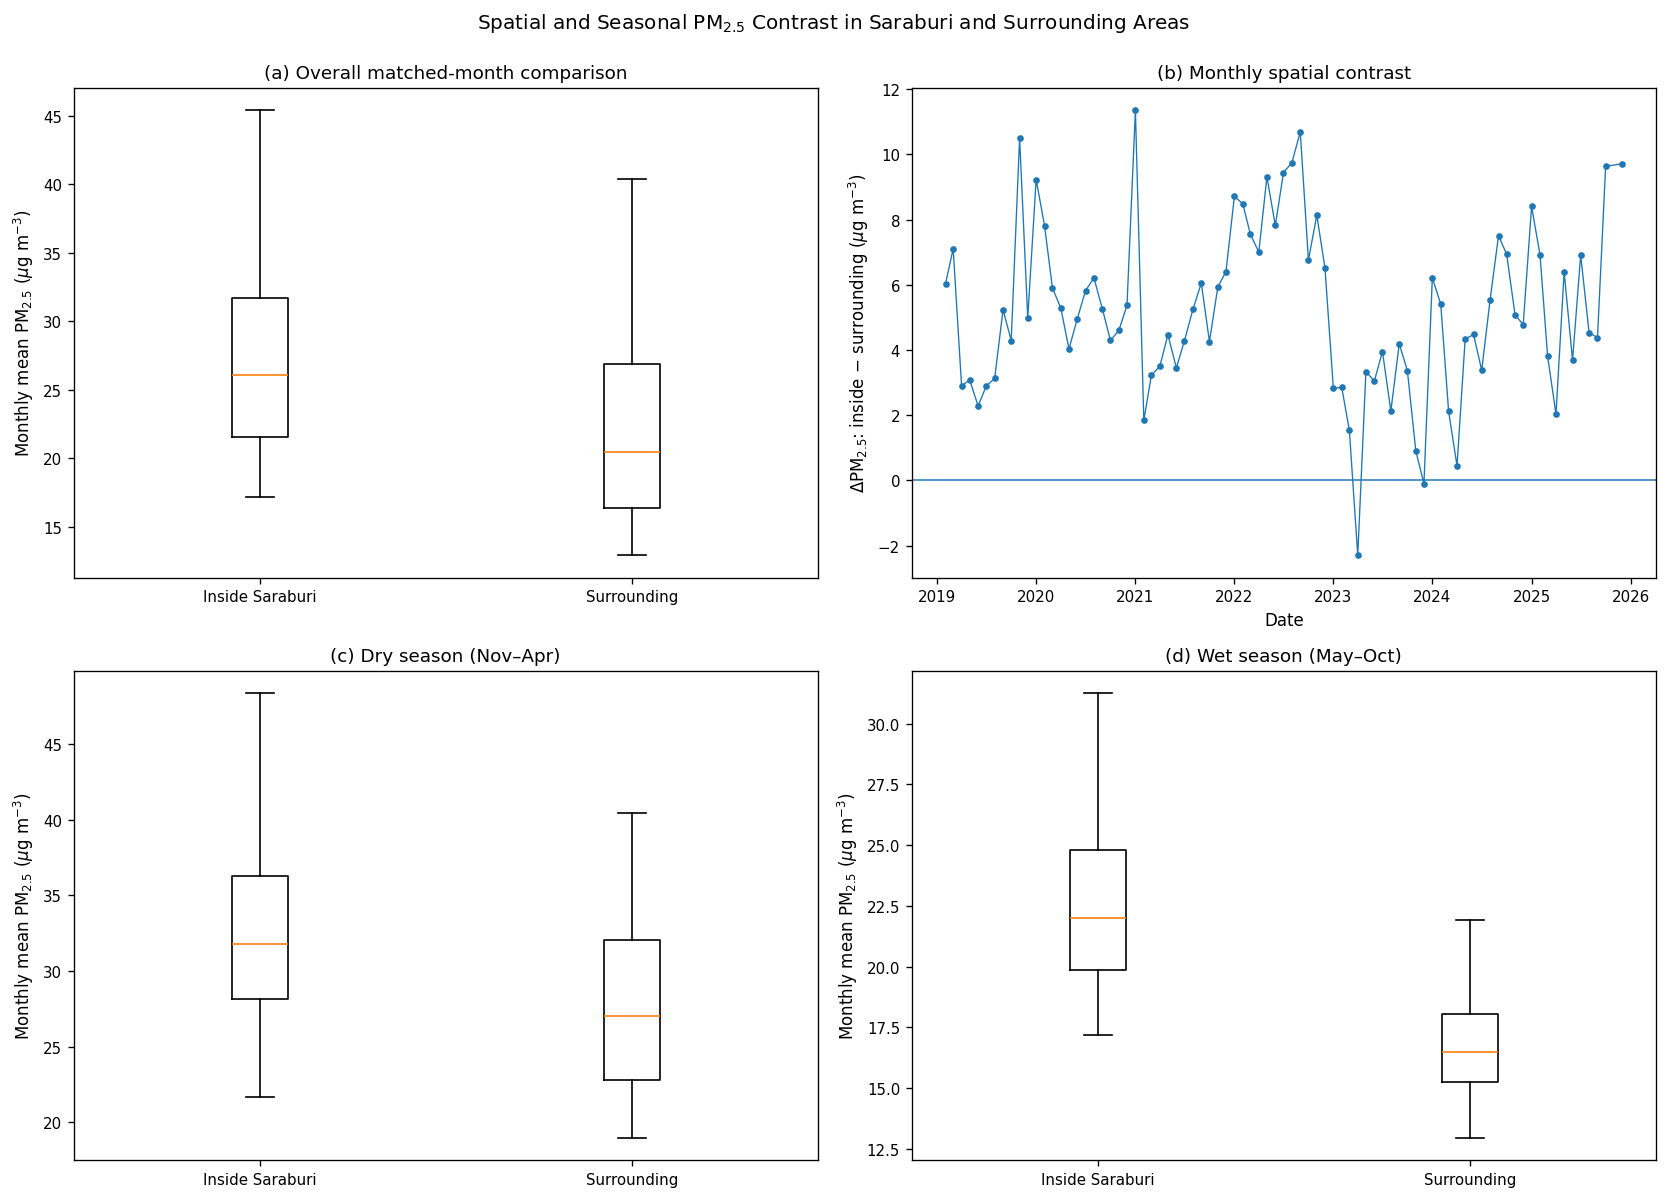

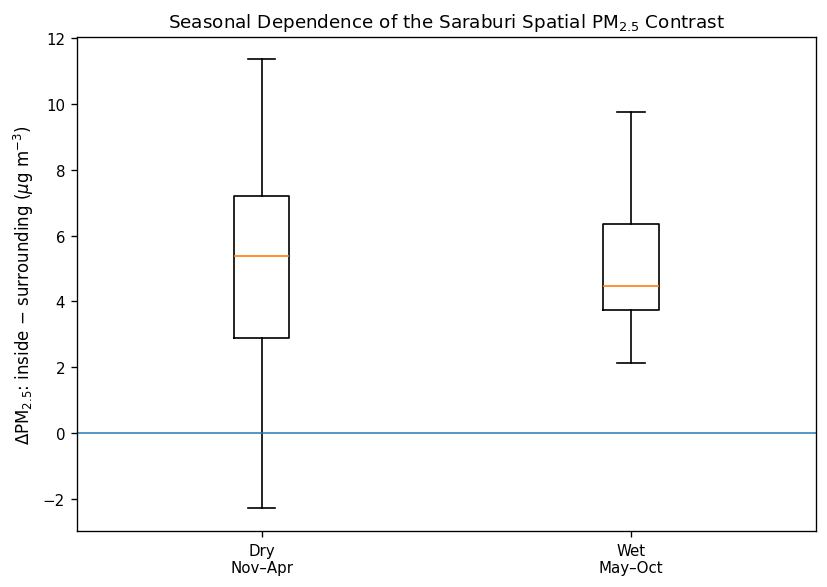

Saved: /content/pm25_saraburi_10yr_outputs/Fig11_inside_vs_surrounding_spatial_seasonal.png
Saved: /content/pm25_saraburi_10yr_outputs/Fig12_spatial_difference_dry_vs_wet.png

✅ Cell 37 completed successfully.

STATION-PAIR SENSITIVITY
                   analysis station_inside station_surrounding  season  n_matched_months  inside_mean  surrounding_mean  mean_delta  median_delta  wilcoxon_W  wilcoxon_p
 core_vs_stable_surrounding            24t                 21t Overall                80      32.6459           22.3439     10.3020        9.8500         0.0      0.0000
 core_vs_stable_surrounding            24t                 21t     Dry                40      38.2280           27.8710     10.3569       10.3534         0.0      0.0000
 core_vs_stable_surrounding            24t                 21t     Wet                40      27.0637           16.8167     10.2471        9.5100         0.0      0.0000
core_vs_nearest_surrounding            24t                 99t Overall              

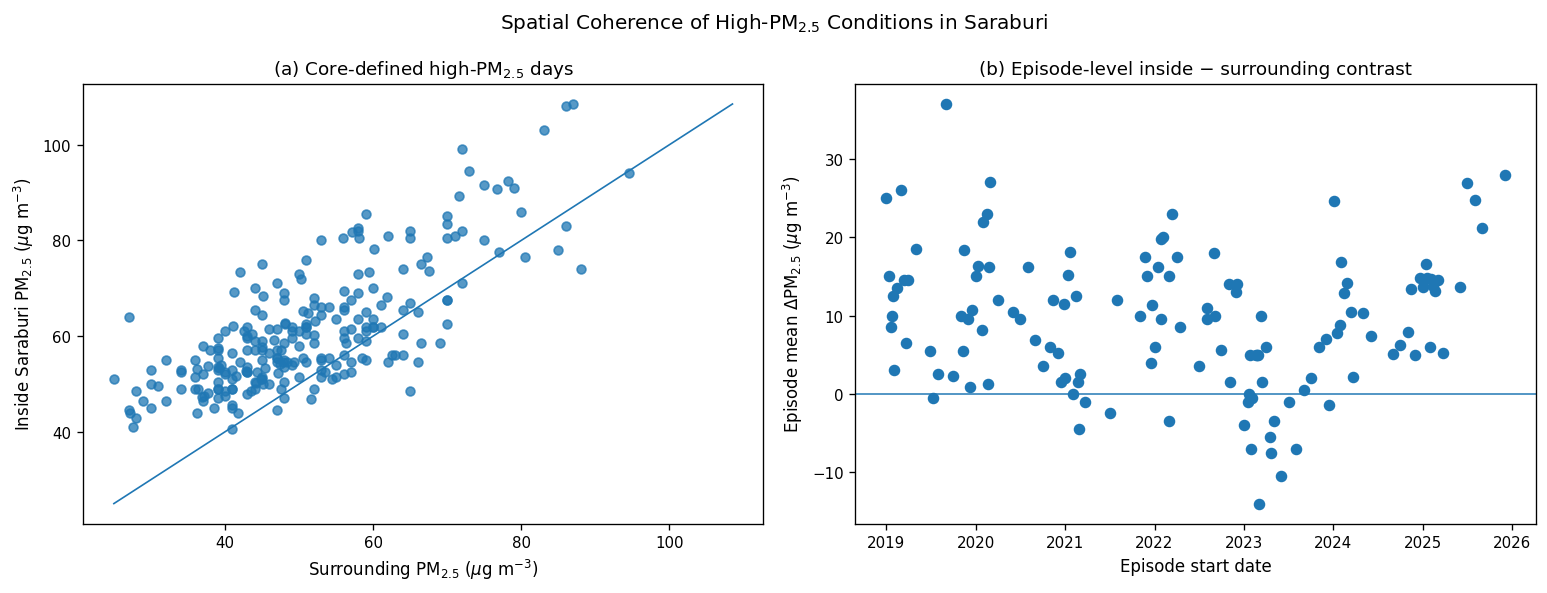

Saved: /content/pm25_saraburi_10yr_outputs/Fig13_high_episode_spatial_coherence.png

Files created by Cells 33–39:
   23_inside_vs_surrounding_daily.csv
   24_inside_vs_surrounding_matched_months.csv
   25_overall_inside_vs_surrounding_statistics.csv
   26_inside_vs_surrounding_by_season.csv
   27_spatial_difference_by_season_cycle.csv
   28_zone_season_interaction_by_year.csv
   29_zone_season_interaction_test.csv
   30_station_pair_sensitivity_results.csv
   31_station_pair_matched_months.csv
   32_high_episode_spatial_summary.csv
   33_high_episode_matched_days.csv
   34_episode_level_spatial_contrast.csv
   Fig11_inside_vs_surrounding_spatial_seasonal.png
   Fig12_spatial_difference_dry_vs_wet.png
   Fig13_high_episode_spatial_coherence.png

✅ Cell 39 completed successfully.


In [ ]:
# =====================================================================
# CELL 33 — CONSTRUCT INSIDE vs SURROUNDING DAILY EXPOSURE
#
# Spatial contrast design:
#   INSIDE      = mean of all available stations physically inside Saraburi
#   SURROUNDING = mean of all available stations outside Saraburi but within
#                 the 25-km study buffer
#
# The inferential analysis below will use only dates/months where BOTH
# spatial groups have sufficient observations.
# =====================================================================

from scipy.stats import wilcoxon, spearmanr

SPATIAL_MATCH_MONTH_FRAC = 0.75
MIN_MONTHS_PER_SEASON_CYCLE = 5
N_BOOT_SPATIAL = 5000

required_objects = [
    "daily_qc",
    "selected",
    "station_longterm",
    "exposure_daily"
]

for obj_name in required_objects:
    if obj_name not in globals():
        raise RuntimeError(
            f"Required object '{obj_name}' is missing. "
            "Run the Saraburi 10-year notebook through Cell 32 first."
        )

# ---------------------------------------------------------------------
# 33.1 Daily inside-Saraburi group mean
# ---------------------------------------------------------------------
inside_spatial_daily = (
    daily_qc[
        daily_qc["tier"] == "inside"
    ]
    .groupby(
        "date",
        as_index=False
    )
    .agg(
        PM25_inside_group=("PM25", "mean"),
        n_inside_group_stations=("stationID", "nunique")
    )
)

# ---------------------------------------------------------------------
# 33.2 Daily surrounding-network group mean
# ---------------------------------------------------------------------
outside_spatial_daily = (
    daily_qc[
        daily_qc["tier"] == "surrounding"
    ]
    .groupby(
        "date",
        as_index=False
    )
    .agg(
        PM25_outside_group=("PM25", "mean"),
        n_outside_group_stations=("stationID", "nunique")
    )
)

# Full daily calendar
spatial_daily = pd.DataFrame({
    "date": pd.date_range(
        f"{STUDY_YEARS[0]}-01-01",
        f"{STUDY_YEARS[-1]}-12-31",
        freq="D"
    )
})

spatial_daily = (
    spatial_daily
    .merge(
        inside_spatial_daily,
        on="date",
        how="left"
    )
    .merge(
        outside_spatial_daily,
        on="date",
        how="left"
    )
)

spatial_daily["year"] = spatial_daily["date"].dt.year
spatial_daily["month"] = spatial_daily["date"].dt.month
spatial_daily["year_month"] = spatial_daily["date"].dt.to_period("M")

spatial_daily["season"] = np.select(
    [
        spatial_daily["month"].isin(WET_MONTHS),
        spatial_daily["month"].isin(DRY_MONTHS)
    ],
    [
        "Wet",
        "Dry"
    ],
    default="Other"
)

# A climatologically coherent season-cycle year:
#   Dry 2018 = Nov-Dec 2017 + Jan-Apr 2018
#   Wet 2018 = May-Oct 2018
spatial_daily["season_cycle_year"] = spatial_daily["year"]

nov_dec = (
    (spatial_daily["season"] == "Dry")
    &
    (spatial_daily["month"].isin([11, 12]))
)

spatial_daily.loc[
    nov_dec,
    "season_cycle_year"
] = (
    spatial_daily.loc[
        nov_dec,
        "year"
    ]
    + 1
)

spatial_daily["matched_day"] = (
    spatial_daily["PM25_inside_group"].notna()
    &
    spatial_daily["PM25_outside_group"].notna()
)

spatial_daily["delta_inside_minus_outside"] = (
    spatial_daily["PM25_inside_group"]
    -
    spatial_daily["PM25_outside_group"]
)

spatial_daily["relative_delta_pct"] = np.where(
    (
        spatial_daily["matched_day"]
        &
        (spatial_daily["PM25_outside_group"] != 0)
    ),
    100.0
    *
    spatial_daily["delta_inside_minus_outside"]
    /
    spatial_daily["PM25_outside_group"],
    np.nan
)

spatial_daily.to_csv(
    os.path.join(
        OUT_DIR,
        "23_inside_vs_surrounding_daily.csv"
    ),
    index=False
)

print("\nDAILY SPATIAL COVERAGE")
print("=" * 100)

print(
    "Inside available     :",
    f"{spatial_daily['PM25_inside_group'].notna().sum():,}",
    "days"
)

print(
    "Surrounding available:",
    f"{spatial_daily['PM25_outside_group'].notna().sum():,}",
    "days"
)

print(
    "Matched inside+outside:",
    f"{spatial_daily['matched_day'].sum():,}",
    "days"
)

print("\n✅ Cell 33 completed successfully.")


# ================================================================================
# COPY AS CELL 34
# ================================================================================
# =====================================================================
# CELL 34 — MATCHED-MONTH QUALITY CONTROL
#
# A month is retained only when:
#   1) inside observations exist on >=75% of calendar days
#   2) surrounding observations exist on >=75% of calendar days
#   3) BOTH groups overlap on >=75% of calendar days
#
# Monthly inside and outside means are calculated from the EXACT SAME
# matched days. This removes day-of-month sampling mismatch.
# =====================================================================

matched_month_rows = []

for period, g in spatial_daily.groupby(
    "year_month",
    sort=True
):
    days_in_month = period.days_in_month

    inside_valid_days = int(
        g["PM25_inside_group"]
        .notna()
        .sum()
    )

    outside_valid_days = int(
        g["PM25_outside_group"]
        .notna()
        .sum()
    )

    matched = g[
        g["matched_day"]
    ].copy()

    matched_days = len(matched)

    inside_fraction = (
        inside_valid_days
        /
        days_in_month
    )

    outside_fraction = (
        outside_valid_days
        /
        days_in_month
    )

    matched_fraction = (
        matched_days
        /
        days_in_month
    )

    month_pass = (
        inside_fraction >= SPATIAL_MATCH_MONTH_FRAC
        and
        outside_fraction >= SPATIAL_MATCH_MONTH_FRAC
        and
        matched_fraction >= SPATIAL_MATCH_MONTH_FRAC
    )

    # Contributing stations during this calendar month
    station_month = daily_qc[
        (
            daily_qc["date"].dt.to_period("M")
            == period
        )
    ]

    inside_ids = sorted(
        station_month.loc[
            station_month["tier"] == "inside",
            "stationID"
        ]
        .dropna()
        .unique()
        .tolist()
    )

    outside_ids = sorted(
        station_month.loc[
            station_month["tier"] == "surrounding",
            "stationID"
        ]
        .dropna()
        .unique()
        .tolist()
    )

    if month_pass and matched_days > 0:

        inside_mean = matched[
            "PM25_inside_group"
        ].mean()

        outside_mean = matched[
            "PM25_outside_group"
        ].mean()

        delta_mean = (
            inside_mean
            -
            outside_mean
        )

        relative_delta = (
            100.0
            *
            delta_mean
            /
            outside_mean
            if outside_mean != 0
            else np.nan
        )

    else:
        inside_mean = np.nan
        outside_mean = np.nan
        delta_mean = np.nan
        relative_delta = np.nan

    month = period.month
    year = period.year

    season = (
        "Wet"
        if month in WET_MONTHS
        else "Dry"
        if month in DRY_MONTHS
        else "Other"
    )

    season_cycle_year = (
        year + 1
        if (
            season == "Dry"
            and
            month in [11, 12]
        )
        else year
    )

    matched_month_rows.append({
        "year_month": period,
        "year": year,
        "month": month,
        "season": season,
        "season_cycle_year": season_cycle_year,
        "days_in_month": days_in_month,
        "inside_valid_days": inside_valid_days,
        "outside_valid_days": outside_valid_days,
        "matched_days": matched_days,
        "inside_fraction": inside_fraction,
        "outside_fraction": outside_fraction,
        "matched_fraction": matched_fraction,
        "month_pass": month_pass,
        "inside_station_ids": ",".join(inside_ids),
        "outside_station_ids": ",".join(outside_ids),
        "n_inside_station_ids": len(inside_ids),
        "n_outside_station_ids": len(outside_ids),
        "inside_mean_pm25": inside_mean,
        "outside_mean_pm25": outside_mean,
        "delta_inside_minus_outside": delta_mean,
        "relative_delta_pct": relative_delta
    })

matched_month = pd.DataFrame(
    matched_month_rows
)

matched_month.to_csv(
    os.path.join(
        OUT_DIR,
        "24_inside_vs_surrounding_matched_months.csv"
    ),
    index=False
)

matched_month_pass = matched_month[
    matched_month["month_pass"]
].copy()

print("\nMATCHED-MONTH SPATIAL QA")
print("=" * 110)

print(
    "Passing matched months:",
    len(matched_month_pass),
    "/",
    len(matched_month)
)

print(
    "Dry passing months:",
    int(
        (
            matched_month_pass["season"]
            == "Dry"
        ).sum()
    )
)

print(
    "Wet passing months:",
    int(
        (
            matched_month_pass["season"]
            == "Wet"
        ).sum()
    )
)

if len(matched_month_pass) > 0:
    print(
        "\nMean matched-day coverage:",
        f"{100*matched_month_pass['matched_fraction'].mean():.1f}%"
    )

print("\n✅ Cell 34 completed successfully.")


# ================================================================================
# COPY AS CELL 35
# ================================================================================
# =====================================================================
# CELL 35 — OVERALL INSIDE vs SURROUNDING COMPARISON
#
# Main simple inferential test:
#   paired Wilcoxon signed-rank test on matched monthly means.
#
# Also calculates:
#   mean / median spatial difference
#   relative difference
#   year-block bootstrap 95% CI
# =====================================================================

def paired_wilcoxon_safe(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    valid = (
        np.isfinite(x)
        &
        np.isfinite(y)
    )

    x = x[valid]
    y = y[valid]

    if len(x) == 0:
        return np.nan, np.nan

    diff = x - y

    if np.allclose(
        diff,
        0
    ):
        return 0.0, 1.0

    result = wilcoxon(
        x,
        y,
        alternative="two-sided"
    )

    return (
        float(result.statistic),
        float(result.pvalue)
    )


def year_block_bootstrap_spatial_difference(
    monthly_df,
    n_boot=N_BOOT_SPATIAL,
    seed=2026
):
    d = monthly_df.dropna(
        subset=[
            "delta_inside_minus_outside"
        ]
    ).copy()

    years = sorted(
        d["year"]
        .unique()
        .tolist()
    )

    if len(years) < 2:
        return {
            "mean_delta_ci95_low": np.nan,
            "mean_delta_ci95_high": np.nan,
            "median_delta_ci95_low": np.nan,
            "median_delta_ci95_high": np.nan,
            "n_boot_valid": 0
        }

    by_year = {
        int(year): d[
            d["year"] == year
        ][
            "delta_inside_minus_outside"
        ].dropna().to_numpy()
        for year in years
    }

    rng = np.random.default_rng(
        seed
    )

    boot_mean = []
    boot_median = []

    for _ in range(
        n_boot
    ):
        sampled_years = rng.choice(
            years,
            size=len(years),
            replace=True
        )

        vals = []

        for year in sampled_years:
            vals.extend(
                by_year[
                    int(year)
                ].tolist()
            )

        if len(vals) > 0:
            boot_mean.append(
                np.mean(vals)
            )
            boot_median.append(
                np.median(vals)
            )

    if len(boot_mean) > 100:
        mean_low, mean_high = np.percentile(
            boot_mean,
            [2.5, 97.5]
        )

        median_low, median_high = np.percentile(
            boot_median,
            [2.5, 97.5]
        )

    else:
        mean_low = mean_high = np.nan
        median_low = median_high = np.nan

    return {
        "mean_delta_ci95_low": mean_low,
        "mean_delta_ci95_high": mean_high,
        "median_delta_ci95_low": median_low,
        "median_delta_ci95_high": median_high,
        "n_boot_valid": len(boot_mean)
    }


spatial_overall = matched_month_pass.dropna(
    subset=[
        "inside_mean_pm25",
        "outside_mean_pm25"
    ]
).copy()

W, p = paired_wilcoxon_safe(
    spatial_overall[
        "inside_mean_pm25"
    ],
    spatial_overall[
        "outside_mean_pm25"
    ]
)

boot_spatial = (
    year_block_bootstrap_spatial_difference(
        spatial_overall
    )
)

overall_spatial_table = pd.DataFrame([
    {
        "n_matched_months": len(
            spatial_overall
        ),
        "inside_mean_pm25": spatial_overall[
            "inside_mean_pm25"
        ].mean(),
        "inside_median_pm25": spatial_overall[
            "inside_mean_pm25"
        ].median(),
        "outside_mean_pm25": spatial_overall[
            "outside_mean_pm25"
        ].mean(),
        "outside_median_pm25": spatial_overall[
            "outside_mean_pm25"
        ].median(),
        "mean_delta_inside_minus_outside": spatial_overall[
            "delta_inside_minus_outside"
        ].mean(),
        "median_delta_inside_minus_outside": spatial_overall[
            "delta_inside_minus_outside"
        ].median(),
        "mean_relative_delta_pct": spatial_overall[
            "relative_delta_pct"
        ].mean(),
        "months_inside_higher_pct": (
            100.0
            *
            (
                spatial_overall[
                    "delta_inside_minus_outside"
                ]
                > 0
            )
            .mean()
        ),
        "wilcoxon_W": W,
        "wilcoxon_p": p,
        **boot_spatial
    }
])

overall_spatial_table.to_csv(
    os.path.join(
        OUT_DIR,
        "25_overall_inside_vs_surrounding_statistics.csv"
    ),
    index=False
)

print("\nOVERALL INSIDE vs SURROUNDING — MATCHED MONTHS")
print("=" * 130)

print(
    overall_spatial_table
    .round(4)
    .to_string(index=False)
)

print(
    "\nPositive ΔPM2.5 = inside Saraburi higher than the surrounding network."
)

print("\n✅ Cell 35 completed successfully.")


# ================================================================================
# COPY AS CELL 36
# ================================================================================
# =====================================================================
# CELL 36 — DRY vs WET SPATIAL CONTRAST + ZONE × SEASON INTERACTION
#
# Part A:
#   Inside vs outside within Dry months
#   Inside vs outside within Wet months
#
# Part B:
#   Is the spatial contrast itself different between seasons?
#
# For the interaction, use coherent season-cycle years:
#   Dry 2018 = Nov-Dec 2017 + Jan-Apr 2018
#   Wet 2018 = May-Oct 2018
#
# Then compare yearly Dry ΔPM2.5 vs Wet ΔPM2.5 using paired Wilcoxon.
# =====================================================================

season_spatial_rows = []

for season in [
    "Dry",
    "Wet"
]:
    d = matched_month_pass[
        matched_month_pass[
            "season"
        ] == season
    ].dropna(
        subset=[
            "inside_mean_pm25",
            "outside_mean_pm25"
        ]
    ).copy()

    W, p = paired_wilcoxon_safe(
        d["inside_mean_pm25"],
        d["outside_mean_pm25"]
    )

    boot = year_block_bootstrap_spatial_difference(
        d,
        n_boot=N_BOOT_SPATIAL,
        seed=(
            3101
            if season == "Dry"
            else 3102
        )
    )

    season_spatial_rows.append({
        "season": season,
        "n_matched_months": len(d),
        "inside_mean_pm25": d[
            "inside_mean_pm25"
        ].mean(),
        "inside_median_pm25": d[
            "inside_mean_pm25"
        ].median(),
        "outside_mean_pm25": d[
            "outside_mean_pm25"
        ].mean(),
        "outside_median_pm25": d[
            "outside_mean_pm25"
        ].median(),
        "mean_delta_inside_minus_outside": d[
            "delta_inside_minus_outside"
        ].mean(),
        "median_delta_inside_minus_outside": d[
            "delta_inside_minus_outside"
        ].median(),
        "mean_relative_delta_pct": d[
            "relative_delta_pct"
        ].mean(),
        "wilcoxon_W": W,
        "wilcoxon_p": p,
        **boot
    })

season_spatial_table = pd.DataFrame(
    season_spatial_rows
)

season_spatial_table.to_csv(
    os.path.join(
        OUT_DIR,
        "26_inside_vs_surrounding_by_season.csv"
    ),
    index=False
)

# ---------------------------------------------------------------------
# 36.2 Build coherent season-cycle summaries
# ---------------------------------------------------------------------
season_cycle_rows = []

for keys, g in matched_month_pass.groupby(
    [
        "season_cycle_year",
        "season"
    ],
    sort=True
):
    cycle_year, season = keys

    if season not in [
        "Dry",
        "Wet"
    ]:
        continue

    valid_months = len(g)

    if valid_months < MIN_MONTHS_PER_SEASON_CYCLE:
        continue

    season_cycle_rows.append({
        "season_cycle_year": int(
            cycle_year
        ),
        "season": season,
        "n_months": valid_months,
        "inside_mean_pm25": g[
            "inside_mean_pm25"
        ].mean(),
        "outside_mean_pm25": g[
            "outside_mean_pm25"
        ].mean(),
        "delta_inside_minus_outside": g[
            "delta_inside_minus_outside"
        ].mean()
    })

season_cycle = pd.DataFrame(
    season_cycle_rows
)

season_cycle.to_csv(
    os.path.join(
        OUT_DIR,
        "27_spatial_difference_by_season_cycle.csv"
    ),
    index=False
)

# Manual paired dry/wet year table.
interaction_rows = []

if not season_cycle.empty:

    candidate_years = sorted(
        season_cycle[
            "season_cycle_year"
        ]
        .unique()
        .tolist()
    )

    for year in candidate_years:

        dry_row = season_cycle[
            (
                season_cycle[
                    "season_cycle_year"
                ] == year
            )
            &
            (
                season_cycle[
                    "season"
                ] == "Dry"
            )
        ]

        wet_row = season_cycle[
            (
                season_cycle[
                    "season_cycle_year"
                ] == year
            )
            &
            (
                season_cycle[
                    "season"
                ] == "Wet"
            )
        ]

        if (
            len(dry_row) == 1
            and
            len(wet_row) == 1
        ):

            dry_delta = float(
                dry_row[
                    "delta_inside_minus_outside"
                ].iloc[0]
            )

            wet_delta = float(
                wet_row[
                    "delta_inside_minus_outside"
                ].iloc[0]
            )

            interaction_rows.append({
                "season_cycle_year": int(year),
                "dry_delta": dry_delta,
                "wet_delta": wet_delta,
                "dry_minus_wet_delta": (
                    dry_delta
                    -
                    wet_delta
                )
            })

interaction_year = pd.DataFrame(
    interaction_rows
)

if len(interaction_year) > 0:

    W_interaction, p_interaction = paired_wilcoxon_safe(
        interaction_year[
            "dry_delta"
        ],
        interaction_year[
            "wet_delta"
        ]
    )

    interaction_table = pd.DataFrame([
        {
            "n_paired_season_years": len(
                interaction_year
            ),
            "mean_dry_delta": interaction_year[
                "dry_delta"
            ].mean(),
            "mean_wet_delta": interaction_year[
                "wet_delta"
            ].mean(),
            "mean_interaction_dry_minus_wet": interaction_year[
                "dry_minus_wet_delta"
            ].mean(),
            "median_interaction_dry_minus_wet": interaction_year[
                "dry_minus_wet_delta"
            ].median(),
            "wilcoxon_W": W_interaction,
            "wilcoxon_p": p_interaction
        }
    ])

else:

    interaction_table = pd.DataFrame([
        {
            "n_paired_season_years": 0,
            "mean_dry_delta": np.nan,
            "mean_wet_delta": np.nan,
            "mean_interaction_dry_minus_wet": np.nan,
            "median_interaction_dry_minus_wet": np.nan,
            "wilcoxon_W": np.nan,
            "wilcoxon_p": np.nan
        }
    ])

interaction_year.to_csv(
    os.path.join(
        OUT_DIR,
        "28_zone_season_interaction_by_year.csv"
    ),
    index=False
)

interaction_table.to_csv(
    os.path.join(
        OUT_DIR,
        "29_zone_season_interaction_test.csv"
    ),
    index=False
)

print("\nINSIDE vs SURROUNDING BY SEASON")
print("=" * 130)

print(
    season_spatial_table
    .round(4)
    .to_string(index=False)
)

print("\nZONE × SEASON INTERACTION")
print("=" * 110)

print(
    interaction_table
    .round(4)
    .to_string(index=False)
)

print(
    "\nPositive interaction = the inside-minus-outside contrast is larger "
    "during the dry season than during the wet season."
)

print("\n✅ Cell 36 completed successfully.")


# ================================================================================
# COPY AS CELL 37
# ================================================================================
# =====================================================================
# CELL 37 — PUBLICATION FIGURES FOR SPATIAL-SEASONAL CONTRAST
#
# Figure 11:
#   (a) Overall inside vs surrounding monthly distributions
#   (b) Monthly inside-minus-surrounding difference through time
#   (c) Dry-season inside vs surrounding
#   (d) Wet-season inside vs surrounding
#
# Figure 12:
#   Dry vs Wet distribution of the spatial difference ΔPM2.5
# =====================================================================

# ---------------------------------------------------------------------
# Figure 11
# ---------------------------------------------------------------------
fig, axes = plt.subplots(
    2,
    2,
    figsize=(14, 10)
)

# (a) Overall matched monthly distributions
axes[0, 0].boxplot(
    [
        spatial_overall[
            "inside_mean_pm25"
        ].to_numpy(),
        spatial_overall[
            "outside_mean_pm25"
        ].to_numpy()
    ],
    labels=[
        "Inside Saraburi",
        "Surrounding"
    ],
    showfliers=False
)

axes[0, 0].set_ylabel(
    "Monthly mean PM$_{2.5}$ ($\\mu$g m$^{-3}$)"
)

axes[0, 0].set_title(
    "(a) Overall matched-month comparison"
)

# (b) Monthly spatial difference
plot_month = matched_month_pass.copy()

plot_month["plot_date"] = (
    plot_month[
        "year_month"
    ]
    .dt.to_timestamp()
)

axes[0, 1].plot(
    plot_month[
        "plot_date"
    ],
    plot_month[
        "delta_inside_minus_outside"
    ],
    marker="o",
    markersize=3,
    linewidth=0.8
)

axes[0, 1].axhline(
    0,
    linewidth=0.9
)

axes[0, 1].set_xlabel(
    "Date"
)

axes[0, 1].set_ylabel(
    "$\\Delta$PM$_{2.5}$: inside − surrounding "
    "($\\mu$g m$^{-3}$)"
)

axes[0, 1].set_title(
    "(b) Monthly spatial contrast"
)

# (c) Dry
dry_months = matched_month_pass[
    matched_month_pass[
        "season"
    ] == "Dry"
]

axes[1, 0].boxplot(
    [
        dry_months[
            "inside_mean_pm25"
        ].to_numpy(),
        dry_months[
            "outside_mean_pm25"
        ].to_numpy()
    ],
    labels=[
        "Inside Saraburi",
        "Surrounding"
    ],
    showfliers=False
)

axes[1, 0].set_ylabel(
    "Monthly mean PM$_{2.5}$ ($\\mu$g m$^{-3}$)"
)

axes[1, 0].set_title(
    "(c) Dry season (Nov–Apr)"
)

# (d) Wet
wet_months = matched_month_pass[
    matched_month_pass[
        "season"
    ] == "Wet"
]

axes[1, 1].boxplot(
    [
        wet_months[
            "inside_mean_pm25"
        ].to_numpy(),
        wet_months[
            "outside_mean_pm25"
        ].to_numpy()
    ],
    labels=[
        "Inside Saraburi",
        "Surrounding"
    ],
    showfliers=False
)

axes[1, 1].set_ylabel(
    "Monthly mean PM$_{2.5}$ ($\\mu$g m$^{-3}$)"
)

axes[1, 1].set_title(
    "(d) Wet season (May–Oct)"
)

fig.suptitle(
    "Spatial and Seasonal PM$_{2.5}$ Contrast in Saraburi and Surrounding Areas",
    y=0.995
)

plt.tight_layout()

fig11_path = os.path.join(
    OUT_DIR,
    "Fig11_inside_vs_surrounding_spatial_seasonal.png"
)

plt.savefig(
    fig11_path,
    dpi=FIG_DPI,
    bbox_inches="tight"
)

plt.show()

# ---------------------------------------------------------------------
# Figure 12 — spatial difference by season
# ---------------------------------------------------------------------
fig, ax = plt.subplots(
    figsize=(7, 5)
)

ax.boxplot(
    [
        dry_months[
            "delta_inside_minus_outside"
        ].dropna().to_numpy(),
        wet_months[
            "delta_inside_minus_outside"
        ].dropna().to_numpy()
    ],
    labels=[
        "Dry\nNov–Apr",
        "Wet\nMay–Oct"
    ],
    showfliers=False
)

ax.axhline(
    0,
    linewidth=0.9
)

ax.set_ylabel(
    "$\\Delta$PM$_{2.5}$: inside − surrounding "
    "($\\mu$g m$^{-3}$)"
)

ax.set_title(
    "Seasonal Dependence of the Saraburi Spatial PM$_{2.5}$ Contrast"
)

plt.tight_layout()

fig12_path = os.path.join(
    OUT_DIR,
    "Fig12_spatial_difference_dry_vs_wet.png"
)

plt.savefig(
    fig12_path,
    dpi=FIG_DPI,
    bbox_inches="tight"
)

plt.show()

print("Saved:", fig11_path)
print("Saved:", fig12_path)

print("\n✅ Cell 37 completed successfully.")


# ================================================================================
# COPY AS CELL 38
# ================================================================================
# =====================================================================
# CELL 38 — STATION-PAIR SENSITIVITY ANALYSIS
#
# Two secondary comparisons are selected automatically:
#
#   1) Core Saraburi station vs BEST-COVERED surrounding station
#   2) Core Saraburi station vs NEAREST surrounding station
#
# In the current dataset this is expected to approximate:
#   24T vs 21T  (stable-network sensitivity)
#   24T vs 99T  (nearest-neighbor sensitivity)
#
# Comparisons are matched by day and screened by monthly completeness.
# =====================================================================

if len(core_station_ids) == 0:
    raise RuntimeError(
        "No core Saraburi station is available."
    )

core_reference_station = core_station_ids[0]

surrounding_rank = (
    station_longterm[
        station_longterm[
            "tier"
        ] == "surrounding"
    ]
    .sort_values(
        [
            "adequate_years",
            "valid_months_total"
        ],
        ascending=False
    )
)

stable_outside_station = (
    surrounding_rank[
        "stationID"
    ].iloc[0]
    if len(surrounding_rank) > 0
    else None
)

nearest_outside_rank = (
    selected[
        selected[
            "tier"
        ] == "surrounding"
    ]
    .sort_values(
        "distance_to_saraburi_km"
    )
)

nearest_outside_station = (
    nearest_outside_rank[
        "stationID"
    ].iloc[0]
    if len(nearest_outside_rank) > 0
    else None
)


def matched_station_months(
    station_a,
    station_b,
    min_frac=SPATIAL_MATCH_MONTH_FRAC
):
    a = (
        daily_qc[
            daily_qc[
                "stationID"
            ] == station_a
        ][
            [
                "date",
                "PM25"
            ]
        ]
        .rename(
            columns={
                "PM25": "pm25_a"
            }
        )
    )

    b = (
        daily_qc[
            daily_qc[
                "stationID"
            ] == station_b
        ][
            [
                "date",
                "PM25"
            ]
        ]
        .rename(
            columns={
                "PM25": "pm25_b"
            }
        )
    )

    paired_day = a.merge(
        b,
        on="date",
        how="inner",
        validate="one_to_one"
    )

    if paired_day.empty:
        return pd.DataFrame()

    paired_day["year_month"] = (
        paired_day[
            "date"
        ]
        .dt.to_period(
            "M"
        )
    )

    rows = []

    for period, g in paired_day.groupby(
        "year_month",
        sort=True
    ):
        matched_days = len(g)

        pass_month = (
            matched_days
            /
            period.days_in_month
            >=
            min_frac
        )

        if not pass_month:
            continue

        month = period.month

        season = (
            "Wet"
            if month in WET_MONTHS
            else "Dry"
        )

        rows.append({
            "station_a": station_a,
            "station_b": station_b,
            "year_month": period,
            "year": period.year,
            "month": month,
            "season": season,
            "matched_days": matched_days,
            "mean_a": g[
                "pm25_a"
            ].mean(),
            "mean_b": g[
                "pm25_b"
            ].mean(),
            "delta_a_minus_b": (
                g[
                    "pm25_a"
                ].mean()
                -
                g[
                    "pm25_b"
                ].mean()
            )
        })

    return pd.DataFrame(
        rows
    )


pair_specs = []

if stable_outside_station is not None:
    pair_specs.append(
        (
            "core_vs_stable_surrounding",
            core_reference_station,
            stable_outside_station
        )
    )

if (
    nearest_outside_station is not None
    and
    nearest_outside_station
    !=
    stable_outside_station
):
    pair_specs.append(
        (
            "core_vs_nearest_surrounding",
            core_reference_station,
            nearest_outside_station
        )
    )

pair_result_rows = []
pair_month_frames = []

for analysis_name, station_a, station_b in pair_specs:

    pair_month = matched_station_months(
        station_a,
        station_b
    )

    if pair_month.empty:
        continue

    pair_month[
        "analysis"
    ] = analysis_name

    pair_month_frames.append(
        pair_month
    )

    for season in [
        "Overall",
        "Dry",
        "Wet"
    ]:

        if season == "Overall":
            d = pair_month.copy()
        else:
            d = pair_month[
                pair_month[
                    "season"
                ] == season
            ].copy()

        if len(d) == 0:
            continue

        W, p = paired_wilcoxon_safe(
            d["mean_a"],
            d["mean_b"]
        )

        pair_result_rows.append({
            "analysis": analysis_name,
            "station_inside": station_a,
            "station_surrounding": station_b,
            "season": season,
            "n_matched_months": len(d),
            "inside_mean": d[
                "mean_a"
            ].mean(),
            "surrounding_mean": d[
                "mean_b"
            ].mean(),
            "mean_delta": d[
                "delta_a_minus_b"
            ].mean(),
            "median_delta": d[
                "delta_a_minus_b"
            ].median(),
            "wilcoxon_W": W,
            "wilcoxon_p": p
        })

station_pair_results = pd.DataFrame(
    pair_result_rows
)

if pair_month_frames:
    station_pair_months = pd.concat(
        pair_month_frames,
        ignore_index=True
    )
else:
    station_pair_months = pd.DataFrame()

station_pair_results.to_csv(
    os.path.join(
        OUT_DIR,
        "30_station_pair_sensitivity_results.csv"
    ),
    index=False
)

station_pair_months.to_csv(
    os.path.join(
        OUT_DIR,
        "31_station_pair_matched_months.csv"
    ),
    index=False
)

print("\nSTATION-PAIR SENSITIVITY")
print("=" * 130)

if station_pair_results.empty:
    print(
        "No station pair had sufficient matched monthly coverage."
    )
else:
    print(
        station_pair_results
        .round(4)
        .to_string(index=False)
    )

print(
    "\nStable surrounding station:",
    stable_outside_station
)

print(
    "Nearest surrounding station:",
    nearest_outside_station
)

print("\n✅ Cell 38 completed successfully.")


# ================================================================================
# COPY AS CELL 39
# ================================================================================
# =====================================================================
# CELL 39 — HIGH-PM2.5 EPISODE SPATIAL COHERENCE
#
# Question:
# During high-PM2.5 conditions defined from the Saraburi core series,
# does the surrounding network rise simultaneously?
#
# Outputs:
#   - daily high-event spatial statistics
#   - fraction of high days that are regionally high
#   - episode-level inside/outside spatial contrast
#   - Figure 13
# =====================================================================

# Recover threshold if Cell 28 variables are unavailable.
if "episode_threshold" not in globals():

    if "EPISODE_THRESHOLD_UGM3" in globals() and (
        EPISODE_THRESHOLD_UGM3 is not None
    ):
        episode_threshold = float(
            EPISODE_THRESHOLD_UGM3
        )

    else:
        episode_threshold = float(
            exposure_daily[
                "PM25_core"
            ]
            .dropna()
            .quantile(
                EPISODE_PERCENTILE
                if "EPISODE_PERCENTILE" in globals()
                else 0.90
            )
        )

episode_spatial = spatial_daily.merge(
    exposure_daily[
        [
            "date",
            "PM25_core"
        ]
    ],
    on="date",
    how="left",
    validate="one_to_one"
)

episode_spatial["core_high_day"] = (
    episode_spatial[
        "PM25_core"
    ]
    >=
    episode_threshold
)

high_matched = episode_spatial[
    (
        episode_spatial[
            "core_high_day"
        ]
    )
    &
    (
        episode_spatial[
            "matched_day"
        ]
    )
].copy()

high_matched["outside_also_high"] = (
    high_matched[
        "PM25_outside_group"
    ]
    >=
    episode_threshold
)

high_matched[
    "delta_inside_minus_outside"
] = (
    high_matched[
        "PM25_inside_group"
    ]
    -
    high_matched[
        "PM25_outside_group"
    ]
)

if len(high_matched) >= 3:

    rho_result = spearmanr(
        high_matched[
            "PM25_inside_group"
        ],
        high_matched[
            "PM25_outside_group"
        ],
        nan_policy="omit"
    )

    rho = float(
        rho_result.statistic
    )

    rho_p = float(
        rho_result.pvalue
    )

else:
    rho = np.nan
    rho_p = np.nan

episode_spatial_summary = pd.DataFrame([
    {
        "threshold_ug_m3": episode_threshold,
        "n_core_high_days": int(
            episode_spatial[
                "core_high_day"
            ].sum()
        ),
        "n_core_high_days_with_matched_spatial_data": len(
            high_matched
        ),
        "inside_mean_on_high_days": high_matched[
            "PM25_inside_group"
        ].mean(),
        "outside_mean_on_high_days": high_matched[
            "PM25_outside_group"
        ].mean(),
        "mean_delta_inside_minus_outside": high_matched[
            "delta_inside_minus_outside"
        ].mean(),
        "median_delta_inside_minus_outside": high_matched[
            "delta_inside_minus_outside"
        ].median(),
        "regional_high_days": int(
            high_matched[
                "outside_also_high"
            ].sum()
        ),
        "regional_high_fraction_pct": (
            100.0
            *
            high_matched[
                "outside_also_high"
            ].mean()
            if len(high_matched) > 0
            else np.nan
        ),
        "spearman_inside_outside_rho": rho,
        "spearman_p": rho_p
    }
])

episode_spatial_summary.to_csv(
    os.path.join(
        OUT_DIR,
        "32_high_episode_spatial_summary.csv"
    ),
    index=False
)

high_matched.to_csv(
    os.path.join(
        OUT_DIR,
        "33_high_episode_matched_days.csv"
    ),
    index=False
)

# ---------------------------------------------------------------------
# Episode-level spatial contrast
# Reuse the core-defined episode table when available.
# ---------------------------------------------------------------------
episode_level_rows = []

if (
    "episodes" in globals()
    and
    isinstance(
        episodes,
        pd.DataFrame
    )
    and
    len(episodes) > 0
):

    for _, ep in episodes.iterrows():

        start_date = pd.to_datetime(
            ep["start_date"]
        )

        end_date = pd.to_datetime(
            ep["end_date"]
        )

        d = episode_spatial[
            (
                episode_spatial[
                    "date"
                ] >= start_date
            )
            &
            (
                episode_spatial[
                    "date"
                ] <= end_date
            )
            &
            (
                episode_spatial[
                    "matched_day"
                ]
            )
        ].copy()

        if len(d) == 0:
            continue

        episode_level_rows.append({
            "episode_id": ep[
                "episode_id"
            ],
            "start_date": start_date,
            "end_date": end_date,
            "episode_duration_days": ep[
                "duration_days"
            ],
            "matched_spatial_days": len(d),
            "inside_mean_pm25": d[
                "PM25_inside_group"
            ].mean(),
            "outside_mean_pm25": d[
                "PM25_outside_group"
            ].mean(),
            "delta_inside_minus_outside": (
                d[
                    "PM25_inside_group"
                ].mean()
                -
                d[
                    "PM25_outside_group"
                ].mean()
            ),
            "outside_high_fraction_pct": (
                100.0
                *
                (
                    d[
                        "PM25_outside_group"
                    ]
                    >=
                    episode_threshold
                )
                .mean()
            )
        })

episode_level_spatial = pd.DataFrame(
    episode_level_rows
)

episode_level_spatial.to_csv(
    os.path.join(
        OUT_DIR,
        "34_episode_level_spatial_contrast.csv"
    ),
    index=False
)

print("\nHIGH-PM2.5 SPATIAL COHERENCE")
print("=" * 120)

print(
    episode_spatial_summary
    .round(4)
    .to_string(index=False)
)

# ---------------------------------------------------------------------
# Figure 13
# ---------------------------------------------------------------------
fig, axes = plt.subplots(
    1,
    2,
    figsize=(13, 5)
)

# (a) High-day inside vs outside
if len(high_matched) > 0:

    axes[0].scatter(
        high_matched[
            "PM25_outside_group"
        ],
        high_matched[
            "PM25_inside_group"
        ],
        s=28,
        alpha=0.75
    )

    all_vals = np.concatenate(
        [
            high_matched[
                "PM25_outside_group"
            ].dropna().to_numpy(),
            high_matched[
                "PM25_inside_group"
            ].dropna().to_numpy()
        ]
    )

    if len(all_vals) > 0:
        vmin = np.nanmin(
            all_vals
        )
        vmax = np.nanmax(
            all_vals
        )

        axes[0].plot(
            [
                vmin,
                vmax
            ],
            [
                vmin,
                vmax
            ],
            linewidth=1
        )

axes[0].set_xlabel(
    "Surrounding PM$_{2.5}$ ($\\mu$g m$^{-3}$)"
)

axes[0].set_ylabel(
    "Inside Saraburi PM$_{2.5}$ ($\\mu$g m$^{-3}$)"
)

axes[0].set_title(
    "(a) Core-defined high-PM$_{2.5}$ days"
)

# (b) Episode-level delta
if len(
    episode_level_spatial
) > 0:

    axes[1].scatter(
        pd.to_datetime(
            episode_level_spatial[
                "start_date"
            ]
        ),
        episode_level_spatial[
            "delta_inside_minus_outside"
        ],
        s=35
    )

axes[1].axhline(
    0,
    linewidth=0.9
)

axes[1].set_xlabel(
    "Episode start date"
)

axes[1].set_ylabel(
    "Episode mean $\\Delta$PM$_{2.5}$ "
    "($\\mu$g m$^{-3}$)"
)

axes[1].set_title(
    "(b) Episode-level inside − surrounding contrast"
)

fig.suptitle(
    "Spatial Coherence of High-PM$_{2.5}$ Conditions in Saraburi"
)

plt.tight_layout()

fig13_path = os.path.join(
    OUT_DIR,
    "Fig13_high_episode_spatial_coherence.png"
)

plt.savefig(
    fig13_path,
    dpi=FIG_DPI,
    bbox_inches="tight"
)

plt.show()

print("Saved:", fig13_path)

print("\nFiles created by Cells 33–39:")
for fname in [
    "23_inside_vs_surrounding_daily.csv",
    "24_inside_vs_surrounding_matched_months.csv",
    "25_overall_inside_vs_surrounding_statistics.csv",
    "26_inside_vs_surrounding_by_season.csv",
    "27_spatial_difference_by_season_cycle.csv",
    "28_zone_season_interaction_by_year.csv",
    "29_zone_season_interaction_test.csv",
    "30_station_pair_sensitivity_results.csv",
    "31_station_pair_matched_months.csv",
    "32_high_episode_spatial_summary.csv",
    "33_high_episode_matched_days.csv",
    "34_episode_level_spatial_contrast.csv",
    "Fig11_inside_vs_surrounding_spatial_seasonal.png",
    "Fig12_spatial_difference_dry_vs_wet.png",
    "Fig13_high_episode_spatial_coherence.png"
]:
    print("  ", fname)

print("\n✅ Cell 39 completed successfully.")

## วิเคราะห์ trend พื้นที่ด้านในและด้านนอกพื้นที่ศึกษา


WEEKDAY/WEEKEND MATCHED-MONTH QA
Weekday :  82 passing months; mean matched coverage = 99.2%
Weekend :  83 passing months; mean matched coverage = 99.1%

✅ Cell 40 completed successfully.

WEEKDAY/WEEKEND SPATIAL CONTRAST
day_type  n_matched_months  inside_mean_pm25  outside_mean_pm25  mean_delta_inside_minus_outside  median_delta_inside_minus_outside  mean_relative_delta_pct  wilcoxon_W  wilcoxon_p  mean_delta_ci95_low  mean_delta_ci95_high  n_boot_valid
 Weekday                82           27.8873            22.5414                           5.3459                             5.3568                  26.7167        17.0         0.0               4.0575                6.5915          5000
 Weekend                83           27.1278            22.2107                           4.9171                             4.3625                  25.1648        22.0         0.0               3.5857                6.4532          5000

WEEKDAY × WEEKEND SPATIAL-INTERACTION TEST
 n_paired_months  m

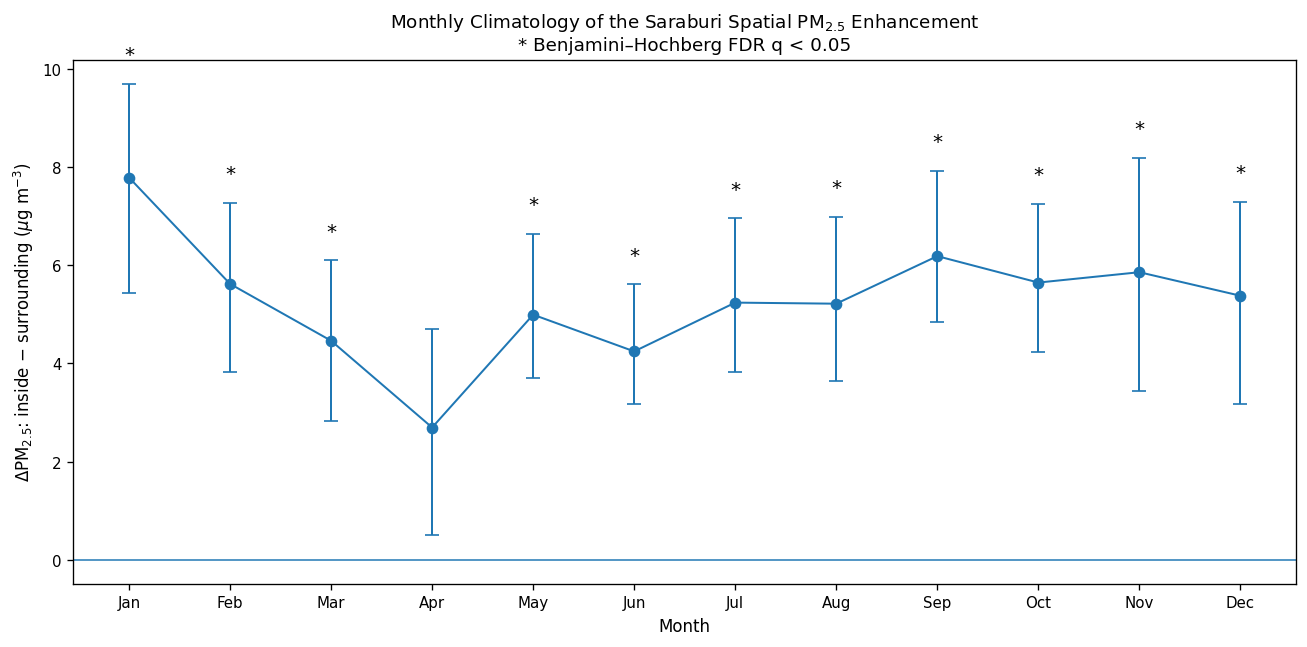

Saved: /content/pm25_saraburi_10yr_outputs/Fig14_monthly_spatial_contrast_FDR.png

✅ Cell 45 completed successfully.

MONTH-SPECIFIC THEIL–SEN TRENDS
     series  month month_name  n_years  sen_slope_ug_m3_per_year  sen_ci95_low  sen_ci95_high  kendall_tau  kendall_p  FDR_q  FDR_significant_0_05
     Inside      1        Jan        6                   -0.7584       -7.4129         3.8694      -0.0667     1.0000 1.0000                 False
     Inside      2        Feb        7                   -0.0286       -2.2697         2.2093      -0.0476     1.0000 1.0000                 False
     Inside      3        Mar        7                    0.2382       -2.2581         2.6637       0.3333     0.3813 0.9152                 False
     Inside      4        Apr        7                   -0.2250       -5.3167         3.4833      -0.0476     1.0000 1.0000                 False
     Inside      5        May        7                   -0.1032       -2.1887         2.0536      -0.0476     1.00

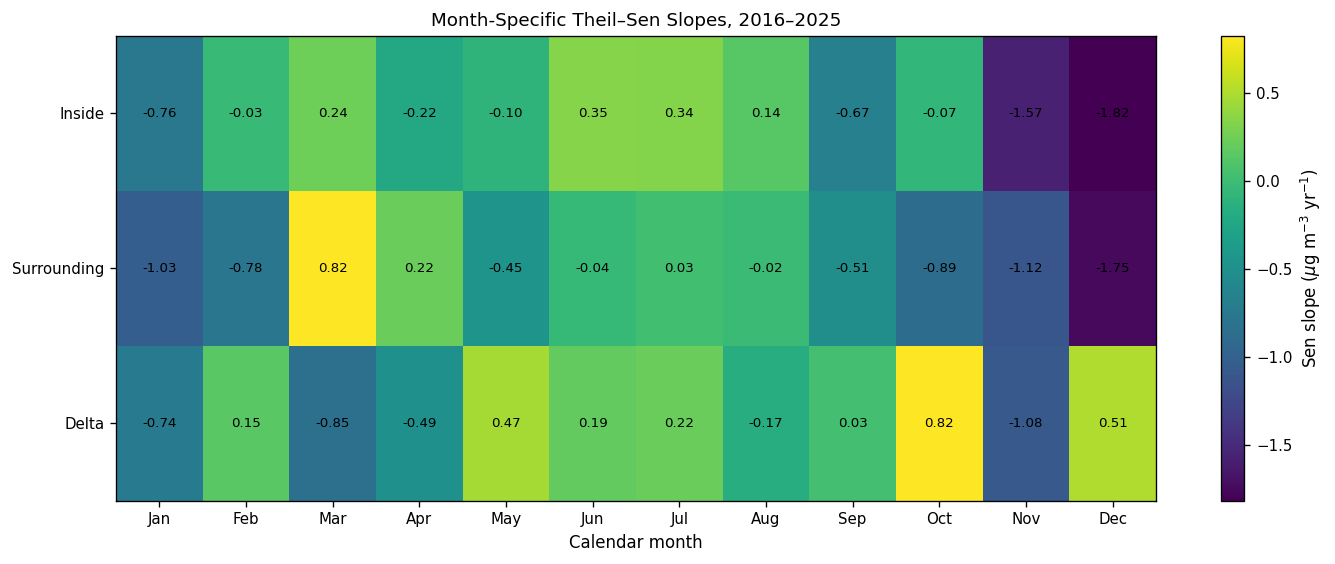

Saved: /content/pm25_saraburi_10yr_outputs/Fig15_month_specific_Sen_slopes.png

✅ Cell 46 completed successfully.

HAC / NEWEY–WEST ROBUSTNESS MODELS
                                 model       term  estimate  std_error_HAC  z_or_t  p_value_HAC  ci95_low  ci95_high
         Delta ~ time + Dry + time×Dry      const    5.2344         0.5708  9.1708       0.0000    4.1157     6.3530
         Delta ~ time + Dry + time×Dry     time_c    0.2483         0.1438  1.7272       0.0841   -0.0335     0.5301
         Delta ~ time + Dry + time×Dry        dry   -0.0430         0.5873 -0.0733       0.9416   -1.1942     1.1081
         Delta ~ time + Dry + time×Dry time_x_dry   -0.6326         0.2504 -2.5265       0.0115   -1.1233    -0.1418
(Delta_weekday - Delta_weekend) ~ time      const    0.4400         0.1879  2.3418       0.0192    0.0717     0.8082
(Delta_weekday - Delta_weekend) ~ time     time_c    0.0777         0.0843  0.9221       0.3565   -0.0875     0.2429

KEY TERMS
Season × time intera

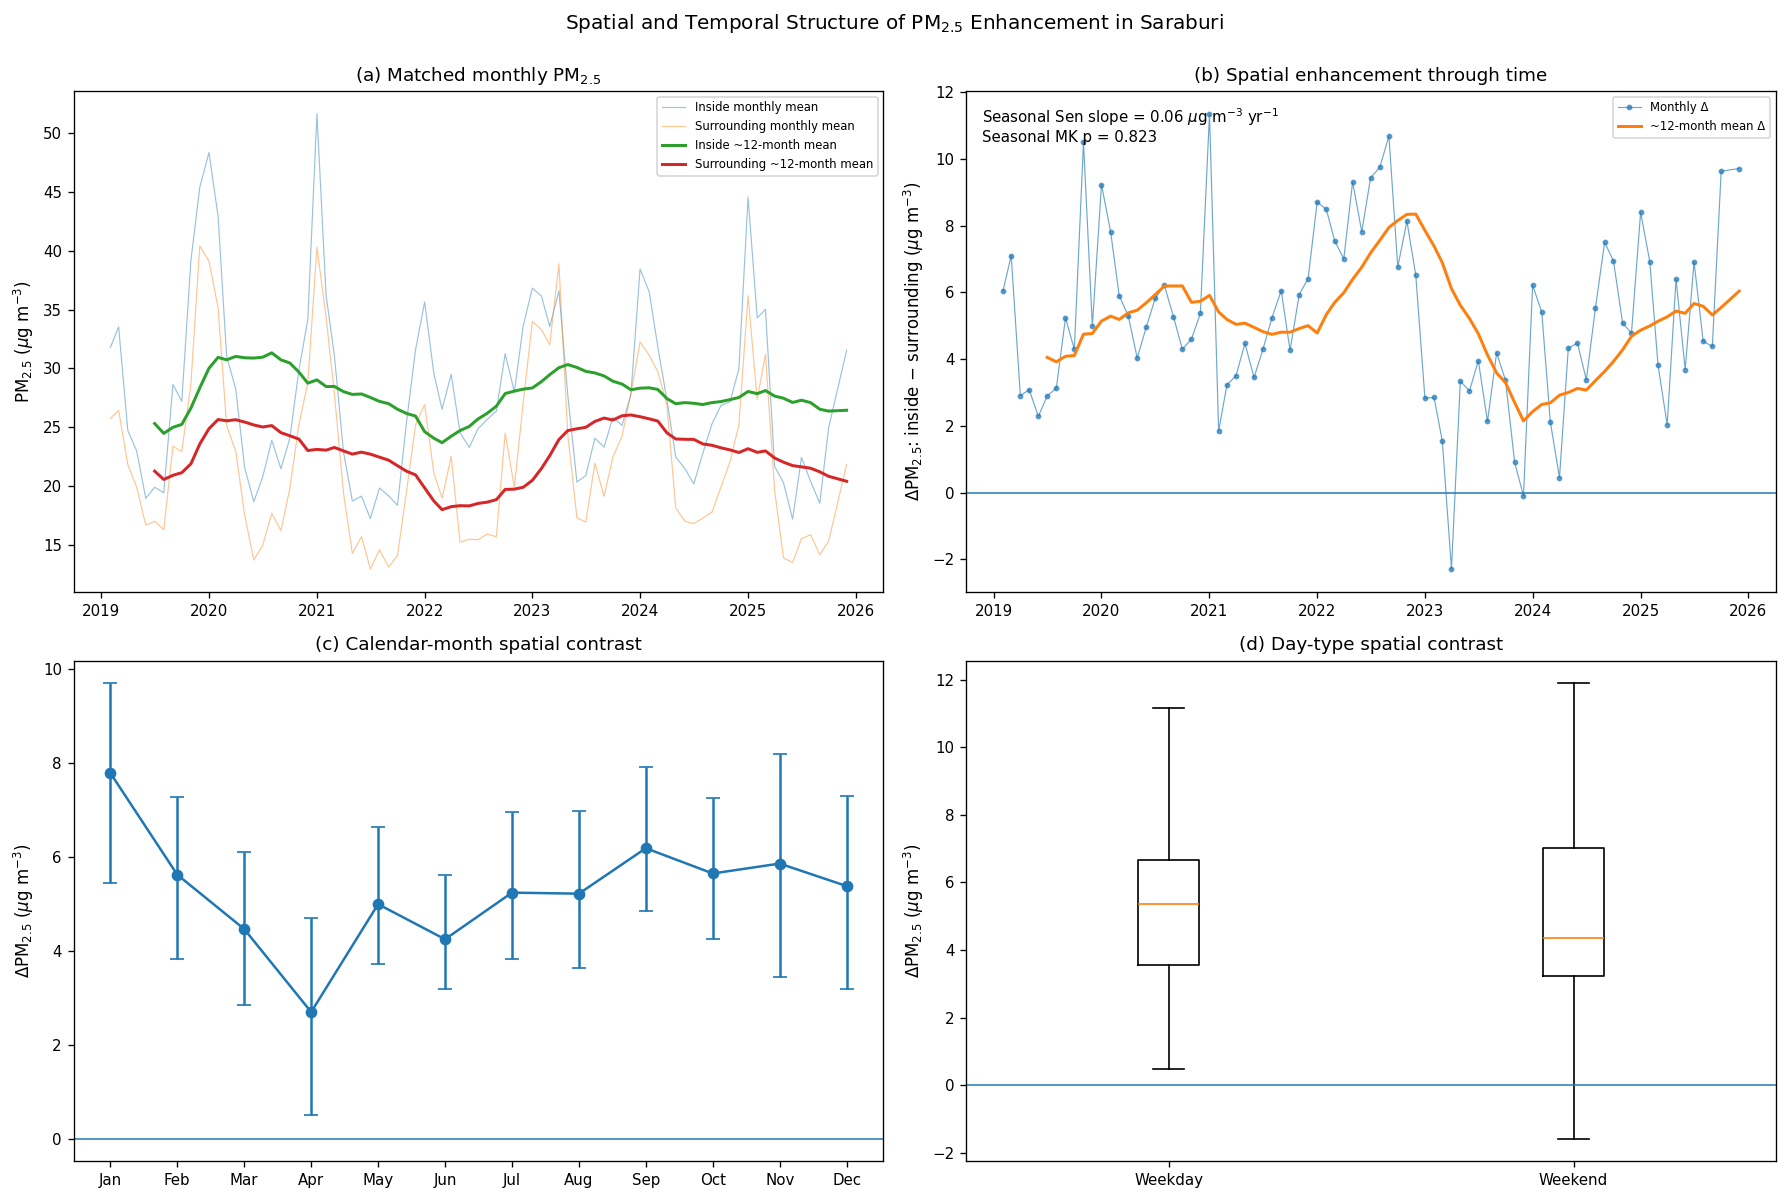

Saved: /content/pm25_saraburi_10yr_outputs/Fig16_spatial_temporal_summary.png

Files created by Cells 40–49:
   35_weekday_weekend_matched_months.csv
   36_weekday_weekend_spatial_statistics.csv
   37_weekday_weekend_interaction_months.csv
   38_weekday_weekend_interaction_test.csv
   39_spatial_inside_outside_delta_trends.csv
   40_dry_wet_spatial_trends.csv
   41_dry_wet_delta_slope_interaction.csv
   42_weekday_weekend_spatial_trends.csv
   43_weekday_weekend_delta_slope_interaction.csv
   44_monthly_spatial_contrast_FDR.csv
   45_month_specific_Theil_Sen_FDR.csv
   46_HAC_interaction_models.csv
   47_fixed_station_pair_trend_sensitivity.csv
   48_consolidated_spatial_temporal_statistics.csv
   Fig14_monthly_spatial_contrast_FDR.png
   Fig15_month_specific_Sen_slopes.png
   Fig16_spatial_temporal_summary.png

✅ Cell 49 completed successfully.


In [ ]:
# =====================================================================
# CELL 40 — BUILD WEEKDAY / WEEKEND MATCHED-MONTH DATASET
#
# IMPORTANT:
# Completeness is evaluated against the EXPECTED NUMBER OF THAT DAY TYPE
# in each month:
#   weekday coverage = valid matched weekdays / expected weekdays
#   weekend coverage = valid matched weekend days / expected weekend days
#
# Monthly inside/outside means are calculated from the SAME matched dates.
# =====================================================================

DAYTYPE_MATCH_FRAC = 0.75
N_BOOT_DAYTYPE = 5000

required_for_cell40 = [
    "spatial_daily",
    "matched_month_pass",
    "paired_wilcoxon_safe",
    "seasonal_mk_sen"
]

for obj_name in required_for_cell40:
    if obj_name not in globals():
        raise RuntimeError(
            f"Required object '{obj_name}' is missing. "
            "Run Cells 33–39 first."
        )

daytype_daily = spatial_daily.copy()

daytype_daily["dow"] = (
    daytype_daily["date"]
    .dt.dayofweek
)

daytype_daily["day_type"] = np.where(
    daytype_daily["dow"] >= 5,
    "Weekend",
    "Weekday"
)

daytype_month_rows = []

for period, g_month in daytype_daily.groupby(
    "year_month",
    sort=True
):
    for day_type in [
        "Weekday",
        "Weekend"
    ]:

        g = g_month[
            g_month[
                "day_type"
            ] == day_type
        ].copy()

        expected_days = len(g)

        inside_valid = int(
            g[
                "PM25_inside_group"
            ]
            .notna()
            .sum()
        )

        outside_valid = int(
            g[
                "PM25_outside_group"
            ]
            .notna()
            .sum()
        )

        matched = g[
            g[
                "matched_day"
            ]
        ].copy()

        matched_days = len(
            matched
        )

        inside_fraction = (
            inside_valid
            /
            expected_days
            if expected_days > 0
            else np.nan
        )

        outside_fraction = (
            outside_valid
            /
            expected_days
            if expected_days > 0
            else np.nan
        )

        matched_fraction = (
            matched_days
            /
            expected_days
            if expected_days > 0
            else np.nan
        )

        daytype_pass = (
            expected_days > 0
            and
            inside_fraction >= DAYTYPE_MATCH_FRAC
            and
            outside_fraction >= DAYTYPE_MATCH_FRAC
            and
            matched_fraction >= DAYTYPE_MATCH_FRAC
        )

        if (
            daytype_pass
            and
            matched_days > 0
        ):

            inside_mean = (
                matched[
                    "PM25_inside_group"
                ]
                .mean()
            )

            outside_mean = (
                matched[
                    "PM25_outside_group"
                ]
                .mean()
            )

            delta = (
                inside_mean
                -
                outside_mean
            )

            relative_delta = (
                100.0
                *
                delta
                /
                outside_mean
                if outside_mean != 0
                else np.nan
            )

        else:
            inside_mean = np.nan
            outside_mean = np.nan
            delta = np.nan
            relative_delta = np.nan

        month = period.month
        year = period.year

        season = (
            "Wet"
            if month in WET_MONTHS
            else "Dry"
            if month in DRY_MONTHS
            else "Other"
        )

        daytype_month_rows.append({
            "year_month": period,
            "year": year,
            "month": month,
            "season": season,
            "day_type": day_type,
            "expected_days": expected_days,
            "inside_valid_days": inside_valid,
            "outside_valid_days": outside_valid,
            "matched_days": matched_days,
            "inside_fraction": inside_fraction,
            "outside_fraction": outside_fraction,
            "matched_fraction": matched_fraction,
            "daytype_pass": daytype_pass,
            "inside_mean_pm25": inside_mean,
            "outside_mean_pm25": outside_mean,
            "delta_inside_minus_outside": delta,
            "relative_delta_pct": relative_delta
        })

daytype_month = pd.DataFrame(
    daytype_month_rows
)

daytype_month.to_csv(
    os.path.join(
        OUT_DIR,
        "35_weekday_weekend_matched_months.csv"
    ),
    index=False
)

daytype_month_pass = daytype_month[
    daytype_month[
        "daytype_pass"
    ]
].copy()

print("\nWEEKDAY/WEEKEND MATCHED-MONTH QA")
print("=" * 110)

for day_type in [
    "Weekday",
    "Weekend"
]:
    d = daytype_month_pass[
        daytype_month_pass[
            "day_type"
        ] == day_type
    ]

    print(
        f"{day_type:8s}: "
        f"{len(d):3d} passing months; "
        f"mean matched coverage = "
        f"{100*d['matched_fraction'].mean():.1f}%"
        if len(d) > 0
        else f"{day_type:8s}: 0 passing months"
    )

print("\n✅ Cell 40 completed successfully.")


# ================================================================================
# COPY AS CELL 41
# ================================================================================
# =====================================================================
# CELL 41 — WEEKDAY vs WEEKEND SPATIAL CONTRAST
#
# Questions:
# 1) Is inside Saraburi higher than surrounding areas on weekdays?
# 2) Is inside Saraburi higher on weekends?
# 3) Does the spatial contrast differ between weekday and weekend?
#
# Main tests:
#   - paired Wilcoxon inside vs surrounding within each day type
#   - paired Wilcoxon Δweekday vs Δweekend within the SAME year-month
#   - year-block bootstrap CI for Δweekday − Δweekend
# =====================================================================

def generic_year_block_bootstrap_mean(
    df,
    value_col,
    year_col="year",
    n_boot=5000,
    seed=2026
):
    d = df.dropna(
        subset=[
            value_col,
            year_col
        ]
    ).copy()

    years = sorted(
        d[
            year_col
        ]
        .astype(int)
        .unique()
        .tolist()
    )

    if len(years) < 2:
        return {
            "mean_estimate": d[
                value_col
            ].mean(),
            "ci95_low": np.nan,
            "ci95_high": np.nan,
            "n_boot_valid": 0
        }

    by_year = {
        year: d.loc[
            d[
                year_col
            ].astype(int) == year,
            value_col
        ]
        .dropna()
        .to_numpy()
        for year in years
    }

    rng = np.random.default_rng(
        seed
    )

    boot = []

    for _ in range(
        n_boot
    ):
        sampled_years = rng.choice(
            years,
            size=len(years),
            replace=True
        )

        vals = []

        for year in sampled_years:
            vals.extend(
                by_year[
                    int(year)
                ].tolist()
            )

        if vals:
            boot.append(
                np.mean(vals)
            )

    if len(boot) > 100:
        ci_low, ci_high = np.percentile(
            boot,
            [2.5, 97.5]
        )
    else:
        ci_low = np.nan
        ci_high = np.nan

    return {
        "mean_estimate": d[
            value_col
        ].mean(),
        "ci95_low": ci_low,
        "ci95_high": ci_high,
        "n_boot_valid": len(boot)
    }


daytype_spatial_rows = []

for day_type in [
    "Weekday",
    "Weekend"
]:

    d = daytype_month_pass[
        daytype_month_pass[
            "day_type"
        ] == day_type
    ].dropna(
        subset=[
            "inside_mean_pm25",
            "outside_mean_pm25"
        ]
    ).copy()

    W, p = paired_wilcoxon_safe(
        d[
            "inside_mean_pm25"
        ],
        d[
            "outside_mean_pm25"
        ]
    )

    boot = generic_year_block_bootstrap_mean(
        d,
        "delta_inside_minus_outside",
        n_boot=N_BOOT_DAYTYPE,
        seed=(
            4101
            if day_type == "Weekday"
            else 4102
        )
    )

    daytype_spatial_rows.append({
        "day_type": day_type,
        "n_matched_months": len(d),
        "inside_mean_pm25": d[
            "inside_mean_pm25"
        ].mean(),
        "outside_mean_pm25": d[
            "outside_mean_pm25"
        ].mean(),
        "mean_delta_inside_minus_outside": d[
            "delta_inside_minus_outside"
        ].mean(),
        "median_delta_inside_minus_outside": d[
            "delta_inside_minus_outside"
        ].median(),
        "mean_relative_delta_pct": d[
            "relative_delta_pct"
        ].mean(),
        "wilcoxon_W": W,
        "wilcoxon_p": p,
        "mean_delta_ci95_low": boot[
            "ci95_low"
        ],
        "mean_delta_ci95_high": boot[
            "ci95_high"
        ],
        "n_boot_valid": boot[
            "n_boot_valid"
        ]
    })

daytype_spatial_table = pd.DataFrame(
    daytype_spatial_rows
)

# ---------------------------------------------------------------------
# Pair weekday and weekend within the exact same year-month.
# ---------------------------------------------------------------------
weekday_m = daytype_month_pass[
    daytype_month_pass[
        "day_type"
    ] == "Weekday"
][
    [
        "year_month",
        "year",
        "month",
        "season",
        "delta_inside_minus_outside"
    ]
].copy()

weekday_m = weekday_m.rename(
    columns={
        "delta_inside_minus_outside":
        "delta_weekday"
    }
)

weekend_m = daytype_month_pass[
    daytype_month_pass[
        "day_type"
    ] == "Weekend"
][
    [
        "year_month",
        "delta_inside_minus_outside"
    ]
].copy()

weekend_m = weekend_m.rename(
    columns={
        "delta_inside_minus_outside":
        "delta_weekend"
    }
)

daytype_interaction_month = weekday_m.merge(
    weekend_m,
    on="year_month",
    how="inner",
    validate="one_to_one"
)

daytype_interaction_month[
    "weekday_minus_weekend_delta"
] = (
    daytype_interaction_month[
        "delta_weekday"
    ]
    -
    daytype_interaction_month[
        "delta_weekend"
    ]
)

W_int, p_int = paired_wilcoxon_safe(
    daytype_interaction_month[
        "delta_weekday"
    ],
    daytype_interaction_month[
        "delta_weekend"
    ]
)

boot_int = generic_year_block_bootstrap_mean(
    daytype_interaction_month,
    "weekday_minus_weekend_delta",
    n_boot=N_BOOT_DAYTYPE,
    seed=4110
)

daytype_interaction_table = pd.DataFrame([
    {
        "n_paired_months": len(
            daytype_interaction_month
        ),
        "mean_weekday_delta": daytype_interaction_month[
            "delta_weekday"
        ].mean(),
        "mean_weekend_delta": daytype_interaction_month[
            "delta_weekend"
        ].mean(),
        "mean_weekday_minus_weekend_delta": daytype_interaction_month[
            "weekday_minus_weekend_delta"
        ].mean(),
        "median_weekday_minus_weekend_delta": daytype_interaction_month[
            "weekday_minus_weekend_delta"
        ].median(),
        "interaction_ci95_low": boot_int[
            "ci95_low"
        ],
        "interaction_ci95_high": boot_int[
            "ci95_high"
        ],
        "wilcoxon_W": W_int,
        "wilcoxon_p": p_int,
        "n_boot_valid": boot_int[
            "n_boot_valid"
        ]
    }
])

daytype_spatial_table.to_csv(
    os.path.join(
        OUT_DIR,
        "36_weekday_weekend_spatial_statistics.csv"
    ),
    index=False
)

daytype_interaction_month.to_csv(
    os.path.join(
        OUT_DIR,
        "37_weekday_weekend_interaction_months.csv"
    ),
    index=False
)

daytype_interaction_table.to_csv(
    os.path.join(
        OUT_DIR,
        "38_weekday_weekend_interaction_test.csv"
    ),
    index=False
)

print("\nWEEKDAY/WEEKEND SPATIAL CONTRAST")
print("=" * 130)

print(
    daytype_spatial_table
    .round(4)
    .to_string(index=False)
)

print("\nWEEKDAY × WEEKEND SPATIAL-INTERACTION TEST")
print("=" * 120)

print(
    daytype_interaction_table
    .round(4)
    .to_string(index=False)
)

print(
    "\nPositive weekday-minus-weekend interaction = "
    "the Saraburi spatial enhancement is larger on weekdays."
)

print("\n✅ Cell 41 completed successfully.")


# ================================================================================
# COPY AS CELL 42
# ================================================================================
# =====================================================================
# CELL 42 — SEASONAL TREND: INSIDE, SURROUNDING, AND SPATIAL DIFFERENCE
#
# Principal temporal question:
# Is the Saraburi spatial enhancement widening or narrowing over time?
#
# Series:
#   Inside
#   Surrounding
#   Δ = Inside − Surrounding
#
# Method:
#   Seasonal Mann–Kendall + Seasonal Sen slope
# =====================================================================

spatial_trend_specs = [
    (
        "Inside Saraburi",
        "inside_mean_pm25"
    ),
    (
        "Surrounding network",
        "outside_mean_pm25"
    ),
    (
        "Inside minus surrounding",
        "delta_inside_minus_outside"
    )
]

spatial_trend_rows = []

for label, value_col in spatial_trend_specs:

    tmp = matched_month_pass[
        [
            "year",
            "month",
            value_col
        ]
    ].copy()

    tmp = tmp.rename(
        columns={
            value_col:
            "mean_pm25"
        }
    )

    result = seasonal_mk_sen(
        tmp,
        n_boot=5000,
        seed=(
            4201
            +
            len(
                spatial_trend_rows
            )
        )
    )

    spatial_trend_rows.append({
        "series": label,
        "n_monthly_observations": result[
            "n_monthly_observations"
        ],
        "seasonal_tau": result[
            "seasonal_tau"
        ],
        "seasonal_MK_p": result[
            "seasonal_MK_p"
        ],
        "seasonal_sen_slope_ug_m3_per_year": result[
            "seasonal_sen_slope_ug_m3_per_year"
        ],
        "seasonal_sen_ci95_low": result[
            "seasonal_sen_ci95_low"
        ],
        "seasonal_sen_ci95_high": result[
            "seasonal_sen_ci95_high"
        ]
    })

spatial_trend_table = pd.DataFrame(
    spatial_trend_rows
)

spatial_trend_table[
    "significant_0_05"
] = (
    spatial_trend_table[
        "seasonal_MK_p"
    ]
    < 0.05
)

spatial_trend_table.to_csv(
    os.path.join(
        OUT_DIR,
        "39_spatial_inside_outside_delta_trends.csv"
    ),
    index=False
)

print("\nSEASONAL TREND — INSIDE, SURROUNDING, AND ΔPM2.5")
print("=" * 130)

print(
    spatial_trend_table
    .round(4)
    .to_string(index=False)
)

delta_trend_row = spatial_trend_table[
    spatial_trend_table[
        "series"
    ] == "Inside minus surrounding"
]

if len(
    delta_trend_row
) == 1:

    r = delta_trend_row.iloc[0]

    if r[
        "seasonal_sen_slope_ug_m3_per_year"
    ] > 0:
        direction_text = (
            "widening through time"
        )
    elif r[
        "seasonal_sen_slope_ug_m3_per_year"
    ] < 0:
        direction_text = (
            "narrowing through time"
        )
    else:
        direction_text = (
            "showing no monotonic change"
        )

    print(
        "\nSpatial-gap interpretation:",
        f"the inside-minus-surrounding contrast is {direction_text}; "
        f"Sen slope = "
        f"{r['seasonal_sen_slope_ug_m3_per_year']:.3f} "
        f"µg m⁻³ yr⁻¹."
    )

print("\n✅ Cell 42 completed successfully.")


# ================================================================================
# COPY AS CELL 43
# ================================================================================
# =====================================================================
# CELL 43 — DRY vs WET TEMPORAL TRENDS
#
# Seasonal MK/Sen is calculated separately for:
#   Dry months (Nov–Apr)
#   Wet months (May–Oct)
#
# for:
#   Inside
#   Surrounding
#   Δ = Inside − Surrounding
#
# A calendar-month-block bootstrap estimates:
#   Δ slope_dry − Δ slope_wet
# =====================================================================

def pairwise_slopes_by_calendar_month(
    df,
    value_col
):
    slopes = {}

    for month in sorted(
        df[
            "month"
        ]
        .dropna()
        .unique()
        .tolist()
    ):

        m = df[
            df[
                "month"
            ] == month
        ].dropna(
            subset=[
                value_col
            ]
        ).sort_values(
            "year"
        )

        years = m[
            "year"
        ].to_numpy(
            dtype=float
        )

        vals = m[
            value_col
        ].to_numpy(
            dtype=float
        )

        month_slopes = []

        for i in range(
            len(vals) - 1
        ):
            for j in range(
                i + 1,
                len(vals)
            ):
                dt = (
                    years[j]
                    -
                    years[i]
                )

                if dt != 0:
                    month_slopes.append(
                        (
                            vals[j]
                            -
                            vals[i]
                        )
                        /
                        dt
                    )

        slopes[
            int(month)
        ] = month_slopes

    return slopes


def bootstrap_season_slope_difference(
    df,
    value_col,
    n_boot=5000,
    seed=4300
):
    dry_df = df[
        df[
            "season"
        ] == "Dry"
    ].copy()

    wet_df = df[
        df[
            "season"
        ] == "Wet"
    ].copy()

    dry_slopes = pairwise_slopes_by_calendar_month(
        dry_df,
        value_col
    )

    wet_slopes = pairwise_slopes_by_calendar_month(
        wet_df,
        value_col
    )

    dry_months = [
        m for m, vals in dry_slopes.items()
        if len(vals) > 0
    ]

    wet_months = [
        m for m, vals in wet_slopes.items()
        if len(vals) > 0
    ]

    all_dry = []

    for m in dry_months:
        all_dry.extend(
            dry_slopes[m]
        )

    all_wet = []

    for m in wet_months:
        all_wet.extend(
            wet_slopes[m]
        )

    observed_dry = (
        np.median(
            all_dry
        )
        if all_dry
        else np.nan
    )

    observed_wet = (
        np.median(
            all_wet
        )
        if all_wet
        else np.nan
    )

    observed_difference = (
        observed_dry
        -
        observed_wet
        if (
            np.isfinite(
                observed_dry
            )
            and
            np.isfinite(
                observed_wet
            )
        )
        else np.nan
    )

    rng = np.random.default_rng(
        seed
    )

    boot_diff = []

    if (
        dry_months
        and
        wet_months
    ):

        for _ in range(
            n_boot
        ):

            sampled_dry = rng.choice(
                dry_months,
                size=len(
                    dry_months
                ),
                replace=True
            )

            sampled_wet = rng.choice(
                wet_months,
                size=len(
                    wet_months
                ),
                replace=True
            )

            dry_vals = []

            for m in sampled_dry:
                dry_vals.extend(
                    dry_slopes[
                        int(m)
                    ]
                )

            wet_vals = []

            for m in sampled_wet:
                wet_vals.extend(
                    wet_slopes[
                        int(m)
                    ]
                )

            if (
                dry_vals
                and
                wet_vals
            ):
                boot_diff.append(
                    np.median(
                        dry_vals
                    )
                    -
                    np.median(
                        wet_vals
                    )
                )

    if len(
        boot_diff
    ) > 100:

        ci_low, ci_high = np.percentile(
            boot_diff,
            [
                2.5,
                97.5
            ]
        )

    else:
        ci_low = np.nan
        ci_high = np.nan

    return {
        "dry_sen_slope": observed_dry,
        "wet_sen_slope": observed_wet,
        "dry_minus_wet_slope_difference": observed_difference,
        "difference_ci95_low": ci_low,
        "difference_ci95_high": ci_high,
        "difference_significant_95CI": bool(
            np.isfinite(
                ci_low
            )
            and
            np.isfinite(
                ci_high
            )
            and
            (
                ci_low > 0
                or
                ci_high < 0
            )
        ),
        "n_boot_valid": len(
            boot_diff
        )
    }


season_trend_rows = []

for season in [
    "Dry",
    "Wet"
]:

    season_df = matched_month_pass[
        matched_month_pass[
            "season"
        ] == season
    ].copy()

    for label, value_col in spatial_trend_specs:

        tmp = season_df[
            [
                "year",
                "month",
                value_col
            ]
        ].copy()

        tmp = tmp.rename(
            columns={
                value_col:
                "mean_pm25"
            }
        )

        result = seasonal_mk_sen(
            tmp,
            n_boot=4000,
            seed=(
                4310
                +
                len(
                    season_trend_rows
                )
            )
        )

        season_trend_rows.append({
            "season": season,
            "series": label,
            "n_monthly_observations": result[
                "n_monthly_observations"
            ],
            "seasonal_tau": result[
                "seasonal_tau"
            ],
            "seasonal_MK_p": result[
                "seasonal_MK_p"
            ],
            "seasonal_sen_slope_ug_m3_per_year": result[
                "seasonal_sen_slope_ug_m3_per_year"
            ],
            "seasonal_sen_ci95_low": result[
                "seasonal_sen_ci95_low"
            ],
            "seasonal_sen_ci95_high": result[
                "seasonal_sen_ci95_high"
            ]
        })

season_trend_table = pd.DataFrame(
    season_trend_rows
)

season_trend_table.to_csv(
    os.path.join(
        OUT_DIR,
        "40_dry_wet_spatial_trends.csv"
    ),
    index=False
)

delta_season_slope_interaction = (
    bootstrap_season_slope_difference(
        matched_month_pass,
        "delta_inside_minus_outside",
        n_boot=5000,
        seed=4399
    )
)

delta_season_slope_interaction_table = (
    pd.DataFrame([
        delta_season_slope_interaction
    ])
)

delta_season_slope_interaction_table.to_csv(
    os.path.join(
        OUT_DIR,
        "41_dry_wet_delta_slope_interaction.csv"
    ),
    index=False
)

print("\nDRY/WET SEASON-SPECIFIC TRENDS")
print("=" * 140)

print(
    season_trend_table
    .round(4)
    .to_string(index=False)
)

print("\nDRY vs WET DIFFERENCE IN ΔPM2.5 TREND")
print("=" * 120)

print(
    delta_season_slope_interaction_table
    .round(4)
    .to_string(index=False)
)

print(
    "\nA 95% bootstrap CI excluding zero indicates evidence that "
    "the dry- and wet-season spatial-gap trends differ."
)

print("\n✅ Cell 43 completed successfully.")


# ================================================================================
# COPY AS CELL 44
# ================================================================================
# =====================================================================
# CELL 44 — WEEKDAY vs WEEKEND TEMPORAL TRENDS
#
# For each day type:
#   Inside trend
#   Surrounding trend
#   Δ inside−surrounding trend
#
# Then compare:
#   Δ slope_weekday − Δ slope_weekend
# using a PAIRED calendar-month-block bootstrap.
# =====================================================================

daytype_trend_rows = []

for day_type in [
    "Weekday",
    "Weekend"
]:

    d = daytype_month_pass[
        daytype_month_pass[
            "day_type"
        ] == day_type
    ].copy()

    for label, value_col in spatial_trend_specs:

        tmp = d[
            [
                "year",
                "month",
                value_col
            ]
        ].copy()

        tmp = tmp.rename(
            columns={
                value_col:
                "mean_pm25"
            }
        )

        result = seasonal_mk_sen(
            tmp,
            n_boot=4000,
            seed=(
                4400
                +
                len(
                    daytype_trend_rows
                )
            )
        )

        daytype_trend_rows.append({
            "day_type": day_type,
            "series": label,
            "n_monthly_observations": result[
                "n_monthly_observations"
            ],
            "seasonal_tau": result[
                "seasonal_tau"
            ],
            "seasonal_MK_p": result[
                "seasonal_MK_p"
            ],
            "seasonal_sen_slope_ug_m3_per_year": result[
                "seasonal_sen_slope_ug_m3_per_year"
            ],
            "seasonal_sen_ci95_low": result[
                "seasonal_sen_ci95_low"
            ],
            "seasonal_sen_ci95_high": result[
                "seasonal_sen_ci95_high"
            ]
        })

daytype_trend_table = pd.DataFrame(
    daytype_trend_rows
)

# ---------------------------------------------------------------------
# Paired calendar-month-block bootstrap for weekday vs weekend Δ slopes
# ---------------------------------------------------------------------
weekday_df = daytype_month_pass[
    daytype_month_pass[
        "day_type"
    ] == "Weekday"
].copy()

weekend_df = daytype_month_pass[
    daytype_month_pass[
        "day_type"
    ] == "Weekend"
].copy()

weekday_slopes = pairwise_slopes_by_calendar_month(
    weekday_df,
    "delta_inside_minus_outside"
)

weekend_slopes = pairwise_slopes_by_calendar_month(
    weekend_df,
    "delta_inside_minus_outside"
)

common_months = sorted(
    set(
        m for m, v in weekday_slopes.items()
        if len(v) > 0
    )
    &
    set(
        m for m, v in weekend_slopes.items()
        if len(v) > 0
    )
)

weekday_all = []

for m in common_months:
    weekday_all.extend(
        weekday_slopes[m]
    )

weekend_all = []

for m in common_months:
    weekend_all.extend(
        weekend_slopes[m]
    )

weekday_slope = (
    np.median(
        weekday_all
    )
    if weekday_all
    else np.nan
)

weekend_slope = (
    np.median(
        weekend_all
    )
    if weekend_all
    else np.nan
)

observed_daytype_slope_difference = (
    weekday_slope
    -
    weekend_slope
    if (
        np.isfinite(
            weekday_slope
        )
        and
        np.isfinite(
            weekend_slope
        )
    )
    else np.nan
)

rng = np.random.default_rng(
    4499
)

boot_daytype_slope_diff = []

if common_months:

    for _ in range(
        5000
    ):

        sampled_months = rng.choice(
            common_months,
            size=len(
                common_months
            ),
            replace=True
        )

        wday_vals = []
        wend_vals = []

        for m in sampled_months:
            m = int(m)

            wday_vals.extend(
                weekday_slopes[m]
            )

            wend_vals.extend(
                weekend_slopes[m]
            )

        if (
            wday_vals
            and
            wend_vals
        ):
            boot_daytype_slope_diff.append(
                np.median(
                    wday_vals
                )
                -
                np.median(
                    wend_vals
                )
            )

if len(
    boot_daytype_slope_diff
) > 100:

    daytype_slope_ci_low, daytype_slope_ci_high = np.percentile(
        boot_daytype_slope_diff,
        [
            2.5,
            97.5
        ]
    )

else:
    daytype_slope_ci_low = np.nan
    daytype_slope_ci_high = np.nan

daytype_slope_interaction_table = pd.DataFrame([
    {
        "weekday_delta_sen_slope": weekday_slope,
        "weekend_delta_sen_slope": weekend_slope,
        "weekday_minus_weekend_slope_difference":
        observed_daytype_slope_difference,
        "difference_ci95_low":
        daytype_slope_ci_low,
        "difference_ci95_high":
        daytype_slope_ci_high,
        "difference_significant_95CI": bool(
            np.isfinite(
                daytype_slope_ci_low
            )
            and
            np.isfinite(
                daytype_slope_ci_high
            )
            and
            (
                daytype_slope_ci_low > 0
                or
                daytype_slope_ci_high < 0
            )
        ),
        "n_boot_valid": len(
            boot_daytype_slope_diff
        )
    }
])

daytype_trend_table.to_csv(
    os.path.join(
        OUT_DIR,
        "42_weekday_weekend_spatial_trends.csv"
    ),
    index=False
)

daytype_slope_interaction_table.to_csv(
    os.path.join(
        OUT_DIR,
        "43_weekday_weekend_delta_slope_interaction.csv"
    ),
    index=False
)

print("\nWEEKDAY/WEEKEND TEMPORAL TRENDS")
print("=" * 140)

print(
    daytype_trend_table
    .round(4)
    .to_string(index=False)
)

print("\nWEEKDAY vs WEEKEND DIFFERENCE IN ΔPM2.5 TREND")
print("=" * 120)

print(
    daytype_slope_interaction_table
    .round(4)
    .to_string(index=False)
)

print("\n✅ Cell 44 completed successfully.")


# ================================================================================
# COPY AS CELL 45
# ================================================================================
# =====================================================================
# CELL 45 — JAN–DEC CLIMATOLOGICAL SPATIAL CONTRAST + FDR
#
# For each calendar month:
#   Inside vs surrounding paired comparison across available years
#   Mean / median ΔPM2.5
#   Bootstrap 95% CI for mean Δ
#   Paired Wilcoxon p
#   Benjamini–Hochberg FDR q-value across 12 months
#
# This answers:
# "In which calendar months is the Saraburi spatial enhancement strongest?"
# =====================================================================

def benjamini_hochberg(
    p_values
):
    p = np.asarray(
        p_values,
        dtype=float
    )

    out = np.full(
        len(p),
        np.nan
    )

    valid_idx = np.where(
        np.isfinite(
            p
        )
    )[0]

    if len(
        valid_idx
    ) == 0:
        return out

    valid_p = p[
        valid_idx
    ]

    order = np.argsort(
        valid_p
    )

    ranked_p = valid_p[
        order
    ]

    m = len(
        ranked_p
    )

    adjusted = (
        ranked_p
        *
        m
        /
        np.arange(
            1,
            m + 1
        )
    )

    adjusted = np.minimum.accumulate(
        adjusted[::-1]
    )[::-1]

    adjusted = np.clip(
        adjusted,
        0,
        1
    )

    unsorted = np.empty_like(
        adjusted
    )

    unsorted[
        order
    ] = adjusted

    out[
        valid_idx
    ] = unsorted

    return out


def bootstrap_mean_ci_simple(
    values,
    n_boot=5000,
    seed=4500
):
    vals = np.asarray(
        values,
        dtype=float
    )

    vals = vals[
        np.isfinite(
            vals
        )
    ]

    if len(vals) < 2:
        return (
            np.nan,
            np.nan
        )

    rng = np.random.default_rng(
        seed
    )

    boot = []

    for _ in range(
        n_boot
    ):
        sample = rng.choice(
            vals,
            size=len(vals),
            replace=True
        )

        boot.append(
            np.mean(
                sample
            )
        )

    return tuple(
        np.percentile(
            boot,
            [
                2.5,
                97.5
            ]
        )
    )


monthly_spatial_rows = []

for month in range(
    1,
    13
):

    d = matched_month_pass[
        matched_month_pass[
            "month"
        ] == month
    ].dropna(
        subset=[
            "inside_mean_pm25",
            "outside_mean_pm25"
        ]
    ).copy()

    if len(d) >= 2:

        W, p = paired_wilcoxon_safe(
            d[
                "inside_mean_pm25"
            ],
            d[
                "outside_mean_pm25"
            ]
        )

        ci_low, ci_high = bootstrap_mean_ci_simple(
            d[
                "delta_inside_minus_outside"
            ],
            n_boot=5000,
            seed=4500 + month
        )

    else:
        W = np.nan
        p = np.nan
        ci_low = np.nan
        ci_high = np.nan

    monthly_spatial_rows.append({
        "month": month,
        "month_name": month_labels[
            month - 1
        ],
        "n_paired_years": len(d),
        "inside_mean_pm25": d[
            "inside_mean_pm25"
        ].mean(),
        "outside_mean_pm25": d[
            "outside_mean_pm25"
        ].mean(),
        "mean_delta_inside_minus_outside": d[
            "delta_inside_minus_outside"
        ].mean(),
        "median_delta_inside_minus_outside": d[
            "delta_inside_minus_outside"
        ].median(),
        "mean_relative_delta_pct": d[
            "relative_delta_pct"
        ].mean(),
        "delta_ci95_low": ci_low,
        "delta_ci95_high": ci_high,
        "wilcoxon_W": W,
        "wilcoxon_p": p
    })

monthly_spatial_climatology = pd.DataFrame(
    monthly_spatial_rows
)

monthly_spatial_climatology[
    "FDR_q"
] = benjamini_hochberg(
    monthly_spatial_climatology[
        "wilcoxon_p"
    ].to_numpy()
)

monthly_spatial_climatology[
    "FDR_significant_0_05"
] = (
    monthly_spatial_climatology[
        "FDR_q"
    ] < 0.05
)

monthly_spatial_climatology.to_csv(
    os.path.join(
        OUT_DIR,
        "44_monthly_spatial_contrast_FDR.csv"
    ),
    index=False
)

print("\nJAN–DEC SPATIAL CONTRAST WITH FDR")
print("=" * 145)

print(
    monthly_spatial_climatology
    .round(4)
    .to_string(index=False)
)

# ---------------------------------------------------------------------
# Figure 14 — monthly ΔPM2.5 with 95% CI and FDR significance
# ---------------------------------------------------------------------
fig, ax = plt.subplots(
    figsize=(11, 5.5)
)

x = np.arange(
    1,
    13
)

means = monthly_spatial_climatology[
    "mean_delta_inside_minus_outside"
].to_numpy(
    dtype=float
)

lower = (
    means
    -
    monthly_spatial_climatology[
        "delta_ci95_low"
    ].to_numpy(
        dtype=float
    )
)

upper = (
    monthly_spatial_climatology[
        "delta_ci95_high"
    ].to_numpy(
        dtype=float
    )
    -
    means
)

ax.errorbar(
    x,
    means,
    yerr=np.array(
        [
            lower,
            upper
        ]
    ),
    marker="o",
    capsize=4,
    linewidth=1.2
)

ax.axhline(
    0,
    linewidth=0.9
)

for _, r in monthly_spatial_climatology.iterrows():

    if bool(
        r[
            "FDR_significant_0_05"
        ]
    ):

        ax.text(
            int(
                r[
                    "month"
                ]
            ),
            r[
                "delta_ci95_high"
            ]
            +
            0.4,
            "*",
            ha="center",
            va="bottom",
            fontsize=12
        )

ax.set_xticks(
    x
)

ax.set_xticklabels(
    month_labels
)

ax.set_xlabel(
    "Month"
)

ax.set_ylabel(
    "$\\Delta$PM$_{2.5}$: inside − surrounding "
    "($\\mu$g m$^{-3}$)"
)

ax.set_title(
    "Monthly Climatology of the Saraburi Spatial PM$_{2.5}$ Enhancement\n"
    "* Benjamini–Hochberg FDR q < 0.05"
)

plt.tight_layout()

fig14_path = os.path.join(
    OUT_DIR,
    "Fig14_monthly_spatial_contrast_FDR.png"
)

plt.savefig(
    fig14_path,
    dpi=FIG_DPI,
    bbox_inches="tight"
)

plt.show()

print("Saved:", fig14_path)
print("\n✅ Cell 45 completed successfully.")


# ================================================================================
# COPY AS CELL 46
# ================================================================================
# =====================================================================
# CELL 46 — MONTH-SPECIFIC THEIL–SEN TRENDS + FDR
#
# For each calendar month (Jan ... Dec), estimate temporal trends for:
#   Inside
#   Surrounding
#   Δ = Inside − Surrounding
#
# Each month has at most one value per year, so these tests are
# exploratory. FDR is controlled separately within each series.
# =====================================================================

month_trend_rows = []

month_trend_specs = [
    (
        "Inside",
        "inside_mean_pm25"
    ),
    (
        "Surrounding",
        "outside_mean_pm25"
    ),
    (
        "Delta",
        "delta_inside_minus_outside"
    )
]

for series_label, value_col in month_trend_specs:

    for month in range(
        1,
        13
    ):

        d = matched_month_pass[
            matched_month_pass[
                "month"
            ] == month
        ].dropna(
            subset=[
                value_col
            ]
        ).sort_values(
            "year"
        )

        x = d[
            "year"
        ].to_numpy(
            dtype=float
        )

        y = d[
            value_col
        ].to_numpy(
            dtype=float
        )

        if len(x) >= 4:

            sen = theilslopes(
                y,
                x,
                alpha=0.95
            )

            tau = kendalltau(
                x,
                y,
                nan_policy="omit"
            )

            slope = sen.slope
            ci_low = sen.low_slope
            ci_high = sen.high_slope
            tau_value = tau.statistic
            p_value = tau.pvalue

        else:
            slope = np.nan
            ci_low = np.nan
            ci_high = np.nan
            tau_value = np.nan
            p_value = np.nan

        month_trend_rows.append({
            "series": series_label,
            "month": month,
            "month_name": month_labels[
                month - 1
            ],
            "n_years": len(x),
            "sen_slope_ug_m3_per_year": slope,
            "sen_ci95_low": ci_low,
            "sen_ci95_high": ci_high,
            "kendall_tau": tau_value,
            "kendall_p": p_value
        })

month_specific_trends = pd.DataFrame(
    month_trend_rows
)

month_specific_trends[
    "FDR_q"
] = np.nan

for series_label in month_specific_trends[
    "series"
].unique():

    mask = (
        month_specific_trends[
            "series"
        ] == series_label
    )

    month_specific_trends.loc[
        mask,
        "FDR_q"
    ] = benjamini_hochberg(
        month_specific_trends.loc[
            mask,
            "kendall_p"
        ].to_numpy()
    )

month_specific_trends[
    "FDR_significant_0_05"
] = (
    month_specific_trends[
        "FDR_q"
    ] < 0.05
)

month_specific_trends.to_csv(
    os.path.join(
        OUT_DIR,
        "45_month_specific_Theil_Sen_FDR.csv"
    ),
    index=False
)

print("\nMONTH-SPECIFIC THEIL–SEN TRENDS")
print("=" * 150)

print(
    month_specific_trends
    .round(4)
    .to_string(index=False)
)

# ---------------------------------------------------------------------
# Figure 15 — slope matrix
# Rows: Inside / Surrounding / Delta
# Columns: Jan–Dec
# =====================================================================
series_order = [
    "Inside",
    "Surrounding",
    "Delta"
]

slope_matrix = np.full(
    (
        len(
            series_order
        ),
        12
    ),
    np.nan
)

sig_matrix = np.zeros(
    (
        len(
            series_order
        ),
        12
    ),
    dtype=bool
)

for i, series_label in enumerate(
    series_order
):

    for month in range(
        1,
        13
    ):

        r = month_specific_trends[
            (
                month_specific_trends[
                    "series"
                ] == series_label
            )
            &
            (
                month_specific_trends[
                    "month"
                ] == month
            )
        ]

        if len(r) == 1:

            slope_matrix[
                i,
                month - 1
            ] = r[
                "sen_slope_ug_m3_per_year"
            ].iloc[0]

            sig_matrix[
                i,
                month - 1
            ] = bool(
                r[
                    "FDR_significant_0_05"
                ].iloc[0]
            )

fig, ax = plt.subplots(
    figsize=(12, 4.8)
)

im = ax.imshow(
    slope_matrix,
    aspect="auto",
    interpolation="nearest"
)

ax.set_xticks(
    np.arange(
        12
    )
)

ax.set_xticklabels(
    month_labels
)

ax.set_yticks(
    np.arange(
        len(
            series_order
        )
    )
)

ax.set_yticklabels(
    series_order
)

ax.set_xlabel(
    "Calendar month"
)

ax.set_title(
    "Month-Specific Theil–Sen Slopes, 2016–2025"
)

cbar = fig.colorbar(
    im,
    ax=ax
)

cbar.set_label(
    "Sen slope ($\\mu$g m$^{-3}$ yr$^{-1}$)"
)

for i in range(
    slope_matrix.shape[
        0
    ]
):

    for j in range(
        slope_matrix.shape[
            1
        ]
    ):

        value = slope_matrix[
            i,
            j
        ]

        if np.isfinite(
            value
        ):

            star = (
                "*"
                if sig_matrix[
                    i,
                    j
                ]
                else ""
            )

            ax.text(
                j,
                i,
                f"{value:.2f}{star}",
                ha="center",
                va="center",
                fontsize=8
            )

plt.tight_layout()

fig15_path = os.path.join(
    OUT_DIR,
    "Fig15_month_specific_Sen_slopes.png"
)

plt.savefig(
    fig15_path,
    dpi=FIG_DPI,
    bbox_inches="tight"
)

plt.show()

print("Saved:", fig15_path)
print("\n✅ Cell 46 completed successfully.")


# ================================================================================
# COPY AS CELL 47
# ================================================================================
# =====================================================================
# CELL 47 — HAC / NEWEY–WEST ROBUSTNESS MODELS
#
# Model A — season-dependent spatial contrast:
#   ΔPM2.5 = β0 + β1*time + β2*Dry + β3*(time×Dry) + error
#
#   β1 = Wet-season trend in spatial contrast
#   β2 = Dry-vs-Wet contrast at the centered time
#   β3 = Difference between Dry and Wet temporal slopes
#
# Model B — weekday/weekend interaction series:
#   (Δweekday − Δweekend) = α0 + α1*time + error
#
#   α0 = average weekday-vs-weekend spatial-contrast difference
#   α1 = temporal trend in that day-type interaction
#
# Both models use HAC/Newey–West standard errors.
# =====================================================================

try:
    import statsmodels.api as sm
except ImportError:
    import sys
    import subprocess

    subprocess.check_call(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "-q",
            "statsmodels"
        ]
    )

    import statsmodels.api as sm


def extract_hac_table(
    model,
    model_name
):
    rows = []

    conf = model.conf_int(
        alpha=0.05
    )

    for term in model.params.index:

        rows.append({
            "model": model_name,
            "term": term,
            "estimate": model.params[
                term
            ],
            "std_error_HAC": model.bse[
                term
            ],
            "z_or_t": model.tvalues[
                term
            ],
            "p_value_HAC": model.pvalues[
                term
            ],
            "ci95_low": conf.loc[
                term,
                0
            ],
            "ci95_high": conf.loc[
                term,
                1
            ]
        })

    return pd.DataFrame(
        rows
    )


# ---------------------------------------------------------------------
# Model A — Season × time
# ---------------------------------------------------------------------
hac_season = matched_month_pass.dropna(
    subset=[
        "delta_inside_minus_outside"
    ]
).copy()

hac_season[
    "decimal_year"
] = (
    hac_season[
        "year"
    ]
    +
    (
        hac_season[
            "month"
        ]
        -
        0.5
    )
    /
    12.0
)

time_center = hac_season[
    "decimal_year"
].mean()

hac_season[
    "time_c"
] = (
    hac_season[
        "decimal_year"
    ]
    -
    time_center
)

hac_season[
    "dry"
] = (
    hac_season[
        "season"
    ] == "Dry"
).astype(int)

hac_season[
    "time_x_dry"
] = (
    hac_season[
        "time_c"
    ]
    *
    hac_season[
        "dry"
    ]
)

X_season = hac_season[
    [
        "time_c",
        "dry",
        "time_x_dry"
    ]
].copy()

X_season = sm.add_constant(
    X_season,
    has_constant="add"
)

y_season = hac_season[
    "delta_inside_minus_outside"
]

model_season = sm.OLS(
    y_season,
    X_season,
    missing="drop"
).fit(
    cov_type="HAC",
    cov_kwds={
        "maxlags": 12
    }
)

hac_season_table = extract_hac_table(
    model_season,
    "Delta ~ time + Dry + time×Dry"
)

# ---------------------------------------------------------------------
# Model B — weekday minus weekend spatial contrast through time
# ---------------------------------------------------------------------
hac_daytype = daytype_interaction_month.dropna(
    subset=[
        "weekday_minus_weekend_delta"
    ]
).copy()

hac_daytype[
    "decimal_year"
] = (
    hac_daytype[
        "year"
    ]
    +
    (
        hac_daytype[
            "month"
        ]
        -
        0.5
    )
    /
    12.0
)

daytype_time_center = hac_daytype[
    "decimal_year"
].mean()

hac_daytype[
    "time_c"
] = (
    hac_daytype[
        "decimal_year"
    ]
    -
    daytype_time_center
)

X_daytype = sm.add_constant(
    hac_daytype[
        [
            "time_c"
        ]
    ],
    has_constant="add"
)

y_daytype = hac_daytype[
    "weekday_minus_weekend_delta"
]

model_daytype = sm.OLS(
    y_daytype,
    X_daytype,
    missing="drop"
).fit(
    cov_type="HAC",
    cov_kwds={
        "maxlags": 12
    }
)

hac_daytype_table = extract_hac_table(
    model_daytype,
    "(Delta_weekday - Delta_weekend) ~ time"
)

hac_all = pd.concat(
    [
        hac_season_table,
        hac_daytype_table
    ],
    ignore_index=True
)

hac_all.to_csv(
    os.path.join(
        OUT_DIR,
        "46_HAC_interaction_models.csv"
    ),
    index=False
)

print("\nHAC / NEWEY–WEST ROBUSTNESS MODELS")
print("=" * 145)

print(
    hac_all
    .round(4)
    .to_string(index=False)
)

print("\nKEY TERMS")
print("=" * 110)

season_interaction_row = hac_season_table[
    hac_season_table[
        "term"
    ] == "time_x_dry"
]

if len(
    season_interaction_row
) == 1:

    r = season_interaction_row.iloc[0]

    print(
        "Season × time interaction:",
        f"β = {r['estimate']:.3f}, "
        f"95% CI [{r['ci95_low']:.3f}, {r['ci95_high']:.3f}], "
        f"HAC p = {r['p_value_HAC']:.4f}"
    )

daytype_slope_row = hac_daytype_table[
    hac_daytype_table[
        "term"
    ] == "time_c"
]

if len(
    daytype_slope_row
) == 1:

    r = daytype_slope_row.iloc[0]

    print(
        "Trend in weekday−weekend interaction:",
        f"β = {r['estimate']:.3f}, "
        f"95% CI [{r['ci95_low']:.3f}, {r['ci95_high']:.3f}], "
        f"HAC p = {r['p_value_HAC']:.4f}"
    )

print("\n✅ Cell 47 completed successfully.")


# ================================================================================
# COPY AS CELL 48
# ================================================================================
# =====================================================================
# CELL 48 — FIXED-STATION TREND SENSITIVITY
#
# Reuse station-pair matched monthly data from Cell 38:
#   Core vs best-covered surrounding station
#   Core vs nearest surrounding station
#
# Estimate Seasonal MK + Seasonal Sen trend of:
#   station_inside − station_surrounding
#
# for:
#   Overall
#   Dry
#   Wet
# =====================================================================

if (
    "station_pair_months"
    not in globals()
):
    raise RuntimeError(
        "station_pair_months is missing. "
        "Run Cell 38 first."
    )

pair_trend_rows = []

if len(
    station_pair_months
) > 0:

    for analysis_name in station_pair_months[
        "analysis"
    ].dropna().unique():

        pair_all = station_pair_months[
            station_pair_months[
                "analysis"
            ] == analysis_name
        ].copy()

        for season in [
            "Overall",
            "Dry",
            "Wet"
        ]:

            if season == "Overall":
                d = pair_all.copy()
            else:
                d = pair_all[
                    pair_all[
                        "season"
                    ] == season
                ].copy()

            if len(d) < 4:
                continue

            tmp = d[
                [
                    "year",
                    "month",
                    "delta_a_minus_b"
                ]
            ].copy()

            tmp = tmp.rename(
                columns={
                    "delta_a_minus_b":
                    "mean_pm25"
                }
            )

            result = seasonal_mk_sen(
                tmp,
                n_boot=4000,
                seed=(
                    4800
                    +
                    len(
                        pair_trend_rows
                    )
                )
            )

            pair_trend_rows.append({
                "analysis": analysis_name,
                "station_inside": d[
                    "station_a"
                ].iloc[0],
                "station_surrounding": d[
                    "station_b"
                ].iloc[0],
                "season": season,
                "n_monthly_observations": result[
                    "n_monthly_observations"
                ],
                "seasonal_tau": result[
                    "seasonal_tau"
                ],
                "seasonal_MK_p": result[
                    "seasonal_MK_p"
                ],
                "seasonal_sen_slope_ug_m3_per_year": result[
                    "seasonal_sen_slope_ug_m3_per_year"
                ],
                "seasonal_sen_ci95_low": result[
                    "seasonal_sen_ci95_low"
                ],
                "seasonal_sen_ci95_high": result[
                    "seasonal_sen_ci95_high"
                ]
            })

fixed_pair_trend_table = pd.DataFrame(
    pair_trend_rows
)

# Compare direction with all-network Δ trend.
network_delta_slope = np.nan

network_delta_row = spatial_trend_table[
    spatial_trend_table[
        "series"
    ] == "Inside minus surrounding"
]

if len(
    network_delta_row
) == 1:
    network_delta_slope = network_delta_row[
        "seasonal_sen_slope_ug_m3_per_year"
    ].iloc[0]

if (
    len(
        fixed_pair_trend_table
    ) > 0
    and
    np.isfinite(
        network_delta_slope
    )
):

    fixed_pair_trend_table[
        "same_direction_as_network_delta"
    ] = (
        np.sign(
            fixed_pair_trend_table[
                "seasonal_sen_slope_ug_m3_per_year"
            ]
        )
        ==
        np.sign(
            network_delta_slope
        )
    )

else:
    fixed_pair_trend_table[
        "same_direction_as_network_delta"
    ] = np.nan

fixed_pair_trend_table.to_csv(
    os.path.join(
        OUT_DIR,
        "47_fixed_station_pair_trend_sensitivity.csv"
    ),
    index=False
)

print("\nFIXED-STATION TREND SENSITIVITY")
print("=" * 140)

if len(
    fixed_pair_trend_table
) == 0:
    print(
        "No station pair had sufficient matched observations for trend analysis."
    )
else:
    print(
        fixed_pair_trend_table
        .round(4)
        .to_string(index=False)
    )

print(
    "\nAll-network Δ trend slope:",
    f"{network_delta_slope:.4f}"
    if np.isfinite(
        network_delta_slope
    )
    else "NA"
)

print("\n✅ Cell 48 completed successfully.")


# ================================================================================
# COPY AS CELL 49
# ================================================================================
# =====================================================================
# CELL 49 — CONSOLIDATED TABLE + PUBLICATION SUMMARY FIGURE
#
# Figure 16:
#   (a) Inside and surrounding monthly PM2.5 through time
#   (b) Monthly ΔPM2.5 through time
#   (c) Jan–Dec climatological spatial contrast
#   (d) Weekday vs weekend spatial contrast
#
# Final CSV:
#   key effect sizes, CIs, p-values, and trend estimates
# =====================================================================

# ---------------------------------------------------------------------
# 49.1 Consolidated key statistics
# ---------------------------------------------------------------------
summary_rows = []

# Overall spatial effect
r = overall_spatial_table.iloc[0]

summary_rows.append({
    "analysis": "Overall inside minus surrounding",
    "estimate": r[
        "mean_delta_inside_minus_outside"
    ],
    "ci95_low": r[
        "mean_delta_ci95_low"
    ],
    "ci95_high": r[
        "mean_delta_ci95_high"
    ],
    "p_value": r[
        "wilcoxon_p"
    ],
    "units": "ug m-3",
    "note": "Matched monthly mean spatial difference"
})

# Dry / wet spatial effects
for _, r in season_spatial_table.iterrows():

    summary_rows.append({
        "analysis": f"{r['season']} inside minus surrounding",
        "estimate": r[
            "mean_delta_inside_minus_outside"
        ],
        "ci95_low": r[
            "mean_delta_ci95_low"
        ],
        "ci95_high": r[
            "mean_delta_ci95_high"
        ],
        "p_value": r[
            "wilcoxon_p"
        ],
        "units": "ug m-3",
        "note": "Matched monthly seasonal spatial difference"
    })

# Season interaction
r = interaction_table.iloc[0]

summary_rows.append({
    "analysis": "Dry minus wet spatial-effect interaction",
    "estimate": r[
        "mean_interaction_dry_minus_wet"
    ],
    "ci95_low": np.nan,
    "ci95_high": np.nan,
    "p_value": r[
        "wilcoxon_p"
    ],
    "units": "ug m-3",
    "note": "Positive = larger spatial enhancement in dry season"
})

# Weekday/weekend spatial effects
for _, r in daytype_spatial_table.iterrows():

    summary_rows.append({
        "analysis": f"{r['day_type']} inside minus surrounding",
        "estimate": r[
            "mean_delta_inside_minus_outside"
        ],
        "ci95_low": r[
            "mean_delta_ci95_low"
        ],
        "ci95_high": r[
            "mean_delta_ci95_high"
        ],
        "p_value": r[
            "wilcoxon_p"
        ],
        "units": "ug m-3",
        "note": "Matched month/day-type spatial difference"
    })

# Weekday/weekend interaction
r = daytype_interaction_table.iloc[0]

summary_rows.append({
    "analysis": "Weekday minus weekend spatial-effect interaction",
    "estimate": r[
        "mean_weekday_minus_weekend_delta"
    ],
    "ci95_low": r[
        "interaction_ci95_low"
    ],
    "ci95_high": r[
        "interaction_ci95_high"
    ],
    "p_value": r[
        "wilcoxon_p"
    ],
    "units": "ug m-3",
    "note": "Positive = larger spatial enhancement on weekdays"
})

# Overall trends
for _, r in spatial_trend_table.iterrows():

    summary_rows.append({
        "analysis": f"Trend: {r['series']}",
        "estimate": r[
            "seasonal_sen_slope_ug_m3_per_year"
        ],
        "ci95_low": r[
            "seasonal_sen_ci95_low"
        ],
        "ci95_high": r[
            "seasonal_sen_ci95_high"
        ],
        "p_value": r[
            "seasonal_MK_p"
        ],
        "units": "ug m-3 yr-1",
        "note": "Seasonal MK + Seasonal Sen"
    })

# Dry/wet Δ trends
for season in [
    "Dry",
    "Wet"
]:

    rr = season_trend_table[
        (
            season_trend_table[
                "season"
            ] == season
        )
        &
        (
            season_trend_table[
                "series"
            ] == "Inside minus surrounding"
        )
    ]

    if len(rr) == 1:

        r = rr.iloc[0]

        summary_rows.append({
            "analysis": f"Trend: Delta during {season}",
            "estimate": r[
                "seasonal_sen_slope_ug_m3_per_year"
            ],
            "ci95_low": r[
                "seasonal_sen_ci95_low"
            ],
            "ci95_high": r[
                "seasonal_sen_ci95_high"
            ],
            "p_value": r[
                "seasonal_MK_p"
            ],
            "units": "ug m-3 yr-1",
            "note": "Season-specific Seasonal MK + Sen"
        })

# Weekday/weekend Δ trends
for day_type in [
    "Weekday",
    "Weekend"
]:

    rr = daytype_trend_table[
        (
            daytype_trend_table[
                "day_type"
            ] == day_type
        )
        &
        (
            daytype_trend_table[
                "series"
            ] == "Inside minus surrounding"
        )
    ]

    if len(rr) == 1:

        r = rr.iloc[0]

        summary_rows.append({
            "analysis": f"Trend: Delta during {day_type}",
            "estimate": r[
                "seasonal_sen_slope_ug_m3_per_year"
            ],
            "ci95_low": r[
                "seasonal_sen_ci95_low"
            ],
            "ci95_high": r[
                "seasonal_sen_ci95_high"
            ],
            "p_value": r[
                "seasonal_MK_p"
            ],
            "units": "ug m-3 yr-1",
            "note": "Day-type Seasonal MK + Sen"
        })

# HAC season interaction term
if len(
    season_interaction_row
) == 1:

    r = season_interaction_row.iloc[0]

    summary_rows.append({
        "analysis": "HAC trend interaction: time x Dry",
        "estimate": r[
            "estimate"
        ],
        "ci95_low": r[
            "ci95_low"
        ],
        "ci95_high": r[
            "ci95_high"
        ],
        "p_value": r[
            "p_value_HAC"
        ],
        "units": "ug m-3 yr-1",
        "note": "Newey-West robustness model"
    })

consolidated_spatial_temporal_table = pd.DataFrame(
    summary_rows
)

consolidated_spatial_temporal_table.to_csv(
    os.path.join(
        OUT_DIR,
        "48_consolidated_spatial_temporal_statistics.csv"
    ),
    index=False
)

print("\nCONSOLIDATED SPATIAL–TEMPORAL STATISTICS")
print("=" * 150)

print(
    consolidated_spatial_temporal_table
    .round(4)
    .to_string(index=False)
)

# ---------------------------------------------------------------------
# 49.2 Publication summary figure
# ---------------------------------------------------------------------
fig, axes = plt.subplots(
    2,
    2,
    figsize=(15, 10)
)

# Prepare dates
plot_month = matched_month_pass.copy()

plot_month[
    "plot_date"
] = (
    plot_month[
        "year_month"
    ]
    .dt.to_timestamp()
)

plot_month = plot_month.sort_values(
    "plot_date"
)

# (a) Monthly inside/outside series + ~1-year rolling means
axes[0, 0].plot(
    plot_month[
        "plot_date"
    ],
    plot_month[
        "inside_mean_pm25"
    ],
    linewidth=0.7,
    alpha=0.45,
    label="Inside monthly mean"
)

axes[0, 0].plot(
    plot_month[
        "plot_date"
    ],
    plot_month[
        "outside_mean_pm25"
    ],
    linewidth=0.7,
    alpha=0.45,
    label="Surrounding monthly mean"
)

inside_roll = (
    plot_month[
        [
            "plot_date",
            "inside_mean_pm25"
        ]
    ]
    .set_index(
        "plot_date"
    )[
        "inside_mean_pm25"
    ]
    .rolling(
        "365D",
        min_periods=6
    )
    .mean()
)

outside_roll = (
    plot_month[
        [
            "plot_date",
            "outside_mean_pm25"
        ]
    ]
    .set_index(
        "plot_date"
    )[
        "outside_mean_pm25"
    ]
    .rolling(
        "365D",
        min_periods=6
    )
    .mean()
)

axes[0, 0].plot(
    inside_roll.index,
    inside_roll.values,
    linewidth=1.8,
    label="Inside ~12-month mean"
)

axes[0, 0].plot(
    outside_roll.index,
    outside_roll.values,
    linewidth=1.8,
    label="Surrounding ~12-month mean"
)

axes[0, 0].set_ylabel(
    "PM$_{2.5}$ ($\\mu$g m$^{-3}$)"
)

axes[0, 0].set_title(
    "(a) Matched monthly PM$_{2.5}$"
)

axes[0, 0].legend(
    fontsize=7
)

# (b) Delta time series + rolling mean
axes[0, 1].plot(
    plot_month[
        "plot_date"
    ],
    plot_month[
        "delta_inside_minus_outside"
    ],
    marker="o",
    markersize=2.5,
    linewidth=0.7,
    alpha=0.65,
    label="Monthly Δ"
)

delta_roll = (
    plot_month[
        [
            "plot_date",
            "delta_inside_minus_outside"
        ]
    ]
    .set_index(
        "plot_date"
    )[
        "delta_inside_minus_outside"
    ]
    .rolling(
        "365D",
        min_periods=6
    )
    .mean()
)

axes[0, 1].plot(
    delta_roll.index,
    delta_roll.values,
    linewidth=1.8,
    label="~12-month mean Δ"
)

axes[0, 1].axhline(
    0,
    linewidth=0.9
)

delta_trend = spatial_trend_table[
    spatial_trend_table[
        "series"
    ] == "Inside minus surrounding"
]

if len(
    delta_trend
) == 1:

    rr = delta_trend.iloc[0]

    axes[0, 1].text(
        0.02,
        0.97,
        (
            f"Seasonal Sen slope = "
            f"{rr['seasonal_sen_slope_ug_m3_per_year']:.2f} "
            f"$\\mu$g m$^{{-3}}$ yr$^{{-1}}$\n"
            f"Seasonal MK p = "
            f"{rr['seasonal_MK_p']:.3f}"
        ),
        transform=axes[0, 1].transAxes,
        ha="left",
        va="top",
        fontsize=9
    )

axes[0, 1].set_ylabel(
    "$\\Delta$PM$_{2.5}$: inside − surrounding "
    "($\\mu$g m$^{-3}$)"
)

axes[0, 1].set_title(
    "(b) Spatial enhancement through time"
)

axes[0, 1].legend(
    fontsize=7
)

# (c) Monthly climatological delta
x = np.arange(
    1,
    13
)

means = monthly_spatial_climatology[
    "mean_delta_inside_minus_outside"
].to_numpy(
    dtype=float
)

lower = (
    means
    -
    monthly_spatial_climatology[
        "delta_ci95_low"
    ].to_numpy(
        dtype=float
    )
)

upper = (
    monthly_spatial_climatology[
        "delta_ci95_high"
    ].to_numpy(
        dtype=float
    )
    -
    means
)

axes[1, 0].errorbar(
    x,
    means,
    yerr=np.array(
        [
            lower,
            upper
        ]
    ),
    marker="o",
    capsize=4
)

axes[1, 0].axhline(
    0,
    linewidth=0.9
)

axes[1, 0].set_xticks(
    x
)

axes[1, 0].set_xticklabels(
    month_labels
)

axes[1, 0].set_ylabel(
    "$\\Delta$PM$_{2.5}$ ($\\mu$g m$^{-3}$)"
)

axes[1, 0].set_title(
    "(c) Calendar-month spatial contrast"
)

# (d) Weekday/weekend delta distributions
weekday_delta = daytype_month_pass.loc[
    daytype_month_pass[
        "day_type"
    ] == "Weekday",
    "delta_inside_minus_outside"
].dropna().to_numpy()

weekend_delta = daytype_month_pass.loc[
    daytype_month_pass[
        "day_type"
    ] == "Weekend",
    "delta_inside_minus_outside"
].dropna().to_numpy()

axes[1, 1].boxplot(
    [
        weekday_delta,
        weekend_delta
    ],
    labels=[
        "Weekday",
        "Weekend"
    ],
    showfliers=False
)

axes[1, 1].axhline(
    0,
    linewidth=0.9
)

axes[1, 1].set_ylabel(
    "$\\Delta$PM$_{2.5}$ ($\\mu$g m$^{-3}$)"
)

axes[1, 1].set_title(
    "(d) Day-type spatial contrast"
)

fig.suptitle(
    "Spatial and Temporal Structure of PM$_{2.5}$ Enhancement in Saraburi",
    y=0.995
)

plt.tight_layout()

fig16_path = os.path.join(
    OUT_DIR,
    "Fig16_spatial_temporal_summary.png"
)

plt.savefig(
    fig16_path,
    dpi=FIG_DPI,
    bbox_inches="tight"
)

plt.show()

print("Saved:", fig16_path)

print("\nFiles created by Cells 40–49:")
for fname in [
    "35_weekday_weekend_matched_months.csv",
    "36_weekday_weekend_spatial_statistics.csv",
    "37_weekday_weekend_interaction_months.csv",
    "38_weekday_weekend_interaction_test.csv",
    "39_spatial_inside_outside_delta_trends.csv",
    "40_dry_wet_spatial_trends.csv",
    "41_dry_wet_delta_slope_interaction.csv",
    "42_weekday_weekend_spatial_trends.csv",
    "43_weekday_weekend_delta_slope_interaction.csv",
    "44_monthly_spatial_contrast_FDR.csv",
    "45_month_specific_Theil_Sen_FDR.csv",
    "46_HAC_interaction_models.csv",
    "47_fixed_station_pair_trend_sensitivity.csv",
    "48_consolidated_spatial_temporal_statistics.csv",
    "Fig14_monthly_spatial_contrast_FDR.png",
    "Fig15_month_specific_Sen_slopes.png",
    "Fig16_spatial_temporal_summary.png"
]:
    print("  ", fname)

print("\n✅ Cell 49 completed successfully.")

## ข้อมูลอุตุ
* ดาวน์โหลดแบบใช้ไพธอนได้จาก https://bczernecki.github.io/climate/
* ogimet https://ogimet.com/index.phtml.en
* สถานีประเทศไทย https://ogimet.com/display_stations.php?lang=en&tipo=AND&wigos=&isyn=&oaci=&nombre=&estado=Thailand&Send=Send
* ใช้ synopticpy https://synopticpy.readthedocs.io/en/latest/